# Import Libraries

Hide possible verbose warnings

In [ ]:
import sys

class FilteredStderr(object):
    def __init__(self, target):
        self.target = target

    def write(self, message):
        if "session.py:203" in message or "datetime.datetime.utcnow()" in message:
            return
        self.target.write(message)

    def flush(self):
        self.target.flush()

if not isinstance(sys.stderr, FilteredStderr):
    sys.stderr = FilteredStderr(sys.stderr)

print("Warning Filter's Status: Activated")

Warning Filter's Status: Activated


In [ ]:
import warnings
warnings.filterwarnings("ignore")

**Install Required Packages**

The execution of this cell, implies some verbose outputs.

The cell is fully commented...it's required to be ran only if it's the first time executing the notebook in a new RunTime environment

In [ ]:
!pip install sweetviz autoviz matplotlib
!{sys.executable} -m pip install -qq -U ydata-profiling[notebook]
!pip install -qq jupyter-contrib-nbextensions
!jupyter nbextension enable --py widgetsnbextension
!pip install -qq mlxtend
!pip install -qq pyphonetics jaro-winkler
!pip install -qq efficient-apriori
!pip install -qq recordlinkage

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.1/15.1 MB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.5/67.5 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.5/175.5 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 255.9/255.9 MB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 27.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 7.1 MB/s eta 0:00:00
  Attempting uninstall: xgboost
    Found existing installation: xgboost 3.1.2
    Uninstalling xgboost-3.1.2:
      Successfully uninstalled xgboost-3.1.2
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 50.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 37.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 398.7/398

Import Usefull Libraries

In [ ]:
import sys
import re

# Profiling libs
import pandas as pd
import numpy as np
#from ydata_profiling import ProfileReport
import seaborn as sns
import sweetviz as sv
from autoviz import AutoViz_Class
import matplotlib.pyplot as plt
%matplotlib inline

# Importing data trasformation libs
from mlxtend.preprocessing import TransactionEncoder

# Importing similarity distances libraries
import jaro
from pyphonetics import Soundex

# Association rules libs
import efficient_apriori
from mlxtend.frequent_patterns import association_rules
from mlxtend.frequent_patterns import fpgrowth

# Missing values libs
import missingno as mno
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier


# Outliers detection libs
from sklearn.neighbors import NearestNeighbors
from sklearn.ensemble import IsolationForest

# Record linkage libs
import recordlinkage
from recordlinkage.index import SortedNeighbourhood

# Data analysis libs
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import ShuffleSplit, cross_val_score

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split

Imported v0.1.905. Please call AutoViz in this sequence:
    AV = AutoViz_Class()
    %matplotlib inline
    dfte = AV.AutoViz(filename, sep=',', depVar='', dfte=None, header=0, verbose=1, lowess=False,
               chart_format='svg',max_rows_analyzed=150000,max_cols_analyzed=30, save_plot_dir=None)


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Loading Dataset

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Comune-di-Milano-Pubblici-esercizi-fuori-piano.csv', sep=';',encoding='utf-16')

In [ ]:
import pandas as pd
pd.set_option('display.max_rows', 10)
pd.set_option('display.max_columns', None)
display(df)

,Settore storico pe,Insegna,Ubicazione,Tipo via,Via,Civico,Codice via,ZD,Forma commercio,Forma commercio prev,Forma vendita,Superficie somministrazione
0,NaN,NaN,NaN,PZA,OSPEDALE MAGGIORE,3,1523.0,9.0,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,VLE,ALEMAGNA EMILIO,6,7106.0,1.0,NaN,NaN,NaN,NaN
2,NaN,NaN,codvia 9305 mm3 maciac; (z.d. 9),VIA,SERIO,15,4130.0,5.0,NaN,NaN,NaN,110.0
3,NaN,NaN,CSO BUENOS AIRES N. 36 (z.d. 3),CSO,BUENOS AIRES,36,2129.0,3.0,NaN,NaN,NaN,NaN
4,NaN,NaN,CSO MATTEOTTI GIACOMO N. 7 (z.d. 1),CSO,MATTEOTTI GIACOMO,7,218.0,1.0,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
2065,Trattoria;BAR CAFF�,NaN,VIA LATTANZIO num.075/1 ; isolato:101; (z.d. 4),VIA,CORELLI ARCANGELO,61,3243.0,3.0,NaN,NaN,NaN,394.0
2066,Trattoria;BAR CAFF�,NaN,VIA VERITA' DON GIOVANNI N. 25 ; isolato:015; accesso: accesso interno; (z.d. 9),VIA,VERITA' DON GIOVANNI,25,1469.0,9.0,solo somministrazione,somministrazione,misto,170.0
2067,"Wine,birr.,pub enot.,caff.,the;BAR CAFF� E SIMILI",NaN,VIA DELLE FORZE ARMATE N. 34 ; isolato:197; accesso: accesso esterno; (z.d. 7),VIA,DELLE FORZE ARMATE,34,6643.0,7.0,solo somministrazione,somministrazione,al banco,54.0
2068,"Wine,birr.,pub enot.,caff.,the;BAR CAFF� E SIMILI",NaN,VIA GALLARATE N. 40 (z.d. 8),VIA,GALLARATE,40,7420.0,8.0,NaN,NaN,NaN,57.0


# Data Profiling
In the **Data Profiling** section, we systematically analyze the dataset's structure and characteristics, including value distributions, missing data patterns, outliers, cardinalities, and potential quality issues such as inconsistencies or anomalies. The goal is to gain a comprehensive understanding of the dataset before performing cleaning, integration, or further quality assessment.

## General DataSet's Information
This section provides a general overview of the dataset by examining its size, schema, data types, and the cardinality of each attribute. These basic structural checks help assess the dataset's complexity and highlight potential issues such as low-information columns or unexpected value patterns

In [ ]:
# -------------------------------------------------------
# Overview of the dataset structure
# -------------------------------------------------------

# Dimensions of the dataset
print("Dataset shape:", df.shape, "\n")

# List of columns
column_list = df.columns.tolist()
print("Available columns:\n", column_list, "\n")

# Data types for each attribute
print("Column data types:\n", df.dtypes, "\n")

# -------------------------------------------------------
# Distinct values analysis
# -------------------------------------------------------

print("Cardinality (number of distinct values) per column:\n")

MAX_DISPLAY = 10   # threshold to show distinct values

distinct_counts = {col: df[col].nunique() for col in column_list}

for col, count in distinct_counts.items():
    if count <= MAX_DISPLAY:
        unique_vals = df[col].unique()
        print(f"{col}: {count} distinct values -> {unique_vals}")
    else:
        print(f"{col}: {count} distinct values")

Dataset shape: (2070, 12) 

Available columns:
 ['Settore storico pe', 'Insegna', 'Ubicazione', 'Tipo via', 'Via', 'Civico', 'Codice via', 'ZD', 'Forma commercio', 'Forma commercio prev', 'Forma vendita', 'Superficie somministrazione'] 

Column data types:
 Settore storico pe              object
Insegna                         object
Ubicazione                      object
Tipo via                        object
Via                             object
                                ...   
ZD                             float64
Forma commercio                 object
Forma commercio prev            object
Forma vendita                   object
Superficie somministrazione    float64
Length: 12, dtype: object 

Cardinality (number of distinct values) per column:

Settore storico pe: 474 distinct values
Insegna: 538 distinct values
Ubicazione: 1999 distinct values
Tipo via: 14 distinct values
Via: 1019 distinct values
Civico: 170 distinct values
Codice via: 1022 distinct values
ZD: 9 distinct

## Analysis of low-cardinality categorical attributes
In this section, we examine the frequency distribution of categorical attributes characterized by a limited number of distinct values. Analyzing these low-cardinality columns allows us to identify dominant categories, rare occurrences, and potential anomalies that may influence subsequent data quality assessments.

=== Frequency Distribution: Forma commercio ===
Forma commercio
solo somministrazione      1001
somministrazione/minuto      48 

=== Frequency Distribution: Forma commercio prev ===
Forma commercio prev
somministrazione    1038
minuto                 6
1760                   1 

=== Frequency Distribution: Forma vendita ===
Forma vendita
al banco        489
self service    372
misto           146
al tavolo        33 



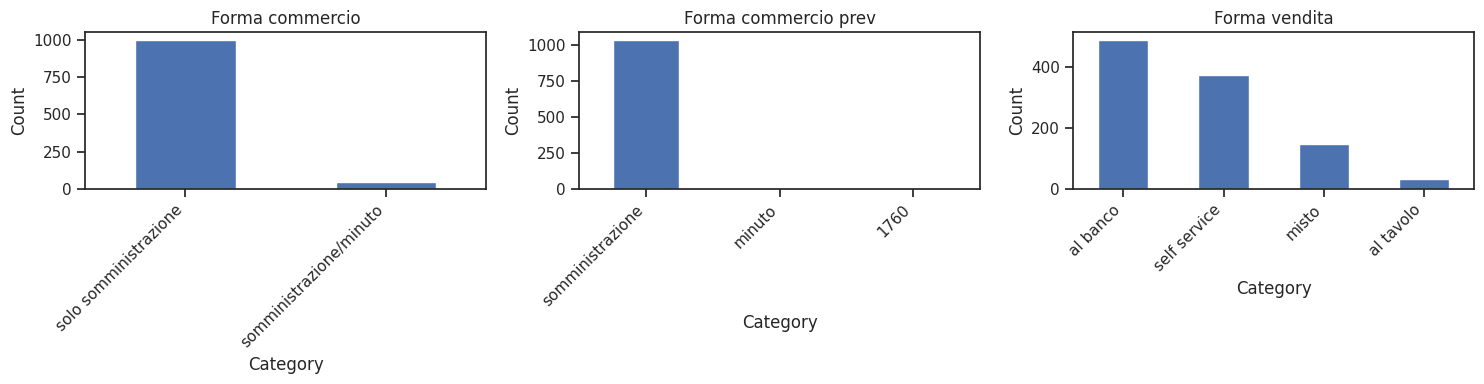

In [ ]:
# -------------------------------------------------------
# Analysis of low-cardinality categorical attributes
# -------------------------------------------------------

import matplotlib.pyplot as plt

# Frequency distributions for selected categorical attributes
freq_forma_commercio      = df["Forma commercio"].value_counts()
freq_forma_commercio_prev = df["Forma commercio prev"].value_counts()
freq_forma_vendita        = df["Forma vendita"].value_counts()

# Tabular output

print("=== Frequency Distribution: Forma commercio ===")
print(freq_forma_commercio.to_string(), "\n")

print("=== Frequency Distribution: Forma commercio prev ===")
print(freq_forma_commercio_prev.to_string(), "\n")

print("=== Frequency Distribution: Forma vendita ===")
print(freq_forma_vendita.to_string(), "\n")

# Graphical output

plt.figure(figsize=(15, 4))

# Plot Forma commercio
plt.subplot(1, 3, 1)
freq_forma_commercio.plot(kind="bar")
plt.title("Forma commercio")
plt.xlabel("Category")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")

# Plot Forma commercio prev
plt.subplot(1, 3, 2)
freq_forma_commercio_prev.plot(kind="bar")
plt.title("Forma commercio prev")
plt.xlabel("Category")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")

# Plot Forma vendita
plt.subplot(1, 3, 3)
freq_forma_vendita.plot(kind="bar")
plt.title("Forma vendita")
plt.xlabel("Category")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

## Assessment of Redundancy and Internal Consistency in the Dataset
This subsection examines the extent of data redundancy within the dataset by identifying and quantifying duplicate tuples. Detecting duplicated rows is a fundamental step in data quality assessment, as redundancy may bias downstream analyses, distort statistical properties, and propagate inconsistencies. We also explore the internal consistency of numerical attributes through correlation analysis, supported by both tabular summaries and visual inspection.

=== Duplicate Tuples Analysis ===

Number of duplicated rows: 22

Duplicated tuples identified:



,Settore storico pe,Insegna,Ubicazione,Tipo via,Via,Civico,Codice via,ZD,Forma commercio,Forma commercio prev,Forma vendita,Superficie somministrazione
51,NaN,NaN,VIA DEI PICCOLOMINI N. 5 stadio meazza san siro; (z.d. 7),VIA,DEI PICCOLOMINI,5,6513.0,7.0,NaN,NaN,NaN,15.0
52,NaN,NaN,VIA DEI PICCOLOMINI N. 5 stadio meazza san siro; (z.d. 7),VIA,DEI PICCOLOMINI,5,6513.0,7.0,NaN,NaN,NaN,15.0
53,NaN,NaN,VIA DEI PICCOLOMINI N. 5 stadio meazza san siro; (z.d. 7),VIA,DEI PICCOLOMINI,5,6513.0,7.0,NaN,NaN,NaN,15.0
54,NaN,NaN,VIA DEI PICCOLOMINI N. 5 stadio meazza san siro; (z.d. 7),VIA,DEI PICCOLOMINI,5,6513.0,7.0,NaN,NaN,NaN,15.0
55,NaN,NaN,VIA DEI PICCOLOMINI N. 5 stadio meazza san siro; (z.d. 7),VIA,DEI PICCOLOMINI,5,6513.0,7.0,NaN,NaN,NaN,15.0
...,...,...,...,...,...,...,...,...,...,...,...,...
989,Genere Merceol.Autorizz.Sanit.,NaN,VIA RIPAMONTI GIUSEPPE N. 129 (z.d. 5),VIA,RIPAMONTI GIUSEPPE,129,4066.0,5.0,NaN,NaN,NaN,NaN
1018,Genere Merceol.Autorizz.Sanit.,NaN,VIA TUCIDIDE N. 56 (z.d. 3),VIA,TUCIDIDE,56,3251.0,3.0,NaN,NaN,NaN,NaN
1042,Genere Merceol.Autorizz.Sanit.,NaN,VLE SABOTINO N. 16 (z.d. 5),VLE,SABOTINO,16,4046.0,5.0,NaN,NaN,NaN,NaN
1303,Mensa,NaN,VIA BROLETTO N. 13 c/o mensa banca s. paolo;via broletto 013; isolato:377; accesso: accesso interno; (z.d. 1),VIA,BROLETTO,13,720.0,1.0,solo somministrazione,somministrazione,self service,76.0


Duplicate tuples (%): 1.06%



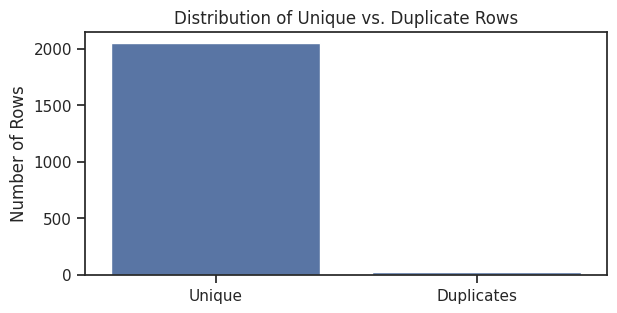


=== Correlation Analysis of Numerical Attributes ===

                             Codice via     ZD     Superficie somministrazione
Codice via                    1.000000   0.477813          -0.019143          
ZD                            0.477813   1.000000           0.031005          
Superficie somministrazione  -0.019143   0.031005           1.000000           



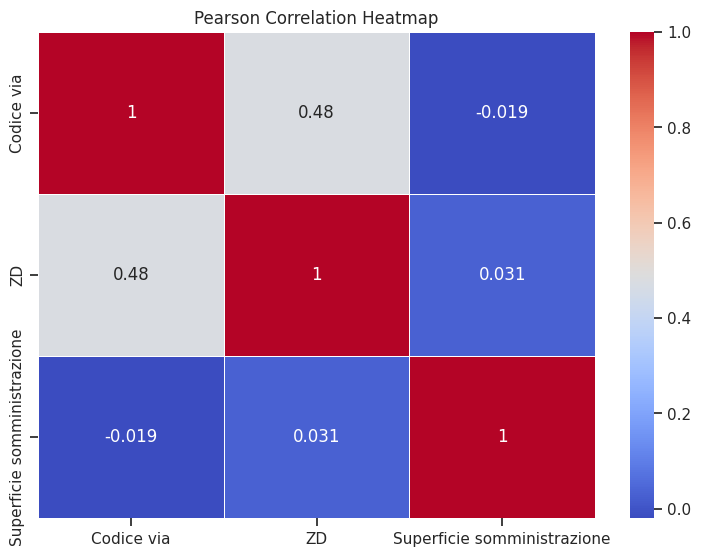

In [ ]:
# ---------------------------------------------------------------
# Assessment of Data Redundancy and Internal Consistency
# ---------------------------------------------------------------

import seaborn as sns
import matplotlib.pyplot as plt

# Duplicate Detection

print("=== Duplicate Tuples Analysis ===\n")

# Number of duplicated rows (entire-row duplicates)
duplicate_count = df.duplicated().sum()
print("Number of duplicated rows:", duplicate_count)

# Mask identifying duplicated rows
duplicate_mask = df.duplicated()

# Display duplicated rows (if any)
if duplicate_count > 0:
    print("\nDuplicated tuples identified:\n")
    display(df[duplicate_mask])
else:
    print("\nNo duplicated tuples were found.\n")

# Percentage of duplicates over the whole dataset
duplicate_percentage = (duplicate_count / float(df.shape[0])) * 100
print("Duplicate tuples (%): {:.2f}%\n".format(duplicate_percentage))


# OPTIONAL: Visualization of Duplicates Distribution
plt.figure(figsize=(6, 3))
sns.barplot(x=["Unique", "Duplicates"], y=[df.shape[0] - duplicate_count, duplicate_count])
plt.title("Distribution of Unique vs. Duplicate Rows")
plt.ylabel("Number of Rows")
plt.show()


# Correlation Analysis
print("\n=== Correlation Analysis of Numerical Attributes ===\n")

# Select numerical columns
num_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
df_numeric = df[num_cols]

# Pearson correlation matrix
corr_matrix = df_numeric.corr(method="pearson")

# Display correlation matrix
print(corr_matrix, "\n")

# Heatmap visualization for easier inspection
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Pearson Correlation Heatmap")
plt.show()

## Assessment of Dataset Completeness and Missing-Value Structure
This subsection evaluates the completeness of the dataset by analyzing the distribution of missing and observed values across attributes. Understanding how NULL values are distributed is essential for identifying structural gaps, potential data-entry issues, and areas that require imputation or cleaning. Both column-level and global completeness indicators are inspected, together with a compact summary visualization.

=== NULL vs. NOT NULL Structure ===

Number of NOT NULL values per column:



,NOT_NULL
Settore storico pe,1877
Insegna,593
Ubicazione,2068
Tipo via,2068
Via,2069
...,...
ZD,2068
Forma commercio,1049
Forma commercio prev,1045
Forma vendita,1040



Total number of NOT NULL values: 19562

Number of NULL values per column:



,NULL
Settore storico pe,193
Insegna,1477
Ubicazione,2
Tipo via,2
Via,1
...,...
ZD,2
Forma commercio,1021
Forma commercio prev,1025
Forma vendita,1030



Total number of NULL values: 5278

=== Completeness Summary Table ===



,NOT_NULL,NULL,Completeness (%)
Settore storico pe,1877,193,90.68
Insegna,593,1477,28.65
Ubicazione,2068,2,99.90
Tipo via,2068,2,99.90
Via,2069,1,99.95
Civico,1916,154,92.56
Codice via,2068,2,99.90
ZD,2068,2,99.90
Forma commercio,1049,1021,50.68
Forma commercio prev,1045,1025,50.48


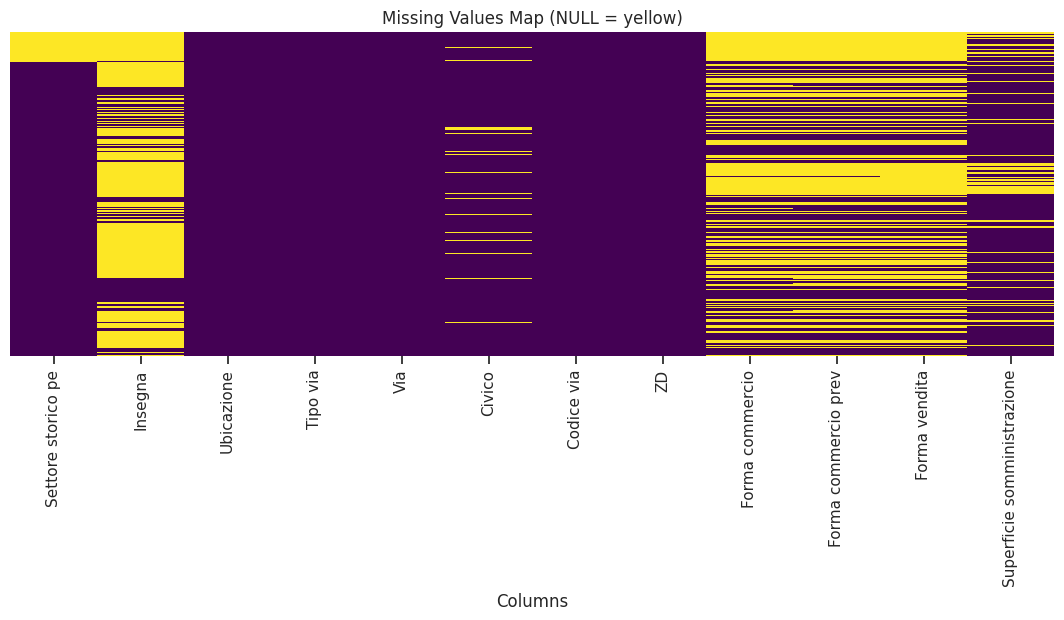


=== Superficie Somministrazione Range ===
Minimum value: 2.0
Maximum value: 4815.0


In [ ]:
# -----------------------------------------------------------
# Completeness Assessment
# -----------------------------------------------------------

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

print("=== NULL vs. NOT NULL Structure ===\n")

# Boolean mask of missingness
null_mask = df.isnull()

# Count of NOT NULL values per column
not_null_per_col = df.count()
print("Number of NOT NULL values per column:\n")
display(not_null_per_col.to_frame("NOT_NULL"))

# Total number of observed (NOT NULL) values
total_not_null = not_null_per_col.sum()
print("\nTotal number of NOT NULL values:", total_not_null)

# Count of NULL values per column
null_per_col = df.isnull().sum()
print("\nNumber of NULL values per column:\n")
display(null_per_col.to_frame("NULL"))

# Total number of missing values
total_null = null_per_col.sum()
print("\nTotal number of NULL values:", total_null)

# -----------------------------------------------------------
# Completeness summary table
# -----------------------------------------------------------

summary_table = pd.DataFrame({
    "NOT_NULL": not_null_per_col,
    "NULL": null_per_col,
    "Completeness (%)": (not_null_per_col / df.shape[0]) * 100
})

print("\n=== Completeness Summary Table ===\n")
display(summary_table.style.background_gradient(cmap="Blues").format({"Completeness (%)": "{:.2f}"}))

# -----------------------------------------------------------
# Visual insight: NULL distribution heatmap
# -----------------------------------------------------------

plt.figure(figsize=(12, 4))
sns.heatmap(null_mask, cbar=False, yticklabels=False, cmap="viridis")
plt.title("Missing Values Map (NULL = yellow)")
plt.xlabel("Columns")
plt.show()

# -----------------------------------------------------------
# Min/Max for the 'Superficie somministrazione' attribute
# -----------------------------------------------------------

print("\n=== Superficie Somministrazione Range ===")
print("Minimum value:", df['Superficie somministrazione'].min())
print("Maximum value:", df['Superficie somministrazione'].max())

## Structural Metadata Extraction and Attribute-Type Characterization
This subsection provides an overview of the dataset’s structural metadata by identifying and classifying its numerical and categorical attributes. Distinguishing attribute types is essential for guiding subsequent data profiling steps, influencing correlation analysis, missing-value treatment, feature engineering, and the selection of appropriate quality metrics.

=== Attribute Type Characterization ===

Numerical attributes:
 ['Codice via', 'ZD', 'Superficie somministrazione'] 

Categorical attributes:
 ['Settore storico pe', 'Insegna', 'Ubicazione', 'Tipo via', 'Via', 'Civico', 'Forma commercio', 'Forma commercio prev', 'Forma vendita'] 

=== Metadata Summary Table ===



,Column Name,Data Type,Role
Settore storico pe,Settore storico pe,object,Categorical
Insegna,Insegna,object,Categorical
Ubicazione,Ubicazione,object,Categorical
Tipo via,Tipo via,object,Categorical
Via,Via,object,Categorical
Civico,Civico,object,Categorical
Codice via,Codice via,float64,Numerical
ZD,ZD,float64,Numerical
Forma commercio,Forma commercio,object,Categorical
Forma commercio prev,Forma commercio prev,object,Categorical


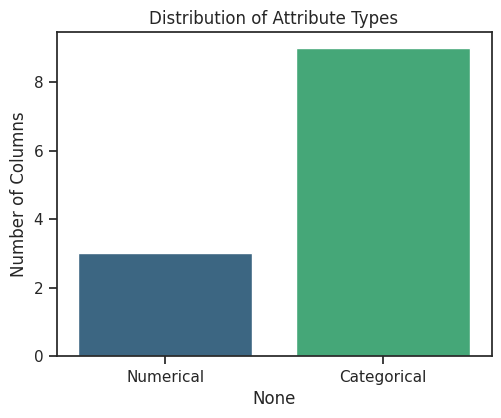

In [ ]:
# -----------------------------------------------------------
# Structural Metadata Extraction
# -----------------------------------------------------------

import seaborn as sns
import matplotlib.pyplot as plt

print("=== Attribute Type Characterization ===\n")

# Identify numerical attributes
numerical_columns = df.select_dtypes(include=[np.number]).columns.tolist()
print("Numerical attributes:\n", numerical_columns, "\n")

# Identify categorical attributes
categorical_columns = df.select_dtypes(include=['object', 'bool']).columns.tolist()
print("Categorical attributes:\n", categorical_columns, "\n")

# -----------------------------------------------------------
# Metadata Summary Table
# -----------------------------------------------------------

metadata_table = (
    pd.DataFrame({
        "Column Name": df.columns,
        "Data Type": df.dtypes.astype(str),
        "Role": ["Numerical" if col in numerical_columns else "Categorical"
                 for col in df.columns]
    })
)

print("=== Metadata Summary Table ===\n")
display(metadata_table.style.background_gradient(cmap="Greens"))

# -----------------------------------------------------------
# Attribute Type Count Plot
# -----------------------------------------------------------

type_counts = pd.Series({
    "Numerical": len(numerical_columns),
    "Categorical": len(categorical_columns)
})

plt.figure(figsize=(5,4))
sns.barplot(x=type_counts.index, y=type_counts.values, palette="viridis")
plt.title("Distribution of Attribute Types")
plt.ylabel("Number of Columns")
plt.show()

## Automated Exploratory Profiling with YData-Profiling

In [ ]:
# -----------------------------------------------------------
# Automated Exploratory Profiling of the Dataset
# -----------------------------------------------------------

'''!pip install ydata-profiling --quiet
from ydata_profiling import ProfileReport

profile = ProfileReport(df, title="Data Profiling Report", explorative=True)
profile'''

'!pip install ydata-profiling --quiet\nfrom ydata_profiling import ProfileReport\n\nprofile = ProfileReport(df, title="Data Profiling Report", explorative=True)\nprofile'

# Data Quality Assessment
A rigorous evaluation of data quality is essential to understand the reliability, usability, and overall fitness of the dataset for analytical or operational purposes. **Data Quality Assessment** focuses on measuring key dimensions such as completeness, consistency, accuracy, and timeliness, providing quantitative evidence of potential issues that may impact downstream processes. By systematically examining these dimensions, it becomes possible to uncover structural anomalies, missing or inconsistent values, duplicated entries, and other defects that might compromise the integrity of the information product. This step establishes a solid foundation for performing targeted cleaning actions and ensuring that subsequent analyses are grounded on trustworthy and well-understood data.

## Data Completeness Overview
Completeness quantifies the extent to which the dataset captures all expected information by measuring the proportion of populated (non-null) cells over the total volume of data. Evaluating this dimension provides an initial indication of missingness patterns and highlights potential gaps that may affect both analytical validity and downstream data quality interventions.

In [ ]:
# -----------------------------------------------------------
# Completeness Evaluation
# -----------------------------------------------------------

# Total number of cells in the dataset
total_cells = df.shape[0] * df.shape[1]

# Total number of observed (NOT NULL) cells
observed_cells = df.count().sum()

# Completeness ratio
completeness_ratio = observed_cells / total_cells

# Formatted percentage for readability
completeness_pct = f"{completeness_ratio * 100:.1f}%"

print("=== Dataset Completeness ===")
print(f"Total cells:             {total_cells:,}")
print(f"Observed (non-null):     {observed_cells:,}")
print(f"Completeness proportion: {completeness_pct}")

=== Dataset Completeness ===
Total cells:             24,840
Observed (non-null):     19,562
Completeness proportion: 78.8%



## Accuracy Evaluation

### Syntactic Accuracy
Syntactic accuracy evaluates whether the values of an attribute comply with a predefined and formally valid domain. It does not rely on ground truth but rather checks if the observed values respect the expected syntactic rules.

**ZD Column — Domain-Based Accuracy**

In [ ]:
# -----------------------------------------------------------
# Syntactic Accuracy: ZD Column
# -----------------------------------------------------------

ZD_domain = list(range(1, 10))
correct_ZD = df["ZD"].isin(ZD_domain).sum()
not_null_ZD = df["ZD"].count()

accuracy_ZD = correct_ZD / not_null_ZD
print(f"Syntactic Accuracy (ZD): {accuracy_ZD * 100:.2f}%")

Syntactic Accuracy (ZD): 100.00%


**Codice Via — Structural Length-Based Accuracy**

In [ ]:
# -----------------------------------------------------------
# Syntactic Accuracy: Codice via Column
# -----------------------------------------------------------

correct_codice_via = df["Codice via"].between(100, 9999).sum()
not_null_codice_via = df["Codice via"].count()

accuracy_codice_via = correct_codice_via / not_null_codice_via
print(f"Syntactic Accuracy (Codice via): {accuracy_codice_via * 100:.2f}%")

Syntactic Accuracy (Codice via): 100.00%


### Semantic Accuracy

Semantic accuracy requires a **ground truth** (a verified source of correct values).
Since no reference dataset is available, semantic accuracy **cannot be evaluated **for the current data.

## TimelinessEvaluation

Timeliness assesses how up-to-date the data are with respect to the phenomena they describe.
Although the dataset refers to the Municipality of Milan (year 2012) and therefore carries historical relevance, the absence of timestamps prevents any computation of timeliness metrics.

## ConsistencyEvaluation

Consistency checks verify whether the values across different columns respect known integrity constraints derived from the schema or semantics of the domain.

In this dataset, we evaluate:


1.   Surface area must be > 0
2.   Street type in “Ubicazione” must match “Tipo via”
3.   Street name in “Ubicazione” must match “Via”
4.   House number in “Ubicazione” must match “Civico”
5.   Zone (ZD) in “Ubicazione” must match “ZD”


### Constructing Consistency Indicators
A binary column is created for each constraint:
*   1 → the row complies with the constraint
*   0 → the row violates the constraint or is NULL



In [ ]:
# -----------------------------------------------------------
# Consistency Checks
# -----------------------------------------------------------

PROPERTIES = [
    "Consistency Superficie somministrazione",
    "Consistency Tipo via",
    "Consistency Via",
    "Consistency Civico",
    "Consistency ZD"
]

NEW_DF = df.copy()

# Surface > 0
NEW_DF[PROPERTIES[0]] = (NEW_DF['Superficie somministrazione'] > 0).astype(int)

# Street type matches
NEW_DF[PROPERTIES[1]] = (NEW_DF["Ubicazione"].str.split().str[0] == NEW_DF["Tipo via"]).astype(int)

# Street name contained in Ubicazione
NEW_DF[PROPERTIES[2]] = NEW_DF.apply(
    lambda row: int(str(row["Via"]) in str(row["Ubicazione"])),
    axis=1
)

# Civico extracted from Ubicazione
NEW_DF[PROPERTIES[3]] = (
    NEW_DF["Ubicazione"]
    .str.extract(r'(?:N\.|n\.|num\.|civ\.)\s*(\d+)', expand=False)
    == NEW_DF["Civico"]
).astype(int)

# ZD extracted from Ubicazione
NEW_DF[PROPERTIES[4]] = (
    NEW_DF["Ubicazione"]
    .str.extract(r'z.d. (\d+)', expand=False)
    .astype(float)
    == NEW_DF["ZD"]
).astype(int)

### Computing Consistency Scores

In [ ]:
# -----------------------------------------------------------
# Consistency Scoring
# -----------------------------------------------------------

print("=== Consistency Evaluation ===\n")

for cons in PROPERTIES:
    column_name = cons.split("Consistency ")[1]
    consistent_cells = (NEW_DF[cons] == 1).sum()
    total_rows = NEW_DF.shape[0]

    consistency_score = (consistent_cells / total_rows) * 100
    print(f"{cons}: {consistency_score:.1f}%")

=== Consistency Evaluation ===

Consistency Superficie somministrazione: 82.2%
Consistency Tipo via: 94.4%
Consistency Via: 92.0%
Consistency Civico: 85.0%
Consistency ZD: 90.9%


##VisualConsistencyOverview
Graphical analysis of consistency indicators provides an immediate understanding of which constraints are mostly respected and where violations are concentrated. Bar charts summarise the overall consistency level per constraint, while a binary heatmap highlights the pattern of consistent/inconsistent rows across the dataset, helping to identify systematic issues or localized problems.

=== Consistency Scores per Constraint (% ) ===



,Consistency (%)
Consistency Tipo via,94.444444
Consistency Via,91.980676
Consistency ZD,90.917874
Consistency Civico,84.975845
Consistency Superficie somministrazione,82.173913


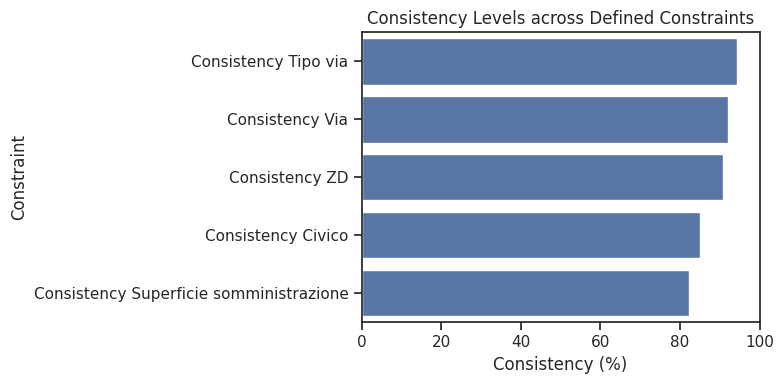

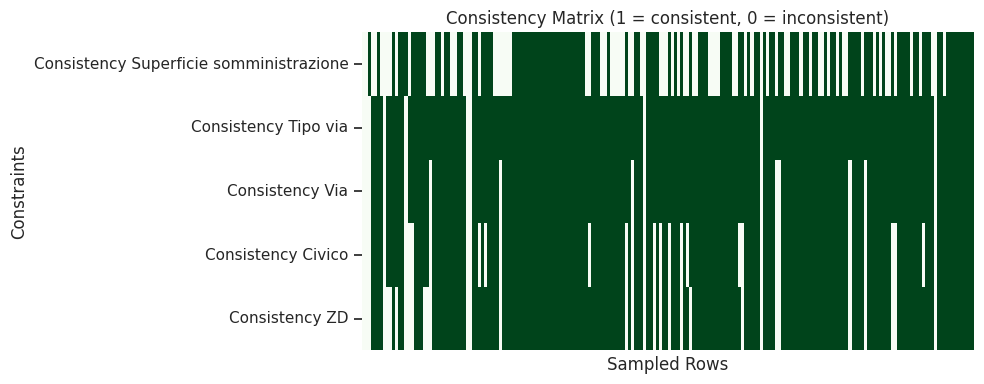

In [ ]:
# -----------------------------------------------------------
# Visual Consistency Overview
# -----------------------------------------------------------

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Compute consistency percentages for each defined constraint
consistency_scores = {}

for cons in PROPERTIES:
    consistent_cells = (NEW_DF[cons] == 1).sum()
    total_rows = NEW_DF.shape[0]
    consistency_scores[cons] = (consistent_cells / total_rows) * 100

consistency_series = pd.Series(consistency_scores).sort_values(ascending=False)

print("=== Consistency Scores per Constraint (% ) ===\n")
display(consistency_series.to_frame("Consistency (%)"))


# Bar plot of consistency scores
plt.figure(figsize=(8, 4))
sns.barplot(
    x=consistency_series.values,
    y=consistency_series.index,
    orient="h",
)
plt.xlabel("Consistency (%)")
plt.ylabel("Constraint")
plt.title("Consistency Levels across Defined Constraints")
plt.xlim(0, 100)
plt.tight_layout()
plt.show()

# -----------------------------------------------------------
# Binary heatmap of consistency indicators (sample of rows)
# -----------------------------------------------------------
# it's used only a sample of the ds and not all one to keep
# the visualisation readable
sample_size = min(200, NEW_DF.shape[0])
consistency_sample = NEW_DF[PROPERTIES].head(sample_size)

plt.figure(figsize=(10, 4))
sns.heatmap(
    consistency_sample.T,
    cmap="Greens",
    cbar=False,
    xticklabels=False
)
plt.title("Consistency Matrix (1 = consistent, 0 = inconsistent)")
plt.ylabel("Constraints")
plt.xlabel("Sampled Rows")
plt.tight_layout()
plt.show()

## Attribute-Level Redundancy and Concentration Metrics

**Uniqueness**, **Distinctness**, and **Constancy** provide complementary views on how informative or redundant each attribute is. Uniqueness measures how many rows can be discriminated by a given column; distinctness normalizes the number of distinct values by the number of observed (non-null) entries; constancy quantifies how strongly a single value dominates the distribution. Together, these metrics support the identification of quasi-identifiers, low-information attributes, and highly skewed features that may affect both analysis and data quality assessment.


=== Uniqueness, Distinctness and Constancy per Attribute ===



,Uniqueness,Distinctness,Constancy
Column,,,
Settore storico pe,0.229,0.253,0.266
Insegna,0.260,0.907,0.027
Ubicazione,0.966,0.967,0.010
Tipo via,0.007,0.007,0.769
Via,0.492,0.493,0.016
Civico,0.082,0.089,0.063
Codice via,0.494,0.494,0.016
ZD,0.004,0.004,0.171
Forma commercio,0.001,0.002,0.954


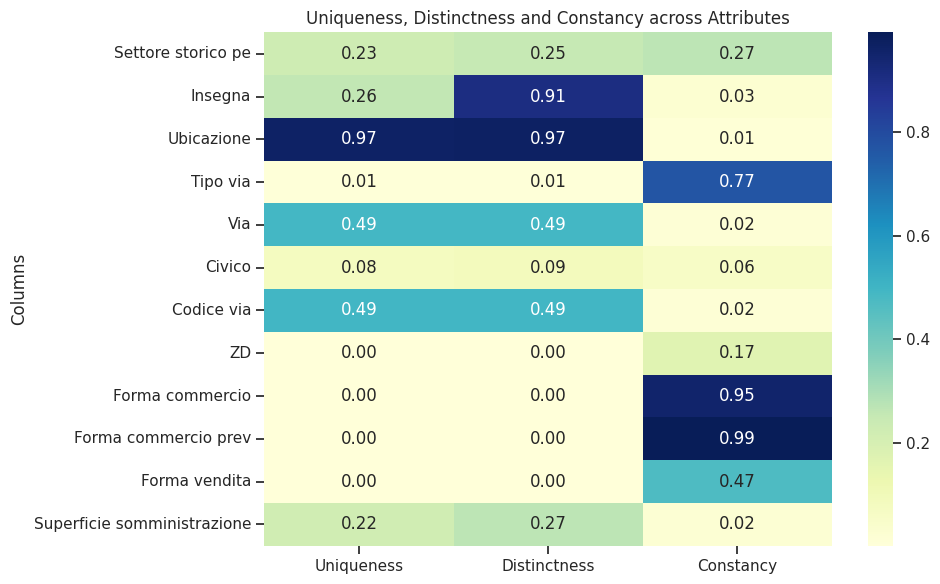

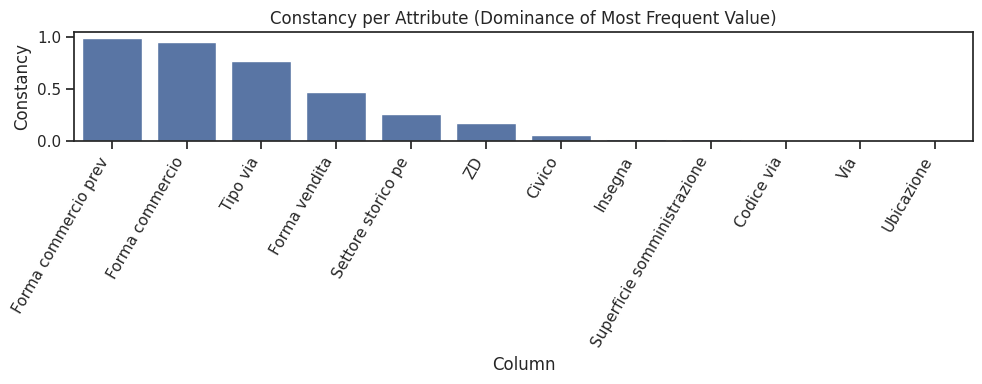

In [ ]:
# -----------------------------------------------------------
# Attribute-Level Uniqueness, Distinctness and Constancy
# -----------------------------------------------------------

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

metrics = []

for col in df.columns:
    # Number of distinct values (excluding NaN)
    num_distinct = df[col].nunique(dropna=True)

    # Number of non-null values
    count_non_null = df[col].count()

    # Total rows in the dataset
    total_rows = df.shape[0]

    # Avoid division by zero for fully null columns
    if count_non_null == 0:
        uniqueness = np.nan
        distinctness = np.nan
        constancy = np.nan
    else:
        # Uniqueness: distinct values / total rows
        uniqueness = num_distinct / float(total_rows)

        # Distinctness: distinct values / non-null values
        distinctness = num_distinct / float(count_non_null)

        # Constancy: max frequency of a single value / non-null values
        max_counts = df[col].value_counts(dropna=True).max() if num_distinct > 0 else 0
        constancy = max_counts / float(count_non_null)

    metrics.append({
        "Column": col,
        "Uniqueness": uniqueness,
        "Distinctness": distinctness,
        "Constancy": constancy
    })

# Build a summary DataFrame
dq_metrics_df = pd.DataFrame(metrics)

print("=== Uniqueness, Distinctness and Constancy per Attribute ===\n")
display(
    dq_metrics_df
    .set_index("Column")
    .style.format("{:.3f}")
    .background_gradient(cmap="Blues")
)

# -----------------------------------------------------------
# Visualisation: Heatmap of DQ Metrics
# -----------------------------------------------------------

plt.figure(figsize=(10, 6))
sns.heatmap(
    dq_metrics_df.set_index("Column"),
    annot=True,
    fmt=".2f",
    cmap="YlGnBu"
)
plt.title("Uniqueness, Distinctness and Constancy across Attributes")
plt.ylabel("Columns")
plt.tight_layout()
plt.show()

# -----------------------------------------------------------
# Optional: Focused view on Constancy (highly dominated columns)
# -----------------------------------------------------------

dq_metrics_df_sorted = dq_metrics_df.sort_values(by="Constancy", ascending=False)

plt.figure(figsize=(10, 4))
sns.barplot(
    data=dq_metrics_df_sorted,
    x="Column",
    y="Constancy"
)
plt.xticks(rotation=60, ha="right")
plt.ylabel("Constancy")
plt.title("Constancy per Attribute (Dominance of Most Frequent Value)")
plt.tight_layout()
plt.show()

# Data Trasformation / Standardization
**Data transformation** aims at reshaping raw or inconsistent values into **Standardized**, coherent representations suitable for downstream analysis and quality assessment. This step is essential when textual attributes contain noise, encoding artefacts, or heterogeneous formats that would otherwise compromise syntactic accuracy, matching procedures, or rule-based validation. By applying controlled normalization rules based on domain knowledge, we ensure that the dataset exhibits structurally consistent forms, enabling more reliable profiling, linkage, and integrity checks.

## EncodingArtefactsCleaning
Textual attributes in the dataset contain several encoding artefacts, mainly represented by the characters '�' and '?', which typically arise from incorrect decoding of accented characters (e.g., UTF-8 read as Latin-1). These artefacts negatively affect both semantic accuracy and downstream text processing (e.g., matching, parsing, regular expressions). The following steps systematically:

(i) detect their presence,

(ii) apply targeted corrections based on domain knowledge,

(iii) verify that the problematic symbols have been removed or reduced to an acceptable level.

### 1. Global detection of encoding artefacts (‘�’)
The goal of this step is to inspect the dataset and quantify the presence of problematic characters such as '�' (Unicode replacement character) and '?' (placeholder for unrecognized bytes). Detecting these artefacts helps assess the extent of encoding corruption and guides the subsequent cleaning steps.

In [ ]:
# -----------------------------------------------------------
# 1. Detection of the '�' replacement character
# -----------------------------------------------------------

# Count total occurrences of '�' across the entire dataset
total_replacement_char = df.apply(
    lambda col: col.astype(str).str.count("�").sum()
).sum()

print(f"Total occurrences of '�' (before cleaning): {total_replacement_char}")

Total occurrences of '�' (before cleaning): 1082


### 2. Targeted correction of ‘�’ occurrences
The '�' symbol indicates bytes that were not correctly decoded. Here we apply targeted corrections based on domain-specific patterns and verified occurrences (e.g., “CAFF�” → “CAFFÈ”). Residual instances within structured textual fields (e.g., addresses) are reinterpreted where appropriate (e.g., as degree symbols °).
This ensures syntactic consistency and restores the intended meaning of the data.

In [ ]:
# -----------------------------------------------------------
# Targeted correction of '�' artefacts
# -----------------------------------------------------------

# Fix specific domain value in "Settore storico pe"
df["Settore storico pe"] = df["Settore storico pe"].str.replace("CAFF�", "CAFFÈ", regex=False)

# Recompute occurrences of '�' after the first fix
total_replacement_char = df.apply(
    lambda col: col.astype(str).str.count("�").sum()
).sum()
print(f"Total occurrences of '�' after fixing 'CAFFÈ': {total_replacement_char}")

# Inspect remaining rows containing '�'
mask_repl = df.apply(lambda col: col.astype(str).str.contains("�")).any(axis=1)
rows_with_repl = df[mask_repl]
print("\nSample rows still containing '�':")
display(rows_with_repl.head())

# Fix remaining known case in 'Ubicazione'
if 557 in df.index:
    df.loc[557, "Ubicazione"] = df.loc[557, "Ubicazione"].replace("universit�", "università")

# Interpret residual '�' in 'Ubicazione' as degree symbol '°'
df["Ubicazione"] = df["Ubicazione"].str.replace("�", "°", regex=False)

# Final check on '�' occurrences
total_replacement_char = df.apply(
    lambda col: col.astype(str).str.count("�").sum()
).sum()
print(f"\nTotal occurrences of '�' after Ubicazione cleaning: {total_replacement_char}")

Total occurrences of '�' after fixing 'CAFFÈ': 14

Sample rows still containing '�':


,Settore storico pe,Insegna,Ubicazione,Tipo via,Via,Civico,Codice via,ZD,Forma commercio,Forma commercio prev,Forma vendita,Superficie somministrazione
22,NaN,NaN,VIA ACHILLE num.000 chiosco n� 1; (),VIA,PARAVIA PIER ALESSANDRO,73,6571.0,7.0,NaN,NaN,NaN,NaN
74,NaN,NaN,VIA DEI PICCOLOMINI num.002/4 int. trotto club house 2� p.; (z.d. 7),VIA,DEI PICCOLOMINI,NaN,6513.0,7.0,NaN,NaN,NaN,NaN
125,NaN,NaN,"VIA OLGETTINA N. 60 fondazione s. raffaele - lotto ""diamante - piani 4�-5�-6� nuovo"" corpo di collegamento""\ncucine di reparto solventi - corpo di collegamento (z.d. 3)",VIA,OLGETTINA,60,2530.0,3.0,NaN,NaN,NaN,NaN
132,NaN,NaN,VIA PALLANZA N. 26 (1� piano) scuola materna (z.d. 2),VIA,PALLANZA,26,1453.0,2.0,NaN,NaN,NaN,NaN
135,NaN,NaN,VIA PATROCLO num.000 chiosco n� 2; (),VIA,CALDESI VINCENZO,6,1458.0,9.0,NaN,NaN,NaN,NaN



Total occurrences of '�' after Ubicazione cleaning: 0


### 3. Detection and correction of '?' artefacts in textual fields
The '?' character appears when accented characters fail to decode. A dictionary of manually validated replacements is applied to restore the correct Italian terms (e.g., “citt?” → “città”). This step enforces semantic accuracy and prevents downstream misclassification in similarity-based or rule-based operations.

In [ ]:
# -----------------------------------------------------------
# Handling '?' artefacts in 'Ubicazione'
# -----------------------------------------------------------

# Identify rows containing '?' in any column
mask_qmark = df.apply(lambda col: col.astype(str).str.contains(r"\?")).any(axis=1)
rows_with_qmark = df[mask_qmark]

print("Rows containing '?' (sample):")
display(rows_with_qmark.head())

# Dictionary-based corrections for common Italian words
qmark_corrections = {
    "universit?": "università",
    "societ?": "società",
    "ges?": "gesù",
    "nestl?": "nestlé",
    "citt?": "città",
    "facolt?": "facoltà",
    "pi?": "più",
    "comunit?": "comunità",
    "giuffr?": "giuffrè"
}

for wrong, correct in qmark_corrections.items():
    df["Ubicazione"] = df["Ubicazione"].str.replace(wrong, correct, regex=False)

# Final count of '?' after corrections
total_qmark = df.apply(
    lambda col: col.astype(str).str.count(r"\?").sum()
).sum()

print(f"\nTotal occurrences of '?' after cleaning: {total_qmark}")

Rows containing '?' (sample):


,Settore storico pe,Insegna,Ubicazione,Tipo via,Via,Civico,Codice via,ZD,Forma commercio,Forma commercio prev,Forma vendita,Superficie somministrazione
340,BAR CAFFÈ,NaN,VIA VERGA ANDREA N. 9 c/o i.s.u. universit? cattolic; (z.d. 7),VIA,VERGA ANDREA,9,6200.0,7.0,NaN,NaN,NaN,NaN
368,BAR CAFFÈ,bar int.univers.bocconi,PZA SRAFFA ANGELO N. 13 c/o scuola universit? bocconi; isolato:102; accesso: accesso interno; (z.d. 5),PZA,SRAFFA ANGELO,13,4042.0,5.0,solo somministrazione,somministrazione,self service,323.0
420,"BAR CAFFÈ;Bar gastronomici e simili;Mensa;Tav.calde,self service,fast f.",isu universita studi mila,VIA SANTA SOFIA N. 9 c/o universit? degli studi di;via santa sofia 009; isolato:272; accesso: accesso interno; (z.d. 1),VIA,SANTA SOFIA,9,408.0,1.0,solo somministrazione,somministrazione,self service,274.0
511,BAR CAFFÈ;Genere Merceol.Autorizz.Sanit.,c/o fac.scienze politiche,VIA CONSERVATORIO N. 7 c/o facolt? scienze politiche; isolato:193; accesso: accesso interno; (z.d. 1),VIA,CONSERVATORIO,7,3031.0,1.0,solo somministrazione,somministrazione,al banco,119.0
571,BAR CAFFÈ;Mensa;Genere Merceol.Autorizz.Sanit.,c/o i.u.lm.,VIA CARLO BO N. 1 c/o universit? iulm;ingresso via 5289 num.003; accesso: accesso interno; (z.d. 6),VIA,CARLO BO,1,5485.0,6.0,solo somministrazione,somministrazione,self service,221.0



Total occurrences of '?' after cleaning: 0


This loop applies a set of domain-driven correction rules to the Ubicazione column. For each erroneous pattern, it counts how many occurrences are present before and after the replacement, allowing us to verify the effectiveness of each transformation and ensure that all artefacts have been properly resolved.

In [ ]:
for wrong, correct in qmark_corrections.items():
    before = df["Ubicazione"].str.contains(wrong, regex=False).sum()
    df["Ubicazione"] = df["Ubicazione"].str.replace(wrong, correct, regex=False)
    after = df["Ubicazione"].str.contains(wrong, regex=False).sum()
    print(f"{wrong} -> {correct}: {before} occurrences fixed, {after} remaining")

universit? -> università: 0 occurrences fixed, 0 remaining
societ? -> società: 0 occurrences fixed, 0 remaining
ges? -> gesù: 0 occurrences fixed, 0 remaining
nestl? -> nestlé: 0 occurrences fixed, 0 remaining
citt? -> città: 0 occurrences fixed, 0 remaining
facolt? -> facoltà: 0 occurrences fixed, 0 remaining
pi? -> più: 0 occurrences fixed, 0 remaining
comunit? -> comunità: 0 occurrences fixed, 0 remaining
giuffr? -> giuffrè: 0 occurrences fixed, 0 remaining


##FeatureEngineeringFromCategoricalText
This subsection focuses on the transformation of the semistructured column Settore storico pe, which contains multiple categories encoded as a list in a single cell. The aim is to convert this textual representation into a structured multi-hot encoding, normalise semantic variants, and consolidate redundant labels to create a coherent set of categorical features suited for analytical processing.

### 1. Tokenization and transaction encoding
The raw sector list is tokenized by splitting on delimiters (;, ,) and cleaning whitespace. Each row becomes a list of atomic sector labels (a “transaction”), which is then transformed into a multi-hot encoded matrix using the TransactionEncoder. This produces a Boolean feature for each distinct sector category.

In [ ]:
# -----------------------------------------------------------
# Tokenization of "Settore storico pe" and transaction encoding
# -----------------------------------------------------------

from mlxtend.preprocessing import TransactionEncoder

# Split the "Settore storico pe" column on ";" or "," and expand into multiple columns
settori_raw = df["Settore storico pe"].str.split(r";|,", expand=True)

# Strip leading/trailing whitespace from all tokens
settori_raw = settori_raw.apply(lambda col: col.str.strip())

display(settori_raw.head())

# Build a list of lists (records) for TransactionEncoder
records = [
    [str(settori_raw.values[i, j]) for j in range(settori_raw.shape[1])]
    for i in range(settori_raw.shape[0])
]

# Initialize and fit the TransactionEncoder
te = TransactionEncoder()
array = te.fit(records).transform(records)

# Build a DataFrame with one binary column per distinct sector string
settori = pd.DataFrame(array, columns=te.columns_)

# Drop 'nan' and 'None' columns if present (artefacts from string conversion)
settori = settori.drop(columns=["nan", "None"], errors="ignore")

print("Initial number of sector features:", settori.shape[1])
display(settori.head())

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Initial number of sector features: 52


,BAR,BAR CAFFÈ,BAR CAFFÈ E SIMILI,Bar gastronomici e simili,Bar pasticc.gelat.crem.creper.,Bigliardino elettrico,Biliardo,Birreria,Bocce,Calcio da tavolo,Carte,Cibi cotti,Cibi cotti preconfezionati,Disco-piano-americ.bar serali,Discoteche,Elettr.Automatici Meccaniche,GIOCHI DI SOCIETA',Gelateria,Genere Merceol.Autorizz.Sanit.,Giochi Legge 388/2000,Gioco video,LETT. GIOCHI LECITI + SOCIETA',Licenza giochi leciti/elettr..,Mensa,Pizzeria,Pizzerie e simili,Prodotti di gastronomia,Ristorante,Sale da ballo,Sale da gioco,Seconda bottiglia,Spaccio bevande analcoliche,Stab.baln. e impianti sportivi,Stabilimenti balneari,Tav.calde,Tavola calda,Tavola fredda,Tennis da tavolo,Trattoria,Wine,birr.,caff.,fast f.,interno bowling,locali notturni,osteria,pub enot.,sale ballo notturni,self serv,self service,the,trattoria
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


  ### 2.  Automatic consolidation of similar sector labels ***(Jaro + Custom Soundex)***
  Textual categories often present orthographic variations, abbreviations, or closely related labels. To reduce redundancy and fragmentation, we apply an automatic consolidation procedure that merges categories with high Jaro–Winkler similarity and matching Soundex codes. The most frequent label is preserved, ensuring robust semantic grouping.
      

In [ ]:
# -----------------------------------------------------------
# Automatic consolidation of similar sector labels
#     using Jaro–Winkler + Custom Soundex
# -----------------------------------------------------------

!pip install textdistance --quiet
from textdistance import jaro_winkler
import re

# Simple Soundex implementation

def soundex_code(s):
    """
    Compute a simple Soundex code for a given string.
    Used to approximate phonetic similarity between labels.
    """
    if not isinstance(s, str):
        s = str(s)
    s = s.upper()
    # Keep only letters
    s = re.sub(r"[^A-Z]", "", s)
    if not s:
        return ""

    # Soundex mapping
    mappings = {
        "BFPV": "1",
        "CGJKQSXZ": "2",
        "DT": "3",
        "L": "4",
        "MN": "5",
        "R": "6"
    }

    def map_char(ch):
        for key, val in mappings.items():
            if ch in key:
                return val
        return "0"

    # First letter
    first_letter = s[0]

    # Encode remaining letters
    encoded_digits = []
    previous_digit = ""

    for ch in s[1:]:
        digit = map_char(ch)
        if digit != "0" and digit != previous_digit:
            encoded_digits.append(digit)
        previous_digit = digit

    # Build code: first letter + three digits (padded with 0)
    code = first_letter + "".join(encoded_digits)
    return (code + "000")[:4]


def sounds_like(a, b):
    """Return True if two strings have the same Soundex code."""
    return soundex_code(a) == soundex_code(b)


# Jaro + Soundex-based consolidation

JARO_THRESHOLD = 0.8

to_remove = []
columns_list = list(settori.columns)

for i in range(len(columns_list)):
    first_sector = columns_list[i]
    if first_sector in to_remove:
        continue

    for j in range(i + 1, len(columns_list)):
        second_sector = columns_list[j]
        if second_sector in to_remove:
            continue

        # Compute Jaro–Winkler similarity between labels
        jaro_distance = jaro_winkler(first_sector, second_sector)

        # Phonetic check to avoid merging semantically different labels
        soundex_check = sounds_like(first_sector, second_sector)

        if jaro_distance > JARO_THRESHOLD and soundex_check:
            first_count = settori[first_sector].sum()
            second_count = settori[second_sector].sum()

            # Preserve the more frequent label
            if first_count < second_count:
                sector_to_preserve = second_sector
                sector_to_remove = first_sector
            else:
                sector_to_preserve = first_sector
                sector_to_remove = second_sector

            print(
                f"Merging '{first_sector}' with '{second_sector}' "
                f"(preserving '{sector_to_preserve}'), Jaro={jaro_distance:.3f}, "
                f"Soundex={soundex_code(first_sector)}"
            )

            settori[sector_to_preserve] = settori[sector_to_preserve] | settori[sector_to_remove]
            to_remove.append(sector_to_remove)

# Drop merged-away columns
settori = settori.drop(columns=to_remove)

print("\nNumber of sector features after automatic consolidation:", settori.shape[1])

Merging 'BAR CAFFÈ' with 'BAR CAFFÈ E SIMILI' (preserving 'BAR CAFFÈ'), Jaro=0.900, Soundex=B621
Merging 'Cibi cotti' with 'Cibi cotti preconfezionati' (preserving 'Cibi cotti preconfezionati'), Jaro=0.877, Soundex=C123
Merging 'Stab.baln. e impianti sportivi' with 'Stabilimenti balneari' (preserving 'Stab.baln. e impianti sportivi'), Jaro=0.844, Soundex=S314
Merging 'Trattoria' with 'trattoria' (preserving 'trattoria'), Jaro=0.884, Soundex=T636
Merging 'self serv' with 'self service' (preserving 'self service'), Jaro=0.950, Soundex=S412

Number of sector features after automatic consolidation: 47


 ### 3. Manual consolidation based on domain knowledge
 Automatic methods cannot fully capture domain-specific equivalences (e.g., historical naming conventions, idiosyncratic abbreviations). This step finalizes the consolidation process by manually merging categories known to represent the same concept. This correction integrates domain expertise into the transformation pipeline, improving both interpretability and consistency.

In [ ]:
# -----------------------------------------------------------
# Manual consolidation of remaining sector labels
# -----------------------------------------------------------

print("\nManual merge of semantically equivalent labels:\n")

to_merge = [
    ["BAR CAFFÈ", "BAR"],
    ["Birreria", "birr."],
    ["Pizzeria", "Pizzerie e simili"],
    ["BAR CAFFÈ", "caff."],
    ["Tavola calda", "Tav.calde"],
    ["Sale da ballo", "sale ballo notturni"],
    ["Discoteche", "Sale da ballo"],
    ["Discoteche", "locali notturni"]
]

for keep_label, remove_label in to_merge:
    if keep_label in settori.columns and remove_label in settori.columns:
        settori[keep_label] = settori[keep_label] | settori[remove_label]
        settori = settori.drop(columns=remove_label)
        print(f"Merging '{keep_label}' with '{remove_label}'")

# Normalize label casing (Title case) for readability
settori.columns = [col[0].upper() + col[1:].lower() for col in settori.columns]

print("\nNumber of sector features after manual consolidation:", settori.shape[1])

# tables with counts per each column
sector_counts = settori.sum().sort_values(ascending=False)
print("\nSector frequency (after consolidation):")
display(sector_counts.to_frame("Count"))


Manual merge of semantically equivalent labels:

Merging 'BAR CAFFÈ' with 'BAR'
Merging 'Birreria' with 'birr.'
Merging 'Pizzeria' with 'Pizzerie e simili'
Merging 'BAR CAFFÈ' with 'caff.'
Merging 'Tavola calda' with 'Tav.calde'
Merging 'Sale da ballo' with 'sale ballo notturni'
Merging 'Discoteche' with 'Sale da ballo'
Merging 'Discoteche' with 'locali notturni'

Number of sector features after manual consolidation: 39

Sector frequency (after consolidation):


,Count
Bar caffè,951
Mensa,645
Genere merceol.autorizz.sanit.,626
Tavola fredda,441
Tavola calda,140
...,...
Bigliardino elettrico,2
Lett. giochi leciti + societa',2
Giochi di societa',1
Tennis da tavolo,1


### 4. Filtering infrequent sectors and integrating features into the main dataset
After consolidation, very rare categories (below 1% prevalence) are removed to improve interpretability, reduce sparsity, and avoid introducing noise. This filtering step also mitigates issues related to the curse of dimensionality by retaining only meaningful, statistically relevant categories.

Now we print, based on the treshold 0.01, what features are going to drop or not

In [ ]:
# ============================================
# PRE-DROP ANALYSIS OF SECTOR COLUMNS
# ============================================

print("\n=== PRE-DROP ANALYSIS OF SECTORS ===\n")

tot = settori.shape[0]
threshold = 0.01  # 1%

summary = []

for col in settori.columns:
    cnt = settori[col].sum()
    perc = cnt / tot
    drop_flag = "YES" if perc < threshold else "NO"
    summary.append([col, cnt, perc * 100, drop_flag])

summary_df = pd.DataFrame(summary, columns=["Sector", "True_Count", "Perc_%", "DROP?"])

summary_df = summary_df.sort_values("Perc_%", ascending=True)

print(summary_df.to_string(index=False))


=== PRE-DROP ANALYSIS OF SECTORS ===

            Sector              True_Count   Perc_%  DROP?
            Giochi di societa'       1      0.048309  YES 
              Tennis da tavolo       1      0.048309  YES 
               Interno bowling       1      0.048309  YES 
Lett. giochi leciti + societa'       2      0.096618  YES 
         Bigliardino elettrico       2      0.096618  YES 
              Calcio da tavolo       3      0.144928  YES 
                 Sale da gioco       3      0.144928  YES 
                     Gelateria       4      0.193237  YES 
             Seconda bottiglia       6      0.289855  YES 
Licenza giochi leciti/elettr..       7      0.338164  YES 
Stab.baln. e impianti sportivi      10      0.483092  YES 
                          Wine      11      0.531401  YES 
                     Pub enot.      11      0.531401  YES 
                           The      11      0.531401  YES 
 Disco-piano-americ.bar serali      12      0.579710  YES 
                 

Dropping column 'Bar pasticc.gelat.crem.creper.': true in 0.63% of rows
Dropping column 'Bigliardino elettrico': true in 0.10% of rows
Dropping column 'Birreria': true in 0.58% of rows
Dropping column 'Calcio da tavolo': true in 0.14% of rows
Dropping column 'Disco-piano-americ.bar serali': true in 0.58% of rows
Dropping column 'Elettr.automatici meccaniche': true in 0.97% of rows
Dropping column 'Giochi di societa'': true in 0.05% of rows
Dropping column 'Gelateria': true in 0.19% of rows
Dropping column 'Gioco video': true in 0.68% of rows
Dropping column 'Lett. giochi leciti + societa'': true in 0.10% of rows
Dropping column 'Licenza giochi leciti/elettr..': true in 0.34% of rows
Dropping column 'Sale da gioco': true in 0.14% of rows
Dropping column 'Seconda bottiglia': true in 0.29% of rows
Dropping column 'Stab.baln. e impianti sportivi': true in 0.48% of rows
Dropping column 'Tennis da tavolo': true in 0.05% of rows
Dropping column 'Wine': true in 0.53% of rows
Dropping column 'I

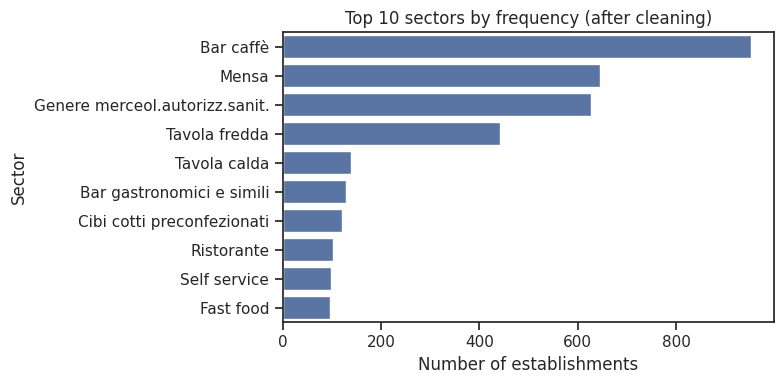


Final sector counts (after filtering and renaming):


,Count
Bar caffè,951
Mensa,645
Genere merceol.autorizz.sanit.,626
Tavola fredda,441
Tavola calda,140
...,...
Giochi legge 388/2000,39
Biliardo,38
Bocce,31
Spaccio bevande analcoliche,24



Updated dataset shape after adding sector features: (2070, 31)


In [ ]:
# -----------------------------------------------------------
# Filtering infrequent sectors and integrating into df
# -----------------------------------------------------------

# Drop sectors with prevalence < 1%
to_remove = []
threshold = 0.01  # 1%

for col in settori.columns:
    prevalence = settori[col].sum() / settori.shape[0]
    if prevalence < threshold:
        print(f"Dropping column '{col}': true in {prevalence * 100:.2f}% of rows")
        to_remove.append(col)

settori = settori.drop(columns=to_remove)

# Manual renaming of some columns for clarity
rename_map = {
    "Self serv": "Self service",
    "Fast f.": "Fast food"
}
settori = settori.rename(columns=rename_map)

# Bar plot of most frequent sectors
top_n = 10
top_sectors = settori.sum().sort_values(ascending=False).head(top_n)

plt.figure(figsize=(8, 4))
sns.barplot(x=top_sectors.values, y=top_sectors.index)
plt.title(f"Top {top_n} sectors by frequency (after cleaning)")
plt.xlabel("Number of establishments")
plt.ylabel("Sector")
plt.tight_layout()
plt.show()

print("\nFinal sector counts (after filtering and renaming):")
display(settori.sum().sort_values(ascending=False).to_frame("Count"))

# Add these columns to the main DataFrame
for col in settori.columns:
    df[col] = settori[col]

# Drop original "Settore storico pe" column
df = df.drop(columns=["Settore storico pe"])

print("\nUpdated dataset shape after adding sector features:", df.shape)

## ExtractTipoViaValues
The Ubicazione column encodes multiple spatial attributes (street type, street name, street number, and district code) within a single textual field. This subsection extracts and standardizes these components into dedicated columns (Tipo via, Via, Civico, ZD) to recover a normalized geometric representation.
The transformation combines manual correction of rare anomalous records with regex-based parsing applied at scale, ensuring alignment between textual location descriptors and structured attributes.

###1. Identification of Null Spatial Attributes
We begin by detecting records where spatial attributes (Tipo via, Via, Civico, ZD) are missing. These cases often arise from irregular formatting or duplicated entries. Identifying them is essential before performing extraction and reconstruction.

In [ ]:
# -----------------------------------------------------------
# Identification of records with missing spatial attributes
# -----------------------------------------------------------

# Records with missing "Tipo via"
mask_tipo_via_null = df["Tipo via"].isnull()
print("Rows with NULL 'Tipo via':")
display(df[mask_tipo_via_null])

# Records with missing "Via"
mask_via_null = df["Via"].isnull()
print("Rows with NULL 'Via':")
display(df[mask_via_null])

# Records with missing "Civico"
mask_civico_null = df["Civico"].isnull()
print("Rows with NULL 'Civico':")
display(df[mask_civico_null])

# Records with missing "ZD"
mask_zd_null = df["ZD"].isnull()
print("Rows with NULL 'ZD':")
display(df[mask_zd_null])

Rows with NULL 'Tipo via':


,Insegna,Ubicazione,Tipo via,Via,Civico,Codice via,ZD,Forma commercio,Forma commercio prev,Forma vendita,Superficie somministrazione,Bar caffè,Bar gastronomici e simili,Biliardo,Bocce,Carte,Cibi cotti preconfezionati,Discoteche,Genere merceol.autorizz.sanit.,Giochi legge 388/2000,Mensa,Pizzeria,Prodotti di gastronomia,Ristorante,Spaccio bevande analcoliche,Tavola calda,Tavola fredda,Fast food,Osteria,Self service,Trattoria
34,NaN,VIA CAVEZZALI FRANCESCO civ. 9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
35,VIA,CAVEZZALI FRANCESCO,NaN,2335,2,NaN,NaN,NaN,1760,NaN,NaN,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


Rows with NULL 'Via':


,Insegna,Ubicazione,Tipo via,Via,Civico,Codice via,ZD,Forma commercio,Forma commercio prev,Forma vendita,Superficie somministrazione,Bar caffè,Bar gastronomici e simili,Biliardo,Bocce,Carte,Cibi cotti preconfezionati,Discoteche,Genere merceol.autorizz.sanit.,Giochi legge 388/2000,Mensa,Pizzeria,Prodotti di gastronomia,Ristorante,Spaccio bevande analcoliche,Tavola calda,Tavola fredda,Fast food,Osteria,Self service,Trattoria
34,NaN,VIA CAVEZZALI FRANCESCO civ. 9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


Rows with NULL 'Civico':


,Insegna,Ubicazione,Tipo via,Via,Civico,Codice via,ZD,Forma commercio,Forma commercio prev,Forma vendita,Superficie somministrazione,Bar caffè,Bar gastronomici e simili,Biliardo,Bocce,Carte,Cibi cotti preconfezionati,Discoteche,Genere merceol.autorizz.sanit.,Giochi legge 388/2000,Mensa,Pizzeria,Prodotti di gastronomia,Ristorante,Spaccio bevande analcoliche,Tavola calda,Tavola fredda,Fast food,Osteria,Self service,Trattoria
15,NaN,PZA CASTELLO num.000 pl cannone-castello sforzesco; (),PZA,CASTELLO,NaN,704.0,1.0,NaN,NaN,NaN,NaN,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
16,NaN,PZA DUCA D'AOSTA interno stazione centrale,PZA,DUCA D'AOSTA,NaN,1200.0,2.0,NaN,NaN,NaN,131.0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
34,NaN,VIA CAVEZZALI FRANCESCO civ. 9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
38,NaN,VIA CILEA FRANCESCO num.061 polisportiva san leonardo; (z.d. 8),VIA,CILEA FRANCESCO,NaN,7526.0,8.0,NaN,NaN,NaN,NaN,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
74,NaN,VIA DEI PICCOLOMINI num.002/4 int. trotto club house 2° p.; (z.d. 7),VIA,DEI PICCOLOMINI,NaN,6513.0,7.0,NaN,NaN,NaN,NaN,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2018,bar caffe,CSO DI PORTA TICINESE num.095 interno museo diocesiano; accesso: accesso interno; (z.d. 1),CSO,DI PORTA TICINESE,NaN,541.0,1.0,solo somministrazione,somministrazione,al banco,41.0,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False
2020,pasticceria bindi,PLE CADORNA LUIGI num.000 (int. stazione ferrovie nord); accesso: accesso interno; (z.d. 1),PLE,CADORNA LUIGI,NaN,601.0,1.0,solo somministrazione,somministrazione,misto,38.0,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False
2050,NaN,VIA FATTORI GIOVANNI num.000 (int. staz. ffss mi-certosa); accesso: area ap.rec.; (z.d. 8),VIA,FATTORI GIOVANNI,NaN,7452.0,8.0,somministrazione/minuto,somministrazione,al banco,79.0,True,False,False,False,False,False,False,True,False,False,False,True,False,False,False,True,False,False,False,False
2057,casa cura la madonnina,VIA QUADRONNO num.029/31 c/o casa di cura la madonnina; isolato:205; accesso: accesso interno; (z.d. 1),VIA,QUADRONNO,NaN,4021.0,1.0,solo somministrazione,somministrazione,self service,135.0,True,False,False,False,False,False,False,False,False,True,False,False,True,False,False,True,False,True,False,True


Rows with NULL 'ZD':


,Insegna,Ubicazione,Tipo via,Via,Civico,Codice via,ZD,Forma commercio,Forma commercio prev,Forma vendita,Superficie somministrazione,Bar caffè,Bar gastronomici e simili,Biliardo,Bocce,Carte,Cibi cotti preconfezionati,Discoteche,Genere merceol.autorizz.sanit.,Giochi legge 388/2000,Mensa,Pizzeria,Prodotti di gastronomia,Ristorante,Spaccio bevande analcoliche,Tavola calda,Tavola fredda,Fast food,Osteria,Self service,Trattoria
34,NaN,VIA CAVEZZALI FRANCESCO civ. 9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
35,VIA,CAVEZZALI FRANCESCO,NaN,2335,2,NaN,NaN,NaN,1760,NaN,NaN,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


###2. Manual Reconstruction of Outlier Records

Very rare anomalies (here: only two rows) require manual reconstruction.
In these cases, information is fully available but misallocated across attributes: the solution consists in extracting the missing values from neighbouring records and the Ubicazione string, ensuring full recovery and eliminating unintended duplicates.

In [ ]:
# -----------------------------------------------------------
# Manual reconstruction of anomalous pair of rows
# -----------------------------------------------------------

null_tipo_idx = df.index[df["Tipo via"].isnull()].tolist()

# We know from inspection that there are exactly 2 anomalous rows
if len(null_tipo_idx) == 2:
    idx_main, idx_aux = null_tipo_idx[0], null_tipo_idx[1]

    # Split 'Ubicazione' of the main row to extract the civic
    tokens = str(df.loc[idx_main, "Ubicazione"]).split()
    civic = tokens[4] if len(tokens) > 4 else None

    # Reconstruct attributes using information in the auxiliary row
    df.loc[idx_main, "Tipo via"] = df.loc[idx_aux, "Insegna"]
    df.loc[idx_main, "Via"] = df.loc[idx_aux, "Ubicazione"]
    df.loc[idx_main, "Civico"] = civic
    df.loc[idx_main, "Codice via"] = df.loc[idx_aux, "Via"]
    df.loc[idx_main, "ZD"] = int(df.loc[idx_aux, "Civico"])
    df.loc[idx_main, "Superficie somministrazione"] = pd.to_numeric(
        df.loc[idx_aux, "Forma commercio prev"], errors="coerce"
    )

    # Drop the auxiliary row, now fully consumed
    df = df.drop(index=idx_aux)

print("Rows with NULL 'Tipo via' after manual reconstruction:")
display(df[df["Tipo via"].isnull()])

Rows with NULL 'Tipo via' after manual reconstruction:


,Insegna,Ubicazione,Tipo via,Via,Civico,Codice via,ZD,Forma commercio,Forma commercio prev,Forma vendita,Superficie somministrazione,Bar caffè,Bar gastronomici e simili,Biliardo,Bocce,Carte,Cibi cotti preconfezionati,Discoteche,Genere merceol.autorizz.sanit.,Giochi legge 388/2000,Mensa,Pizzeria,Prodotti di gastronomia,Ristorante,Spaccio bevande analcoliche,Tavola calda,Tavola fredda,Fast food,Osteria,Self service,Trattoria


###3. Extraction of “Civico” Using ***Regex Patterns***

To fill missing Civico values, we extract street numbers from Ubicazione using a robust regex pattern.
The expression captures common Italian prefixes (civico, civ., num., n.) and retrieves the numerical component.
The extracted values are then reintegrated into the structured attribute.

In [ ]:
# -----------------------------------------------------------
# Extract missing 'Civico' values from 'Ubicazione'
# -----------------------------------------------------------

# Identify rows with missing 'Civico'
mask_civico_null = df["Civico"].isnull()
rows_with_missing_civico = df.index[mask_civico_null]

print("Rows with NULL 'Civico' before regex extraction:")
display(df.loc[rows_with_missing_civico, ["Ubicazione", "Civico"]])

# Extract 'Civico' using regex (supports: civico / civ. / num. / n.)
civico_extracted = df.loc[rows_with_missing_civico, "Ubicazione"].str.extract(
    r'(?:civico|civ\.|num\.|n\.)\s*(\d+)',
    expand=False
)

# Assign extracted values back to the original column
df.loc[rows_with_missing_civico, "Civico"] = civico_extracted

# Display remaining NULL 'Civico' values, if any
print("Rows with NULL 'Civico' after regex extraction:")
display(df[df["Civico"].isnull()][["Ubicazione", "Civico"]])

# Completeness metric for Civico
civico_completeness = df["Civico"].notnull().mean() * 100
print(f"'Civico' completeness after extraction: {civico_completeness:.2f}%")

Rows with NULL 'Civico' before regex extraction:


,Ubicazione,Civico
15,PZA CASTELLO num.000 pl cannone-castello sforzesco; (),NaN
16,PZA DUCA D'AOSTA interno stazione centrale,NaN
38,VIA CILEA FRANCESCO num.061 polisportiva san leonardo; (z.d. 8),NaN
74,VIA DEI PICCOLOMINI num.002/4 int. trotto club house 2° p.; (z.d. 7),NaN
86,VIA GAGGIA PIETRO civico 4 interno asilo nido l'oasi delle coccole,NaN
...,...,...
2018,CSO DI PORTA TICINESE num.095 interno museo diocesiano; accesso: accesso interno; (z.d. 1),NaN
2020,PLE CADORNA LUIGI num.000 (int. stazione ferrovie nord); accesso: accesso interno; (z.d. 1),NaN
2050,VIA FATTORI GIOVANNI num.000 (int. staz. ffss mi-certosa); accesso: area ap.rec.; (z.d. 8),NaN
2057,VIA QUADRONNO num.029/31 c/o casa di cura la madonnina; isolato:205; accesso: accesso interno; (z.d. 1),NaN


Rows with NULL 'Civico' after regex extraction:


,Ubicazione,Civico
16,PZA DUCA D'AOSTA interno stazione centrale,NaN
174,VLE DUILIO s.n.c. - mensa presso astaldi spa,NaN
453,codvia 9401 ff central; (z.d. 2),NaN
454,codvia 9401 ff central; (z.d. 2),NaN
487,codvia 9401 ff central; (z.d. 2),NaN
619,PZA DUCA D'AOSTA interno stazione centrale;,NaN
736,codvia 9107 mm1 loreto; accesso: accesso interno; (z.d. 2),NaN
836,codvia 9123 mm1 gambar; (z.d. 7),NaN


'Civico' completeness after extraction: 99.61%


###4. Extraction and Validation of “ZD”

The ZD (Zona Decentramento) field is validated and reconstructed where missing.
As Ubicazione often contains explicit references to the zone, regex-based extraction provides a consistent method to restore missing values or confirm existing ones.

In [ ]:
# -----------------------------------------------------------
# Inspection of remaining rows with NULL 'ZD'
# -----------------------------------------------------------

mask_zd_null = df["ZD"].isnull()
rows_zd_null = df[mask_zd_null]

print("Rows with NULL 'ZD' (to be inspected or handled separately):")
display(rows_zd_null)

Rows with NULL 'ZD' (to be inspected or handled separately):


,Insegna,Ubicazione,Tipo via,Via,Civico,Codice via,ZD,Forma commercio,Forma commercio prev,Forma vendita,Superficie somministrazione,Bar caffè,Bar gastronomici e simili,Biliardo,Bocce,Carte,Cibi cotti preconfezionati,Discoteche,Genere merceol.autorizz.sanit.,Giochi legge 388/2000,Mensa,Pizzeria,Prodotti di gastronomia,Ristorante,Spaccio bevande analcoliche,Tavola calda,Tavola fredda,Fast food,Osteria,Self service,Trattoria


**Extraction and Validation of “ZD”**

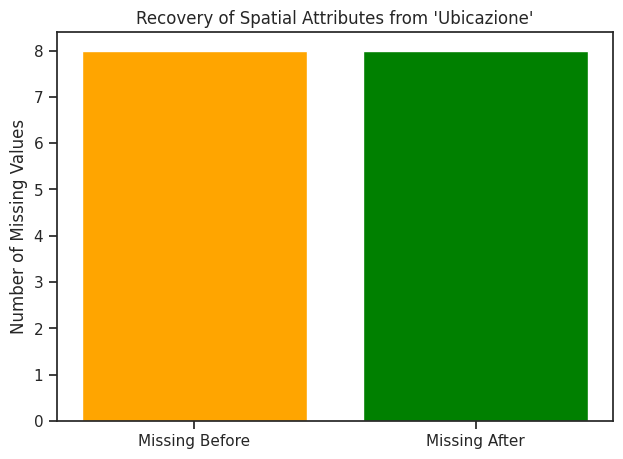

In [ ]:
import matplotlib.pyplot as plt

before = df["Civico"].isnull().sum() + df["Tipo via"].isnull().sum() + df["ZD"].isnull().sum()
after = df["Civico"].isnull().sum() + df["Tipo via"].isnull().sum() + df["ZD"].isnull().sum()

plt.bar(["Missing Before", "Missing After"], [before, after], color=["orange", "green"])
plt.title("Recovery of Spatial Attributes from 'Ubicazione'")
plt.ylabel("Number of Missing Values")
plt.show()

In [ ]:
df


,Insegna,Ubicazione,Tipo via,Via,Civico,Codice via,ZD,Forma commercio,Forma commercio prev,Forma vendita,Superficie somministrazione,Bar caffè,Bar gastronomici e simili,Biliardo,Bocce,Carte,Cibi cotti preconfezionati,Discoteche,Genere merceol.autorizz.sanit.,Giochi legge 388/2000,Mensa,Pizzeria,Prodotti di gastronomia,Ristorante,Spaccio bevande analcoliche,Tavola calda,Tavola fredda,Fast food,Osteria,Self service,Trattoria
0,NaN,NaN,PZA,OSPEDALE MAGGIORE,3,1523.0,9.0,NaN,NaN,NaN,NaN,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,NaN,NaN,VLE,ALEMAGNA EMILIO,6,7106.0,1.0,NaN,NaN,NaN,NaN,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,NaN,codvia 9305 mm3 maciac; (z.d. 9),VIA,SERIO,15,4130.0,5.0,NaN,NaN,NaN,110.0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,NaN,CSO BUENOS AIRES N. 36 (z.d. 3),CSO,BUENOS AIRES,36,2129.0,3.0,NaN,NaN,NaN,NaN,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,NaN,CSO MATTEOTTI GIACOMO N. 7 (z.d. 1),CSO,MATTEOTTI GIACOMO,7,218.0,1.0,NaN,NaN,NaN,NaN,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2065,NaN,VIA LATTANZIO num.075/1 ; isolato:101; (z.d. 4),VIA,CORELLI ARCANGELO,61,3243.0,3.0,NaN,NaN,NaN,394.0,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True
2066,NaN,VIA VERITA' DON GIOVANNI N. 25 ; isolato:015; accesso: accesso interno; (z.d. 9),VIA,VERITA' DON GIOVANNI,25,1469.0,9.0,solo somministrazione,somministrazione,misto,170.0,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True
2067,NaN,VIA DELLE FORZE ARMATE N. 34 ; isolato:197; accesso: accesso esterno; (z.d. 7),VIA,DELLE FORZE ARMATE,34,6643.0,7.0,solo somministrazione,somministrazione,al banco,54.0,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2068,NaN,VIA GALLARATE N. 40 (z.d. 8),VIA,GALLARATE,40,7420.0,8.0,NaN,NaN,NaN,57.0,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [ ]:
rows_to_print = [15, 16, 38, 97, 100]
display(df.loc[rows_to_print])

,Insegna,Ubicazione,Tipo via,Via,Civico,Codice via,ZD,Forma commercio,Forma commercio prev,Forma vendita,Superficie somministrazione,Bar caffè,Bar gastronomici e simili,Biliardo,Bocce,Carte,Cibi cotti preconfezionati,Discoteche,Genere merceol.autorizz.sanit.,Giochi legge 388/2000,Mensa,Pizzeria,Prodotti di gastronomia,Ristorante,Spaccio bevande analcoliche,Tavola calda,Tavola fredda,Fast food,Osteria,Self service,Trattoria
15,NaN,PZA CASTELLO num.000 pl cannone-castello sforzesco; (),PZA,CASTELLO,000,704.0,1.0,NaN,NaN,NaN,NaN,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
16,NaN,PZA DUCA D'AOSTA interno stazione centrale,PZA,DUCA D'AOSTA,NaN,1200.0,2.0,NaN,NaN,NaN,131.0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
38,NaN,VIA CILEA FRANCESCO num.061 polisportiva san leonardo; (z.d. 8),VIA,CILEA FRANCESCO,061,7526.0,8.0,NaN,NaN,NaN,NaN,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
97,NaN,VIA GRAZIANO IMPERATORE num.000 ; (),VIA,GRAZIANO IMPERATORE,000,1524.0,9.0,NaN,NaN,NaN,NaN,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
100,NaN,VIA LAGO DI NEMI num.031 c.tro sport. franco bettinelli; (),VIA,LAGO DI NEMI,031,5351.0,6.0,NaN,NaN,NaN,40.0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


## ValidateUbicazioneConsistency

This subsection evaluates and enforces structural consistency between the structured spatial attributes (Tipo via, Via, Civico, ZD) and the corresponding unstructured textual representation stored in the Ubicazione field.
The cleaning strategy is hybrid:
* rule–based consistency checks
* semantic interpretation of location strings
* targeted removal of corrupted entries
* controlled normalization of categorical types

This methodology aligns with modern data quality frameworks (ISO/IEC 25012, DAMA DMBOK2) under Consistency, Accuracy, and Structural Integrity dimensions.




###1. Detecting Inconsistencies in “Tipo via”


We verify that the first token of Ubicazione matches the value in Tipo via.
If the two differ, the record violates a structural dependency (TipoVia → UbicazionePrefix).
Before dropping inconsistent rows, we filter out a specific pattern (“codvia…”) that corresponds to special station-like codes.

In [ ]:
# -----------------------------------------------------------
# Consistency check: Tipo via vs Ubicazione prefix
# -----------------------------------------------------------

split_tokens = df["Ubicazione"].str.split(" ")
ubic_tipo_via = split_tokens.str[0]

mask_inconsistent_tipo = (
    (df["Tipo via"] != ubic_tipo_via) &
    (ubic_tipo_via.notnull())
)

print("Rows with inconsistent 'Tipo via':")
display(df[mask_inconsistent_tipo])

Rows with inconsistent 'Tipo via':


,Insegna,Ubicazione,Tipo via,Via,Civico,Codice via,ZD,Forma commercio,Forma commercio prev,Forma vendita,Superficie somministrazione,Bar caffè,Bar gastronomici e simili,Biliardo,Bocce,Carte,Cibi cotti preconfezionati,Discoteche,Genere merceol.autorizz.sanit.,Giochi legge 388/2000,Mensa,Pizzeria,Prodotti di gastronomia,Ristorante,Spaccio bevande analcoliche,Tavola calda,Tavola fredda,Fast food,Osteria,Self service,Trattoria
2,NaN,codvia 9305 mm3 maciac; (z.d. 9),VIA,SERIO,15,4130.0,5.0,NaN,NaN,NaN,110.0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
7,NaN,--mahler--,VLE,LIGURIA,21,5264.0,6.0,NaN,NaN,NaN,NaN,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
14,NaN,PZA CAIAZZO interno metropolitana mm2,VIA,PISANELLO,1,6600.0,7.0,NaN,NaN,NaN,86.0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
92,NaN,VIA GIOIA MELCHIORRE num.000 ; (z.d. 9),CSO,MAGENTA,71,604.0,1.0,NaN,NaN,NaN,NaN,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
130,NaN,VIA PADOVA num.013/a interno discoteca mybaki; (),FOR,BUONAPARTE,76,711.0,1.0,NaN,NaN,NaN,NaN,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2029,NaN,codvia 9105 mm1 rovere; isolato:995; accesso: accesso interno; (z.d. 2),PZA,VENTICINQUE APRILE,2,1064.0,1.0,solo somministrazione,somministrazione,al banco,52.0,True,True,False,False,False,True,False,True,False,False,False,False,False,False,False,True,False,False,False,False
2031,NaN,codvia 9209 mm2 centra; isolato:997; accesso: area ap.rec.; (z.d. 2),VLE,BERENGARIO,3,6364.0,8.0,solo somministrazione,somministrazione,al banco,91.0,True,True,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False
2034,bar bianco(int.parco semp,codvia 7099 interno parco sempione; accesso: area ap.rec.; (z.d. 1),VIA,CURTATONE,12,4034.0,1.0,solo somministrazione,somministrazione,misto,56.0,True,True,False,False,False,True,False,True,False,False,False,False,True,False,True,True,True,False,True,False
2053,bar caffe,codvia 9132 mm1 molino; isolato:993; accesso: accesso interno; (z.d. 8),CSO,ITALIA,23,526.0,1.0,solo somministrazione,somministrazione,al banco,88.0,True,False,False,False,False,False,False,True,True,False,False,True,False,False,False,True,False,False,False,False


###2. Handling “codvia” Corrupted Location Strings
Some entries begin with “codvia…”, representing non-decipherable codes (metro nodes or transport markers).
Since they cannot be interpreted nor validated, the safest approach is to invalidate only the textual Ubicazione field, preserving all structured fields (Tipo via, Via, Civico, ZD).

In [ ]:
# -----------------------------------------------------------
# Remove corrupted 'Ubicazione' entries starting with 'codvia'
# -----------------------------------------------------------

mask_codvia = df["Ubicazione"].fillna("").str.startswith("codvia")
print(f"Setting Ubicazione = NaN for {mask_codvia.sum()} corrupted rows")

df.loc[mask_codvia, "Ubicazione"] = np.nan

Setting Ubicazione = NaN for 77 corrupted rows


###3. Dropping Remaining Tipo via Inconsistencies

After removing corrupted codvia entries, we recompute inconsistencies.
At this stage, inconsistencies indicate ambiguous or conflicting information, so rows are dropped — consistent with a strict integrity enforcement policy.

In [ ]:
# -----------------------------------------------------------
# Drop rows still inconsistent after removing codvia cases
# -----------------------------------------------------------

split_tokens = df["Ubicazione"].str.split(" ")
ubic_tipo_via = split_tokens.str[0]

mask_remaining = (
    (df["Tipo via"] != ubic_tipo_via) &
    ubic_tipo_via.notnull()
)

print(f"Dropping {mask_remaining.sum()} inconsistent rows")
df = df[~mask_remaining]

Dropping 34 inconsistent rows


###4. Verifying “Via” Consistency


We ensure that the value in Via is present within Ubicazione.
If not, Ubicazione and Via contradict one another: such rows cannot be repaired reliably and are removed.

In [ ]:
# -----------------------------------------------------------
# Consistency check: Via must be contained in Ubicazione
# -----------------------------------------------------------

mask_inconsistent_via = df.apply(
    lambda row: (
        pd.notnull(row["Ubicazione"]) and
        row["Via"] not in row["Ubicazione"]
    ),
    axis=1
)

print(f"Dropping {mask_inconsistent_via.sum()} rows violating Via consistency")
df = df[~mask_inconsistent_via]

Dropping 51 rows violating Via consistency


###5. Validating “Civico” Against Ubicazione


We extract the civic number from Ubicazione (if present) and compare it with the existing Civico.
Only one row shows a mismatch: it is removed to preserve consistency.




In [ ]:
# -----------------------------------------------------------
# Consistency check: Civico extracted vs Civico column
# -----------------------------------------------------------

mask_has_civico = df["Ubicazione"].str.contains(
    r"(?:N\.|n\.|num\.|civ\.)\s*(\d+)",
    case=False,
    na=False
)

tmp = df[mask_has_civico].copy()
tmp["Civico extracted"] = df["Ubicazione"].str.extract(
    r"(?:N\.|n\.|num\.|civ\.)\s*(\d+)"
)

unconsistent = tmp[tmp["Civico"] != tmp["Civico extracted"]]

print("Rows with inconsistent civic numbers:")
display(unconsistent)

df = df.drop(index=unconsistent.index)

Rows with inconsistent civic numbers:


,Insegna,Ubicazione,Tipo via,Via,Civico,Codice via,ZD,Forma commercio,Forma commercio prev,Forma vendita,Superficie somministrazione,Bar caffè,Bar gastronomici e simili,Biliardo,Bocce,Carte,Cibi cotti preconfezionati,Discoteche,Genere merceol.autorizz.sanit.,Giochi legge 388/2000,Mensa,Pizzeria,Prodotti di gastronomia,Ristorante,Spaccio bevande analcoliche,Tavola calda,Tavola fredda,Fast food,Osteria,Self service,Trattoria,Civico extracted
40,NaN,VIA CORELLI ARCANGELO N. 36/7 (z.d. 3),VIA,CORELLI ARCANGELO,36/7,3243.0,3.0,NaN,NaN,NaN,494.0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,36
106,NaN,VIA LONGARONE N. 18/4 (z.d. 8),VIA,LONGARONE,41017,7520.0,8.0,NaN,NaN,NaN,NaN,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,18
123,NaN,VIA MURATORI LODOVICO N. 46/6 (z.d. 4),VIA,MURATORI LODOVICO,46/6,4076.0,4.0,NaN,NaN,NaN,13.0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,46
312,NaN,VIA QUINTOSOLE N. 42/23 interno impianto sportivo; (z.d. 5),VIA,QUINTOSOLE,42/23,4357.0,5.0,NaN,NaN,NaN,96.0,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,42


6. Standardization of Spatial Attribute Types


We normalize street type abbreviations, enforce categorical typing for semantic attributes, and convert numeric fields into correct numeric types.
This completes the structural regularization of the address schema.

In [ ]:
# -----------------------------------------------------------
# Standardize attribute types and fix abbreviations
# -----------------------------------------------------------

df["Tipo via"] = df["Tipo via"].astype("category")

# Merge abbreviations
df.loc[df["Tipo via"] == "LGO", "Tipo via"] = "LARGO"
df["Tipo via"] = df["Tipo via"].cat.remove_unused_categories()

df["Tipo via"] = df["Tipo via"].cat.rename_categories({
    "VLE": "VIALE", "PZA": "PIAZZA", "CSO": "CORSO", "PLE": "PIAZZALE",
    "GLL": "GALLERIA", "FOR": "FORO", "ALZ": "ALZAIA",
    "PTA": "PORTA", "RIP": "RIPA", "SDA": "STRADA", "VLO": "VICOLO"
})

df["Codice via"] = pd.to_numeric(df["Codice via"], errors="coerce").astype("Int64")
df["Superficie somministrazione"] = df["Superficie somministrazione"].astype("Int64")

df["ZD"] = pd.to_numeric(df["ZD"], errors="coerce").astype("Int64").astype("category")
df["Forma vendita"] = df["Forma vendita"].astype("category")

print("Updated dtypes:")
display(df.dtypes)

Updated dtypes:


,0
Insegna,object
Ubicazione,object
Tipo via,category
Via,object
Civico,object
...,...
Tavola fredda,bool
Fast food,bool
Osteria,bool
Self service,bool


###7. Cross-Validating “ZD” with Ubicazione Using Geocoding


For rows where ZD disagrees with the value extracted from Ubicazione, we leverage the Nominatim geocoding service to infer the correct municipal zone.
This is a rare and costly repair step (due to external API calls), so it is applied only to unresolved conflicting cases.


In [ ]:
# -----------------------------------------------------------
# ZD validation and correction using Nominatim geocoding
# -----------------------------------------------------------

import re
from time import sleep
from geopy.geocoders import Nominatim
from geopy.exc import GeocoderTimedOut, GeocoderUnavailable


# Seklect rows where "z.d." is present in "Ubicazione"
mask_zd_in_ubic = df["Ubicazione"].str.contains("z.d.", case=False, na=False)
selected_rows = df[mask_zd_in_ubic].copy()

# Extracted ZD as Int64 to allow NaN values
selected_rows["ZD extracted"] = selected_rows["Ubicazione"].str.extract(
    r"z.d.\s*(\d+)"
).astype("Int64")

# Rows where ZD (column) != ZD extracted from Ubicazione
unconsistent = selected_rows[selected_rows["ZD"] != selected_rows["ZD extracted"]]

print("ZD inconsistencies detected:")
display(unconsistent)

# 4) Geolocator Nominatim
geolocator = Nominatim(user_agent="dq_project")

for index, row in unconsistent.iterrows():

    street_type = row["Tipo via"]
    street_name = row["Via"]
    geocode_string = f"{street_type} {street_name} Milano"

    try:
        location = geolocator.geocode(geocode_string, timeout=10)
    except (GeocoderTimedOut, GeocoderUnavailable):
        print(f"Location found by Nominatim for '{geocode_string}' string: TIMEOUT, keeping existing ZD = {df.loc[index, 'ZD']}")
        continue

    if location is None:
        print(f"Location found by Nominatim for '{geocode_string}' string: NO RESULT, keeping existing ZD = {df.loc[index, 'ZD']}")
        continue

    print(f"Location found by Nominatim for '{geocode_string}' string: {location}")

    # Extract 'Municipio X' from location.address
    match = re.search(r"Municipio\s+(\d+)", location.address or "")
    if match:
        geolocalizedZd = match.group(1)
    else:
        geolocalizedZd = df.loc[index, "ZD"]

    print(f"The geolocalized 'z.d' by Nominatim is: {geolocalizedZd}")

    if str(unconsistent.loc[index, "ZD"]) == str(geolocalizedZd):
        # ZD already correct: do nothing
        pass
    elif str(unconsistent.loc[index, "ZD extracted"]) == str(geolocalizedZd):
        # Correct value is the one extracted from Ubicazione: we put it in ZD
        df.loc[index, "ZD"] = unconsistent.loc[index, "ZD extracted"]
    else:
        # Neither ZD nor ZD extracted are consistent with the geocoder: unreliable row -> drop
        df = df.drop(index=index)

    # Respect Nominatim rate limit
    sleep(1)

# Reset index after possible drops
df.reset_index(drop=True, inplace=True)

ZD inconsistencies detected:


,Insegna,Ubicazione,Tipo via,Via,Civico,Codice via,ZD,Forma commercio,Forma commercio prev,Forma vendita,Superficie somministrazione,Bar caffè,Bar gastronomici e simili,Biliardo,Bocce,Carte,Cibi cotti preconfezionati,Discoteche,Genere merceol.autorizz.sanit.,Giochi legge 388/2000,Mensa,Pizzeria,Prodotti di gastronomia,Ristorante,Spaccio bevande analcoliche,Tavola calda,Tavola fredda,Fast food,Osteria,Self service,Trattoria,ZD extracted
8,NaN,PLE LOTTO LORENZO N. 15 c/o lido di milano; (z.d. 7),PIAZZALE,LOTTO LORENZO,15,6539,8,NaN,NaN,NaN,<NA>,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,7
9,NaN,PLE LOTTO LORENZO N. 15 interno centro balneare; (z.d. 7),PIAZZALE,LOTTO LORENZO,15,6539,8,NaN,NaN,NaN,<NA>,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,7
11,NaN,PLE LOTTO LORENZO N. 15 piscina lido di milano; (z.d. 7),PIAZZALE,LOTTO LORENZO,15,6539,8,NaN,NaN,NaN,<NA>,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,7
555,NaN,VIA MONTE ROSA N. 91 c/o mensa aziendale; (z.d. 8),VIA,MONTE ROSA,91,6388,7,NaN,NaN,NaN,154,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,8
781,NaN,VIA GOLDONI CARLO N. 75 c/o parrocchia s. croce; isolato:179; accesso: accesso interno; (z.d. 6),VIA,GOLDONI CARLO,75,3183,3,solo somministrazione,somministrazione,al banco,37,True,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,6
1379,NaN,VIA GOLDONI CARLO num.070 scuola rossello; isolato:180; accesso: accesso interno; (z.d. 6),VIA,GOLDONI CARLO,070,3183,3,solo somministrazione,somministrazione,self service,160,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,6
1397,NaN,VIA LAMBRUSCHINI RAFFAELE N. 15 c/o mensa fbm hudson spa; isolato:021; accesso: accesso interno; (z.d. 8),VIA,LAMBRUSCHINI RAFFAELE,15,7271,9,solo somministrazione,somministrazione,self service,380,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,8
1526,NaN,VIA TRAIANO MARCO ULPIO N. 18 ; isolato:338; accesso: accesso interno; (z.d. 9),VIA,TRAIANO MARCO ULPIO,18,7157,8,solo somministrazione,somministrazione,self service,1100,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,9


Location found by Nominatim for 'PIAZZALE LOTTO LORENZO Milano' string: Piazzale Lotto, Piazzale Lorenzo Lotto, De Angeli - Monte Rosa, QT8, Municipio 8 di Milano, Milano, Lombardia, 20148, Italia
The geolocalized 'z.d' by Nominatim is: 8
Location found by Nominatim for 'PIAZZALE LOTTO LORENZO Milano' string: Piazzale Lotto, Piazzale Lorenzo Lotto, De Angeli - Monte Rosa, QT8, Municipio 8 di Milano, Milano, Lombardia, 20148, Italia
The geolocalized 'z.d' by Nominatim is: 8
Location found by Nominatim for 'PIAZZALE LOTTO LORENZO Milano' string: Piazzale Lotto, Piazzale Lorenzo Lotto, De Angeli - Monte Rosa, QT8, Municipio 8 di Milano, Milano, Lombardia, 20148, Italia
The geolocalized 'z.d' by Nominatim is: 8
Location found by Nominatim for 'VIA MONTE ROSA Milano' string: Via Monte Rosa, De Angeli - Monte Rosa, Tre Torri, Municipio 8 di Milano, Milano, Lombardia, 20149, Italia
The geolocalized 'z.d' by Nominatim is: 8
Location found by Nominatim for 'VIA GOLDONI CARLO Milano' string: Via

## DeriveLocationAttributes
We exploit the rich textual content of the Ubicazione field to derive additional structured attributes describing the spatial context of each establishment. In particular, we extract:
* the access type (Accesso),
* the block identifier (Isolato),
* and the “host” context (Presso, e.g. parish, school, company),

thus enriching the schema with features that are useful both for data quality assessment and downstream analysis (e.g. clustering by location context).


###1. Access Type Extraction and Normalization (Accesso)
In this section, we isolate the access mode (e.g., “internal access,” “open fenced area”) from the Location text, standardize abbreviations, and set the column as categorical.

In [ ]:
# -----------------------------------------------------------
# Extract and normalize the 'Accesso' attribute
# -----------------------------------------------------------

# Extract substring after 'accesso: ' and before the next ';'
df["Accesso"] = (
    df["Ubicazione"]
    .str.split("accesso: ")
    .str[1]
    .str.split(";")
    .str[0]
)

# Normalize abbreviated form
df.loc[df["Accesso"] == "area ap.rec.", "Accesso"] = "area aperta recintata"

# Cast as categorical feature
df["Accesso"] = df["Accesso"].astype("category")

print("Accesso value counts:")
display(df["Accesso"].value_counts(dropna=False))

Accesso value counts:


,count
Accesso,
NaN,1033
accesso interno,734
accesso esterno,200
area aperta recintata,13


###2. Block Identifier Extraction (Isolato)

Here we extract the block identifier (urban block) from the Location string using a regular expression, and represent it as an optional integer value.

In [ ]:
# -----------------------------------------------------------
# Extract 'Isolato' block identifier from 'Ubicazione'
# -----------------------------------------------------------

df["Isolato"] = (
    df["Ubicazione"]
    .str.extract(r"isolato:\s*(\d+)")
    .astype("Int64")
)

print("Non-null 'Isolato' count:", df["Isolato"].count())
display(df["Isolato"].describe())

Non-null 'Isolato' count: 1183


,Isolato
count,1183.0
mean,146.249366
std,116.454473
min,1.0
25%,54.0
50%,114.0
75%,211.5
max,998.0


###3. Host Context Extraction (Presso) and “ingresso” Flag

In this part, we derive the “host” context (e.g., parish, school, company) from the pattern c/o, inside Location, removing any suffixes such as (z.d. X). We also count how many lines explicitly refer to an entrance (useful information as an indication of secondary/internal access).

In [ ]:
# -----------------------------------------------------------
# Extract 'Presso' host context and inspect 'ingresso' mentions
# -----------------------------------------------------------

# Extract the portion after 'c/o' up to the next ';', then strip and clean trailing '(z.d. X)'
df["Presso"] = (
    df["Ubicazione"]
    .str.split("c/o")
    .str[1]
    .str.strip()
    .str.split(";")
    .str[0]
    .str.replace(r" \(z.d. \d\)", "", regex=True)
)

print("Non-null 'Presso' count:", df["Presso"].count())
display(df["Presso"].value_counts().head(10))

# Nuymber of rows mentioning 'ingresso' in 'Ubicazione'
num_ingresso = df["Ubicazione"].str.contains("ingresso", case=False, na=False).sum()
print(f"Rows mentioning 'ingresso' in 'Ubicazione': {num_ingresso}")

Non-null 'Presso' count: 977


,count
Presso,
asilo nido,37
parrocchia,20
a.t.m.,14
scuola elementare,11
telecom italia,8
mensa interaziendale,7
univ.degli studi di milano,6
provincia di milano,5
scuola media,4


Rows mentioning 'ingresso' in 'Ubicazione': 13


##BusinessFormRefactoring

We reorganize the information about the commercial form of each establishment by distinguishing between a primary business form (Forma commercio prevalente) and a secondary business form (Forma commercio secondaria).
The goal is to normalize mixed labels such as "somministrazione/minuto" and special cases like "solo somministrazione", so that the primary form captures the main business type, while the secondary form captures any additional activity. Both columns are finally treated as categorical variables for subsequent analysis.

###1. Implementation

In [ ]:
# -----------------------------------------------------------
# BusinessFormRefactoring
# -----------------------------------------------------------

# Rename previous primary form column
df = df.rename(columns={"Forma commercio prev": "Forma commercio prevalente"})

# Handle 'solo somministrazione' cases
mask_solo_somm = df["Forma commercio"] == "solo somministrazione"

# Primary form becomes 'somministrazione'
df.loc[mask_solo_somm, "Forma commercio prevalente"] = "somministrazione"
# Secondary form is now effectively absent
df.loc[mask_solo_somm, "Forma commercio"] = "Assente"

# Handle mixed label 'somministrazione/minuto'
mask_mixed = df["Forma commercio"] == "somministrazione/minuto"

# Case A: prevalente = 'minuto' ⇒ secondary must be 'somministrazione'
mask_A = mask_mixed & (df["Forma commercio prevalente"] == "minuto")
df.loc[mask_A, "Forma commercio"] = "somministrazione"

# Case B: prevalente = 'somministrazione' ⇒ secondary must be 'minuto'
mask_B = mask_mixed & (df["Forma commercio prevalente"] == "somministrazione")
df.loc[mask_B, "Forma commercio"] = "minuto"

# Case C: prevalente is NULL ⇒ assume primary = 'somministrazione', secondary = 'minuto'
mask_C = mask_mixed & (df["Forma commercio prevalente"].isnull())
df.loc[mask_C, "Forma commercio prevalente"] = "somministrazione"

# After the previous line, these rows satisfy the same condition as Case B:
mask_C2 = mask_mixed & (df["Forma commercio prevalente"] == "somministrazione")
df.loc[mask_C2, "Forma commercio"] = "minuto"

# Rename 'Forma commercio' -> 'Forma commercio secondaria'
df = df.rename(columns={"Forma commercio": "Forma commercio secondaria"})

# Cast both business-form columns as categorical
df["Forma commercio prevalente"] = df["Forma commercio prevalente"].astype("category")
df["Forma commercio secondaria"] = df["Forma commercio secondaria"].astype("category")

print("Changed types:")
print(
    "Forma commercio prevalente: Object -> Categorical, values:",
    list(df["Forma commercio prevalente"].cat.categories),
)
print(
    "Forma commercio secondaria: Object -> Categorical, values:",
    list(df["Forma commercio secondaria"].cat.categories),
)

Changed types:
Forma commercio prevalente: Object -> Categorical, values: ['minuto', 'somministrazione']
Forma commercio secondaria: Object -> Categorical, values: ['Assente', 'minuto', 'somministrazione']


##ColumnReorderingAndStructuralNormalization

A final step in data standardization concerns establishing a well-defined, semantically meaningful ordering of columns.
Reordering improves data interpretability, supports schema consistency, and prepares the dataset for downstream tasks (profiling, modeling, storage).
We also rename legacy fields (e.g., ZD → Municipio) and drop obsolete attributes (Ubicazione) now fully decomposed into structured fields.

In [ ]:
# -----------------------------------------------------------
# ColumnReorderingAndStructuralNormalization
# -----------------------------------------------------------

# Semantic renaming
df = df.rename(columns={"ZD": "Municipio"})

# Remove obsolete multi-field raw column
df = df.drop(columns=["Ubicazione"], errors="ignore")

# Declare the intended schema explicitly
semantic_schema = {
    "identifiers": ["Insegna"],
    "location": ["Tipo via", "Via", "Civico", "Codice via", "Municipio"],
    "spatial_metadata": ["Accesso", "Isolato", "Presso"],
    "business_forms": [
        "Forma commercio prevalente",
        "Forma commercio secondaria",
        "Forma vendita",
    ],
    "numeric_measures": ["Superficie somministrazione"],
    "sector_features": list(settori.columns),
}

# Build final ordering from schema dictionary
ordered_columns = (
    semantic_schema["identifiers"]
    + semantic_schema["location"]
    + semantic_schema["spatial_metadata"]
    + semantic_schema["business_forms"]
    + semantic_schema["numeric_measures"]
    + semantic_schema["sector_features"]
)

# Apply the new dataset structure
df = df[ordered_columns]

df

,Insegna,Tipo via,Via,Civico,Codice via,Municipio,Accesso,Isolato,Presso,Forma commercio prevalente,Forma commercio secondaria,Forma vendita,Superficie somministrazione,Bar caffè,Bar gastronomici e simili,Biliardo,Bocce,Carte,Cibi cotti preconfezionati,Discoteche,Genere merceol.autorizz.sanit.,Giochi legge 388/2000,Mensa,Pizzeria,Prodotti di gastronomia,Ristorante,Spaccio bevande analcoliche,Tavola calda,Tavola fredda,Fast food,Osteria,Self service,Trattoria
0,NaN,PIAZZA,OSPEDALE MAGGIORE,3,1523,9,NaN,<NA>,NaN,NaN,NaN,NaN,<NA>,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,NaN,VIALE,ALEMAGNA EMILIO,6,7106,1,NaN,<NA>,NaN,NaN,NaN,NaN,<NA>,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,NaN,VIA,SERIO,15,4130,5,NaN,<NA>,NaN,NaN,NaN,NaN,110,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,NaN,CORSO,BUENOS AIRES,36,2129,3,NaN,<NA>,NaN,NaN,NaN,NaN,<NA>,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,NaN,CORSO,MATTEOTTI GIACOMO,7,218,1,NaN,<NA>,NaN,NaN,NaN,NaN,<NA>,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1975,de sade,VIA,VALTELLINA,021,1188,9,accesso esterno,104,NaN,somministrazione,Assente,al banco,505,True,False,False,False,False,False,True,True,False,False,False,False,True,False,True,True,True,True,True,True
1976,NaN,VIA,VERITA' DON GIOVANNI,25,1469,9,accesso interno,15,NaN,somministrazione,Assente,misto,170,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True
1977,NaN,VIA,DELLE FORZE ARMATE,34,6643,7,accesso esterno,197,NaN,somministrazione,Assente,al banco,54,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1978,NaN,VIA,GALLARATE,40,7420,8,NaN,<NA>,NaN,NaN,NaN,NaN,57,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


### Schema Validation

In [ ]:
# -----------------------------------------------------------
# Schema validation
# -----------------------------------------------------------

missing_cols = set(df.columns) - set(ordered_columns)
unexpected_cols = set(ordered_columns) - set(df.columns)

if missing_cols:
    print("WARNING: Columns present in df but missing in ordering:", missing_cols)

if unexpected_cols:
    print("WARNING: Columns listed in ordering but not in df:", unexpected_cols)

else:
    print("Schema validation passed: column order is consistent.")

Schema validation passed: column order is consistent.



## VisualSchemaDiagram ***(Graphviz)***


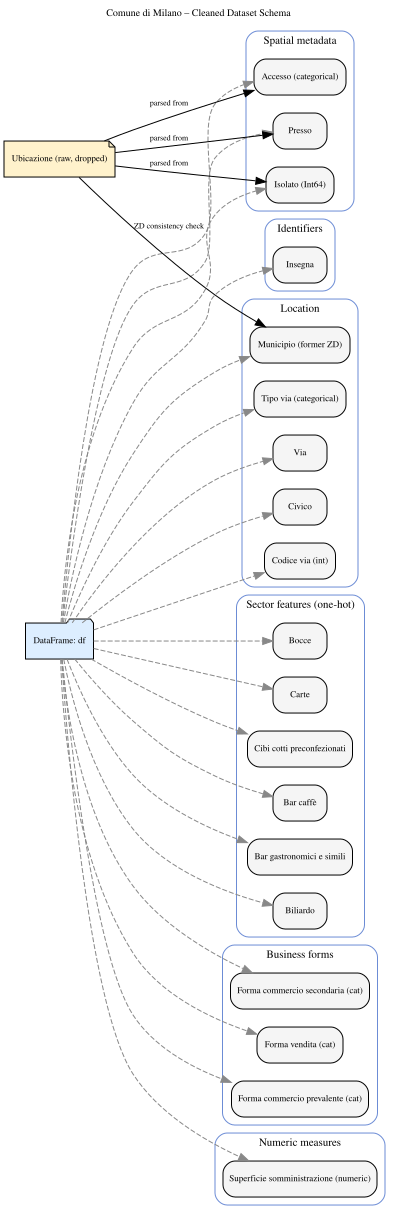

In [ ]:
# -----------------------------------------------------------
# VisualSchemaDiagram
# -----------------------------------------------------------

!apt-get -qq install graphviz > /dev/null
!pip install -q graphviz

from graphviz import Digraph

dot = Digraph("DQ_Schema", format="png")
dot.attr(rankdir="LR", fontsize="10", labelloc="t", label="Comune di Milano – Cleaned Dataset Schema")

# Global node style
dot.attr("node", shape="box", style="rounded,filled", fillcolor="#F5F5F5", fontsize="9")

# Main dataset node
dot.node("DF", "DataFrame: df", shape="folder", fillcolor="#DDEEFF")

# Identifiers
with dot.subgraph(name="cluster_identifiers") as c:
    c.attr(label="Identifiers", fontsize="11", style="rounded", color="#6C8CD5")
    c.node("Insegna", "Insegna")

# Location
with dot.subgraph(name="cluster_location") as c:
    c.attr(label="Location", fontsize="11", style="rounded", color="#6C8CD5")
    c.node("Tipo via", "Tipo via (categorical)")
    c.node("Via", "Via")
    c.node("Civico", "Civico")
    c.node("Codice via", "Codice via (int)")
    c.node("Municipio", "Municipio (former ZD)")

# Spatial metadata
with dot.subgraph(name="cluster_spatial_metadata") as c:
    c.attr(label="Spatial metadata", fontsize="11", style="rounded", color="#6C8CD5")
    c.node("Accesso", "Accesso (categorical)")
    c.node("Isolato", "Isolato (Int64)")
    c.node("Presso", "Presso")

# Business forms
with dot.subgraph(name="cluster_business_forms") as c:
    c.attr(label="Business forms", fontsize="11", style="rounded", color="#6C8CD5")
    c.node("Forma_com_prev", "Forma commercio prevalente (cat)")
    c.node("Forma_com_second", "Forma commercio secondaria (cat)")
    c.node("Forma_vendita", "Forma vendita (cat)")

# Numeric measures
with dot.subgraph(name="cluster_measures") as c:
    c.attr(label="Numeric measures", fontsize="11", style="rounded", color="#6C8CD5")
    c.node("Sup_som", "Superficie somministrazione (numeric)")

# Sector features (one-hot from 'Settore storico pe')
with dot.subgraph(name="cluster_sectors") as c:
    c.attr(label="Sector features (one-hot)", fontsize="11", style="rounded", color="#6C8CD5")
    example_sector_cols = list(settori.columns[:6])
    for col in example_sector_cols:
        c.node(f"sec_{col}", col)

# Edges: df "contains" groups
for col in [
    "Insegna", "Tipo via", "Via", "Civico", "Codice via", "Municipio",
    "Accesso", "Isolato", "Presso",
]:
    dot.edge("DF", col, style="dashed", color="#888888")

dot.edge("DF", "Forma_com_prev", style="dashed", color="#888888")
dot.edge("DF", "Forma_com_second", style="dashed", color="#888888")
dot.edge("DF", "Forma_vendita", style="dashed", color="#888888")
dot.edge("DF", "Sup_som", style="dashed", color="#888888")

for col in example_sector_cols:
    dot.edge("DF", f"sec_{col}", style="dashed", color="#888888")

# Highlight lineage from original 'Ubicazione' to derived attributes
dot.attr("node", shape="note", style="filled", fillcolor="#FFF2CC")
dot.node("Ubicazione_raw", "Ubicazione (raw, dropped)")
dot.edge("Ubicazione_raw", "Accesso", label="parsed from", fontsize="8")
dot.edge("Ubicazione_raw", "Isolato", label="parsed from", fontsize="8")
dot.edge("Ubicazione_raw", "Presso", label="parsed from", fontsize="8")
dot.edge("Ubicazione_raw", "Municipio", label="ZD consistency check", fontsize="8")

display(dot)

# ASSOCIATION RULES

We use **FP-Growth** and **Association Rules** to discover meaningful co-occurrence patterns among sectors, business forms, and spatial attributes in the dataset.

FP GROWTH:

- **Efficiency**: FP-Growth avoids candidate generation, making it significantly faster than Apriori—especially important given our many binary sector features.
- **Scalability**: It builds a compact FP-tree structure, enabling rapid mining of frequent itemsets without multiple database scans.
- **Computational feasibility**: Only two passes over the data are required, reducing processing time on larger datasets.

ASSOCIATION RULES:

- **Interpretability**: Rules like `Municipio=1 ∧ Bar caffè → Accesso=interno` provide explicit, human-readable insights into business patterns.
- **Quality metrics**: We filter rules using **support**, **confidence**, and **lift** to retain only statistically meaningful associations.
- **Data quality insights**: Rules can reveal hidden dependencies, redundancies, or inconsistencies
- **Actionable knowledge**: Patterns inform urban planning, anomaly detection, and compliance validation.

APPLICATION TO OUR DATASET

Given our multi-hot encoded sectors, categorical business forms, and structured location metadata, FP-Growth efficiently mines frequent itemsets. The resulting association rules uncover relationships such as:
- Sector co-occurrences within establishments
- Business form associations with municipal zones
- Systematic links between access type and sector categories

This approach supports both exploratory analysis and data quality validation.


In [ ]:
# ============================================
# FP-GROWTH + ASSOCIATION RULES
# ============================================

from mlxtend.frequent_patterns import fpgrowth, association_rules

# Frequency threshold: minimum support 5%
min_support = 0.05

frequent_itemsets = fpgrowth(
    settori,
    min_support=min_support,
    use_colnames=True
)

frequent_itemsets["length"] = frequent_itemsets["itemsets"].apply(len)

display(
    frequent_itemsets.sort_values(["length", "support"], ascending=[True, False])
)

# Assolute minimum confidence threshold
min_confidence = 0.9

a_rules = association_rules(
    frequent_itemsets,
    metric="confidence",
    min_threshold=min_confidence
)

a_rules = a_rules.sort_values(
    ["confidence", "lift", "support"],
    ascending=[False, False, False]
).reset_index(drop=True)

display(a_rules)

# Rules with single-item consequents
df.loc[df["Genere merceol.autorizz.sanit."] & df["Tavola fredda"], "Bar caffè"] = True
df.loc[df["Cibi cotti preconfezionati"], "Bar caffè"] = True

,support,itemsets,length
0,0.459420,(Bar caffè),1
4,0.311594,(Mensa),1
1,0.302415,(Genere merceol.autorizz.sanit.),1
2,0.213043,(Tavola fredda),1
5,0.067633,(Tavola calda),1
...,...,...,...
7,0.185024,"(Genere merceol.autorizz.sanit., Bar caffè)",2
9,0.107246,"(Genere merceol.autorizz.sanit., Tavola fredda)",2
11,0.056039,"(Bar caffè, Bar gastronomici e simili)",2
12,0.055556,"(Bar caffè, Cibi cotti preconfezionati)",2


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,"(Genere merceol.autorizz.sanit., Tavola fredda)",(Bar caffè),0.107246,0.45942,0.103865,0.968468,2.108023,1.0,0.054594,17.144099,0.588765,0.224426,0.941671,0.597273
1,(Cibi cotti preconfezionati),(Bar caffè),0.058454,0.45942,0.055556,0.950413,2.068723,1.0,0.028701,10.901691,0.548683,0.120167,0.908271,0.535669



After mining frequent itemsets and extracting association rules, we identify high-confidence patterns that reveal systematic dependencies between sector categories. These rules are leveraged to **impute missing or incomplete sector labels** in a principled, data-driven manner.

Specifically, we apply rules with very high confidence (≥ 0.9) and meaningful lift to infer the presence of the consequent sector when the antecedent is observed. For example:
- If an establishment has `Genere merceol.autorizz.sanit.` AND `Tavola fredda`, we infer `Bar caffè = True`
- If an establishment has `Cibi cotti preconfezionati`, we infer `Bar caffè = True`

This approach ensures that imputation is **grounded in real co-occurrence patterns** rather than arbitrary assumptions, improving data completeness while preserving semantic consistency.

In [ ]:
from efficient_apriori import apriori
import pandas as pd

def mine_rules(data, min_support=0.01, min_confidence=0.8, exclude_value="Assente"):
    """
    Extracts rules from the dataset using efficient_apriori.
    Each item is represented as 'column=value'.
    Filters out rules containing 'Assente'.
    """
    records = [
        [f"{col}={val}" for col, val in row.items()]
        for _, row in data.iterrows()
    ]

    itemsets, rules = apriori(
        records,
        min_support=min_support,
        min_confidence=min_confidence
    )

    filtered_rules = []
    for rule in rules:
        lhs_ok = all(exclude_value not in item for item in rule.lhs)
        rhs_ok = all(exclude_value not in item for item in rule.rhs)
        if lhs_ok and rhs_ok:
            filtered_rules.append(rule)

    filtered_rules.sort(key=lambda r: (r.confidence, r.support), reverse=True)
    return filtered_rules

In [ ]:
cols_rules = ["Forma commercio prevalente", "Forma commercio secondaria", "Forma vendita"]

dataset_for_rules = df[cols_rules].copy()

for col in cols_rules:
    mode = dataset_for_rules[col].mode().iloc[0]

    # Fill the NaN value with the mode
    dataset_for_rules[col] = dataset_for_rules[col].fillna(mode)

res = mine_rules(dataset_for_rules, min_support=0.01, min_confidence=0.5)
print(f"Found: {len(res)} rules")

Found: 10 rules


In [ ]:
def build_mask_from_items(items, df):
    '''
    Creates a boolean mask to identify rows matching all specified item conditions.
    Args:
        items: List of strings in format "column=value" representing conditions
        df: DataFrame to apply the mask to
    Returns:
        Boolean Series where True indicates rows matching ALL conditions (AND logic)
    '''
    mask = pd.Series(True, index=df.index)
    for item in items:
        col, val = item.split("=", 1)
        mask &= (df[col] == val)
    return mask

After extracting high-confidence association rules from the dataset, we apply them systematically to **fill missing values** in a data-driven manner. This approach leverages discovered co-occurrence patterns to infer likely values for incomplete records, improving dataset completeness while preserving semantic consistency.

IMPLEMENTATION LOGIC:

For each rule extracted by the mining algorithm:
1. **Identify candidate rows**: We build a boolean mask selecting all rows that satisfy the rule's antecedent (LHS).
2. **Target missing values**: Among these candidate rows, we further filter only those where the consequent attribute is currently `NULL`.
3. **Apply imputation**: We assign the consequent value (RHS) to the missing cells, effectively filling gaps based on observed patterns.

This method ensures that imputation is:
- **Evidence-based**: grounded in real statistical dependencies
- **Conservative**: only applied where values are missing
- **Interpretable**: each imputation can be traced back to a specific rule


The rule-based imputation process systematically reduces missing values in categorical attributes (e.g., business forms, spatial metadata) by exploiting the relational structure embedded in the data, thus enhancing both **completeness** and **consistency** dimensions of data quality.

In [ ]:
for target_col in cols_rules:
    print(f"\n===== TARGET: {target_col} =====\n")

    # Select only rules with single RHS item for the target column
    rules_for_target = []
    for r in res:
        rhs_items_target = [item for item in r.rhs if item.startswith(target_col)]
        if len(rhs_items_target) == 1:
            rules_for_target.append((r, rhs_items_target[0]))

    print(f"Rules usable to impute {target_col}: {len(rules_for_target)}\n")

    # For each rule, see how many rows with missing target can be imputed
    for i, (rule, rhs_item) in enumerate(rules_for_target[:10]):
        lhs_mask = build_mask_from_items(rule.lhs, df)
        missing_mask = df[target_col].isnull()
        mask = lhs_mask & missing_mask

        _, rhs_value = rhs_item.split("=", 1)

        print()
        print(f"Regola #{i} -> {rule}")
        print(f"  {target_col} imputed with: {rhs_value}")
        print(f"  support={rule.support:.3f}, conf={rule.confidence:.3f}")
        print(f"  imputable rows: {mask.sum()}\n")

        if (mask.sum() > 0):
          display(df[mask])
        print(f"━"*80)

    print("="*80)
    print("="*80)


===== TARGET: Forma commercio prevalente =====

Rules usable to impute Forma commercio prevalente: 7


Regola #0 -> {Forma vendita=self service} -> {Forma commercio prevalente=somministrazione} (conf: 1.000, supp: 0.180, lift: 1.003, conv: 3030303.030)
  Forma commercio prevalente imputed with: somministrazione
  support=0.180, conf=1.000
  imputable rows: 2



,Insegna,Tipo via,Via,Civico,Codice via,Municipio,Accesso,Isolato,Presso,Forma commercio prevalente,Forma commercio secondaria,Forma vendita,Superficie somministrazione,Bar caffè,Bar gastronomici e simili,Biliardo,Bocce,Carte,Cibi cotti preconfezionati,Discoteche,Genere merceol.autorizz.sanit.,Giochi legge 388/2000,Mensa,Pizzeria,Prodotti di gastronomia,Ristorante,Spaccio bevande analcoliche,Tavola calda,Tavola fredda,Fast food,Osteria,Self service,Trattoria
1641,s. tommaso moro,VIA,INGANNI ANGELO,12,6672,6,NaN,92,s. tommaso moro,NaN,NaN,self service,<NA>,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False
1692,istituto oxologico italia,VIA,BIANCHI MOSE',90,6385,7,NaN,<NA>,istituto auxologico italia,NaN,NaN,self service,161,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,True,False,True,False


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Regola #1 -> {Forma commercio secondaria=minuto} -> {Forma commercio prevalente=somministrazione} (conf: 1.000, supp: 0.020, lift: 1.003, conv: 3030303.030)
  Forma commercio prevalente imputed with: somministrazione
  support=0.020, conf=1.000
  imputable rows: 0

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Regola #2 -> {Forma vendita=al tavolo} -> {Forma commercio prevalente=somministrazione} (conf: 1.000, supp: 0.016, lift: 1.003, conv: 3030303.030)
  Forma commercio prevalente imputed with: somministrazione
  support=0.016, conf=1.000
  imputable rows: 0

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Regola #3 -> {Forma commercio secondaria=minuto, Forma vendita=al banco} -> {Forma commercio prevalente=somministrazione} (conf: 1.000, supp: 0.014, lift: 1.003, conv: 3030303.030)
  Forma commercio prevalente imputed with: somminis

,Insegna,Tipo via,Via,Civico,Codice via,Municipio,Accesso,Isolato,Presso,Forma commercio prevalente,Forma commercio secondaria,Forma vendita,Superficie somministrazione,Bar caffè,Bar gastronomici e simili,Biliardo,Bocce,Carte,Cibi cotti preconfezionati,Discoteche,Genere merceol.autorizz.sanit.,Giochi legge 388/2000,Mensa,Pizzeria,Prodotti di gastronomia,Ristorante,Spaccio bevande analcoliche,Tavola calda,Tavola fredda,Fast food,Osteria,Self service,Trattoria
228,NaN,VIA,CARLI GIAN RINALDO,26,1563,9,NaN,48,NaN,somministrazione,Assente,NaN,160,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
263,NaN,VIA,KRAMER ANTONIO,22,3180,3,NaN,155,NaN,somministrazione,Assente,NaN,37,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
436,istituto auxologico itali,VIA,BIANCHI MOSE',90,6385,7,NaN,<NA>,istituto auxologico italia,somministrazione,Assente,NaN,63,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
453,nuova accad. belle arti,VIA,DARWIN CARLO ROBERTO,20,5238,6,NaN,80,scuola formazione,somministrazione,Assente,NaN,<NA>,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False
887,NaN,VIA,F.LLI BRESSAN,34,2349,2,NaN,97,circolo,somministrazione,Assente,NaN,153,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1660,NaN,VIA,LOPE DE VEGA FELICE,2,5408,6,NaN,<NA>,residenza sanitaria assist,somministrazione,minuto,NaN,25,False,False,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False
1697,ospedale,PIAZZA,FERRARI ANDREA CARDINALE,1,4012,1,NaN,205,ospedale ortopedico gaetan,somministrazione,Assente,NaN,309,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,True,False,True,False
1733,NaN,VIA,LECCO,6,2110,3,NaN,130,NaN,somministrazione,Assente,NaN,98,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False
1775,ragno d oro,PIAZZALE,MEDAGLIE D'ORO,2,4104,5,accesso esterno,92,NaN,somministrazione,Assente,NaN,550,False,False,False,False,False,False,True,True,False,False,False,False,False,False,False,False,False,False,False,False


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Regola #1 -> {Forma commercio secondaria=minuto} -> {Forma vendita=al banco} (conf: 0.718, supp: 0.014, lift: 0.981, conv: 0.951)
  Forma vendita imputed with: al banco
  support=0.014, conf=0.718
  imputable rows: 1



...

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Regola #2 -> {Forma commercio prevalente=somministrazione, Forma commercio secondaria=minuto} -> {Forma vendita=al banco} (conf: 0.718, supp: 0.014, lift: 0.981, conv: 0.951)
  Forma vendita imputed with: al banco
  support=0.014, conf=0.718
  imputable rows: 1



,Insegna,Tipo via,Via,Civico,Codice via,Municipio,Accesso,Isolato,Presso,Forma commercio prevalente,Forma commercio secondaria,Forma vendita,Superficie somministrazione,Bar caffè,Bar gastronomici e simili,Biliardo,Bocce,Carte,Cibi cotti preconfezionati,Discoteche,Genere merceol.autorizz.sanit.,Giochi legge 388/2000,Mensa,Pizzeria,Prodotti di gastronomia,Ristorante,Spaccio bevande analcoliche,Tavola calda,Tavola fredda,Fast food,Osteria,Self service,Trattoria
1660,NaN,VIA,LOPE DE VEGA FELICE,2,5408,6,NaN,<NA>,residenza sanitaria assist,somministrazione,minuto,NaN,25,False,False,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Regola #3 -> {Forma commercio secondaria=minuto} -> {Forma commercio prevalente=somministrazione, Forma vendita=al banco} (conf: 0.718, supp: 0.014, lift: 0.984, conv: 0.958)
  Forma vendita imputed with: al banco
  support=0.014, conf=0.718
  imputable rows: 1



,Insegna,Tipo via,Via,Civico,Codice via,Municipio,Accesso,Isolato,Presso,Forma commercio prevalente,Forma commercio secondaria,Forma vendita,Superficie somministrazione,Bar caffè,Bar gastronomici e simili,Biliardo,Bocce,Carte,Cibi cotti preconfezionati,Discoteche,Genere merceol.autorizz.sanit.,Giochi legge 388/2000,Mensa,Pizzeria,Prodotti di gastronomia,Ristorante,Spaccio bevande analcoliche,Tavola calda,Tavola fredda,Fast food,Osteria,Self service,Trattoria
1660,NaN,VIA,LOPE DE VEGA FELICE,2,5408,6,NaN,<NA>,residenza sanitaria assist,somministrazione,minuto,NaN,25,False,False,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


This cell applies the previously extracted association rules to systematically fill missing values in categorical business form attributes.

For each rule with high confidence, it identifies rows matching the antecedent conditions (LHS) and imputes the consequent value (RHS) where the target attribute is currently NULL.

This data-driven imputation leverages discovered co-occurrence patterns to improve dataset completeness while maintaining semantic consistency with observed relationships.

In [ ]:
df_imputed = df.copy()
imputation_report = []

for target_col in cols_rules:
    print(f"\n===== IMPUTING TARGET: {target_col} =====\n")

    # Select only rules that predict this target in the RHS
    rules_for_target = []
    for r in res:
        rhs_items_target = [item for item in r.rhs if item.startswith(f"{target_col}=")]
        if len(rhs_items_target) == 1:
            rules_for_target.append((r, rhs_items_target[0]))

    print(f"Usable rules for '{target_col}': {len(rules_for_target)}")

    # Apply each rule to impute missing values
    total_imputed_for_target = 0

    for rule, rhs_item in rules_for_target:
        # LHS must be true
        lhs_mask = build_mask_from_items(rule.lhs, df_imputed)
        # only rows where target is missing
        missing_mask = df_imputed[target_col].isnull()
        # rows where we can apply the rule
        mask = lhs_mask & missing_mask

        if mask.sum() == 0:
            continue

        # RHS value to assign
        _, rhs_value = rhs_item.split("=", 1)

        # Impute
        df_imputed.loc[mask, target_col] = rhs_value

        total_imputed_for_target += mask.sum()

        imputation_report.append({
            "target": target_col,
            "rule": str(rule),
            "rhs_value": rhs_value,
            "support": rule.support,
            "confidence": rule.confidence,
            "rows_imputed": int(mask.sum())
        })

        print(f"- Rule {rule}")
        print(f"  -> Imputed {mask.sum()} rows with {target_col} = '{rhs_value}'")

        print("\nBase df:")
        display(df[mask])
        print("\nImputed df:")
        display(df_imputed[mask])

    print(f"\nTotal imputed for {target_col}: {total_imputed_for_target}")
    print("============================================================")


===== IMPUTING TARGET: Forma commercio prevalente =====

Usable rules for 'Forma commercio prevalente': 7
- Rule {Forma vendita=self service} -> {Forma commercio prevalente=somministrazione} (conf: 1.000, supp: 0.180, lift: 1.003, conv: 3030303.030)
  -> Imputed 2 rows with Forma commercio prevalente = 'somministrazione'

Base df:


,Insegna,Tipo via,Via,Civico,Codice via,Municipio,Accesso,Isolato,Presso,Forma commercio prevalente,Forma commercio secondaria,Forma vendita,Superficie somministrazione,Bar caffè,Bar gastronomici e simili,Biliardo,Bocce,Carte,Cibi cotti preconfezionati,Discoteche,Genere merceol.autorizz.sanit.,Giochi legge 388/2000,Mensa,Pizzeria,Prodotti di gastronomia,Ristorante,Spaccio bevande analcoliche,Tavola calda,Tavola fredda,Fast food,Osteria,Self service,Trattoria
1641,s. tommaso moro,VIA,INGANNI ANGELO,12,6672,6,NaN,92,s. tommaso moro,NaN,NaN,self service,<NA>,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False
1692,istituto oxologico italia,VIA,BIANCHI MOSE',90,6385,7,NaN,<NA>,istituto auxologico italia,NaN,NaN,self service,161,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,True,False,True,False



Imputed df:


,Insegna,Tipo via,Via,Civico,Codice via,Municipio,Accesso,Isolato,Presso,Forma commercio prevalente,Forma commercio secondaria,Forma vendita,Superficie somministrazione,Bar caffè,Bar gastronomici e simili,Biliardo,Bocce,Carte,Cibi cotti preconfezionati,Discoteche,Genere merceol.autorizz.sanit.,Giochi legge 388/2000,Mensa,Pizzeria,Prodotti di gastronomia,Ristorante,Spaccio bevande analcoliche,Tavola calda,Tavola fredda,Fast food,Osteria,Self service,Trattoria
1641,s. tommaso moro,VIA,INGANNI ANGELO,12,6672,6,NaN,92,s. tommaso moro,somministrazione,NaN,self service,<NA>,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False
1692,istituto oxologico italia,VIA,BIANCHI MOSE',90,6385,7,NaN,<NA>,istituto auxologico italia,somministrazione,NaN,self service,161,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,True,False,True,False



Total imputed for Forma commercio prevalente: 2

===== IMPUTING TARGET: Forma commercio secondaria =====

Usable rules for 'Forma commercio secondaria': 0

Total imputed for Forma commercio secondaria: 0

===== IMPUTING TARGET: Forma vendita =====

Usable rules for 'Forma vendita': 4
- Rule {Forma commercio prevalente=somministrazione} -> {Forma vendita=al banco} (conf: 0.732, supp: 0.730, lift: 1.000, conv: 1.001)
  -> Imputed 21 rows with Forma vendita = 'al banco'

Base df:


,Insegna,Tipo via,Via,Civico,Codice via,Municipio,Accesso,Isolato,Presso,Forma commercio prevalente,Forma commercio secondaria,Forma vendita,Superficie somministrazione,Bar caffè,Bar gastronomici e simili,Biliardo,Bocce,Carte,Cibi cotti preconfezionati,Discoteche,Genere merceol.autorizz.sanit.,Giochi legge 388/2000,Mensa,Pizzeria,Prodotti di gastronomia,Ristorante,Spaccio bevande analcoliche,Tavola calda,Tavola fredda,Fast food,Osteria,Self service,Trattoria
228,NaN,VIA,CARLI GIAN RINALDO,26,1563,9,NaN,48,NaN,somministrazione,Assente,NaN,160,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
263,NaN,VIA,KRAMER ANTONIO,22,3180,3,NaN,155,NaN,somministrazione,Assente,NaN,37,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
436,istituto auxologico itali,VIA,BIANCHI MOSE',90,6385,7,NaN,<NA>,istituto auxologico italia,somministrazione,Assente,NaN,63,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
453,nuova accad. belle arti,VIA,DARWIN CARLO ROBERTO,20,5238,6,NaN,80,scuola formazione,somministrazione,Assente,NaN,<NA>,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False
887,NaN,VIA,F.LLI BRESSAN,34,2349,2,NaN,97,circolo,somministrazione,Assente,NaN,153,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1660,NaN,VIA,LOPE DE VEGA FELICE,2,5408,6,NaN,<NA>,residenza sanitaria assist,somministrazione,minuto,NaN,25,False,False,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False
1697,ospedale,PIAZZA,FERRARI ANDREA CARDINALE,1,4012,1,NaN,205,ospedale ortopedico gaetan,somministrazione,Assente,NaN,309,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,True,False,True,False
1733,NaN,VIA,LECCO,6,2110,3,NaN,130,NaN,somministrazione,Assente,NaN,98,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False
1775,ragno d oro,PIAZZALE,MEDAGLIE D'ORO,2,4104,5,accesso esterno,92,NaN,somministrazione,Assente,NaN,550,False,False,False,False,False,False,True,True,False,False,False,False,False,False,False,False,False,False,False,False



Imputed df:


,Insegna,Tipo via,Via,Civico,Codice via,Municipio,Accesso,Isolato,Presso,Forma commercio prevalente,Forma commercio secondaria,Forma vendita,Superficie somministrazione,Bar caffè,Bar gastronomici e simili,Biliardo,Bocce,Carte,Cibi cotti preconfezionati,Discoteche,Genere merceol.autorizz.sanit.,Giochi legge 388/2000,Mensa,Pizzeria,Prodotti di gastronomia,Ristorante,Spaccio bevande analcoliche,Tavola calda,Tavola fredda,Fast food,Osteria,Self service,Trattoria
228,NaN,VIA,CARLI GIAN RINALDO,26,1563,9,NaN,48,NaN,somministrazione,Assente,al banco,160,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
263,NaN,VIA,KRAMER ANTONIO,22,3180,3,NaN,155,NaN,somministrazione,Assente,al banco,37,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
436,istituto auxologico itali,VIA,BIANCHI MOSE',90,6385,7,NaN,<NA>,istituto auxologico italia,somministrazione,Assente,al banco,63,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
453,nuova accad. belle arti,VIA,DARWIN CARLO ROBERTO,20,5238,6,NaN,80,scuola formazione,somministrazione,Assente,al banco,<NA>,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False
887,NaN,VIA,F.LLI BRESSAN,34,2349,2,NaN,97,circolo,somministrazione,Assente,al banco,153,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1660,NaN,VIA,LOPE DE VEGA FELICE,2,5408,6,NaN,<NA>,residenza sanitaria assist,somministrazione,minuto,al banco,25,False,False,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False
1697,ospedale,PIAZZA,FERRARI ANDREA CARDINALE,1,4012,1,NaN,205,ospedale ortopedico gaetan,somministrazione,Assente,al banco,309,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,True,False,True,False
1733,NaN,VIA,LECCO,6,2110,3,NaN,130,NaN,somministrazione,Assente,al banco,98,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False
1775,ragno d oro,PIAZZALE,MEDAGLIE D'ORO,2,4104,5,accesso esterno,92,NaN,somministrazione,Assente,al banco,550,False,False,False,False,False,False,True,True,False,False,False,False,False,False,False,False,False,False,False,False



Total imputed for Forma vendita: 21


This cell creates a summary report of all automatic imputations performed using association rules.

The report shows which values were filled, which rules were applied, their confidence/support scores, and how many rows were affected providing a complete audit trail of the imputation process.


In [ ]:
def comparison_table_forNullValue(df_original, df_imputed, orderIndexFeature = 1):
  # Get the columns present in the imputed dataframe, which represents the final state
  common_cols = df_imputed.columns

  # Calculate nulls for the original dataset, considering only the common columns
  null_df = df_original[common_cols].isnull().sum()

  # Calculate nulls for the imputed dataset
  null_imputed = df_imputed.isnull().sum()

  if (orderIndexFeature == 1):
    orderIndexFeature = "Null_Count (df)"
  elif (orderIndexFeature == 2):
    orderIndexFeature = "Null_count (df_imputed)"

  comparison_table = pd.DataFrame({
      "Feature": common_cols,
      "Null_Count (df)": null_df.values,
      "Null_count (df_imputed)": null_imputed.values
  })

  comparison_table.set_index("Feature", inplace=True)
  comparison_table = comparison_table.sort_values(orderIndexFeature, ascending=False)

  display(comparison_table)

comparison_table_forNullValue(df, df_imputed, 2)

,Null_Count (df),Null_count (df_imputed)
Feature,,
Insegna,1414,1414
Accesso,1033,1033
Presso,1003,1003
Forma commercio secondaria,966,966
Forma commercio prevalente,953,951
...,...,...
Tavola fredda,0,0
Fast food,0,0
Osteria,0,0


The next cell overwrites the original dataframe df with the newly imputed version.

Be careful: from this point onward, df contains the imputed values.
If you rerun any previous cells, they will operate on the imputed dataframe rather than the original one.

In [ ]:
df = df_imputed

# Missing Values

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import missingno as mno

from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier

sns.set(style="whitegrid")


The missingno bar chart provides a quick visual summary of data completeness.

Each bar represents a feature, and its height indicates the number of non-null values.

This allows us to immediately identify which attributes suffer from high missingness,
guiding subsequent imputation strategies or indicating potential data collection issues.

Features with very short bars may require domain-specific handling or could be candidates
for removal if they lack sufficient information for analysis.

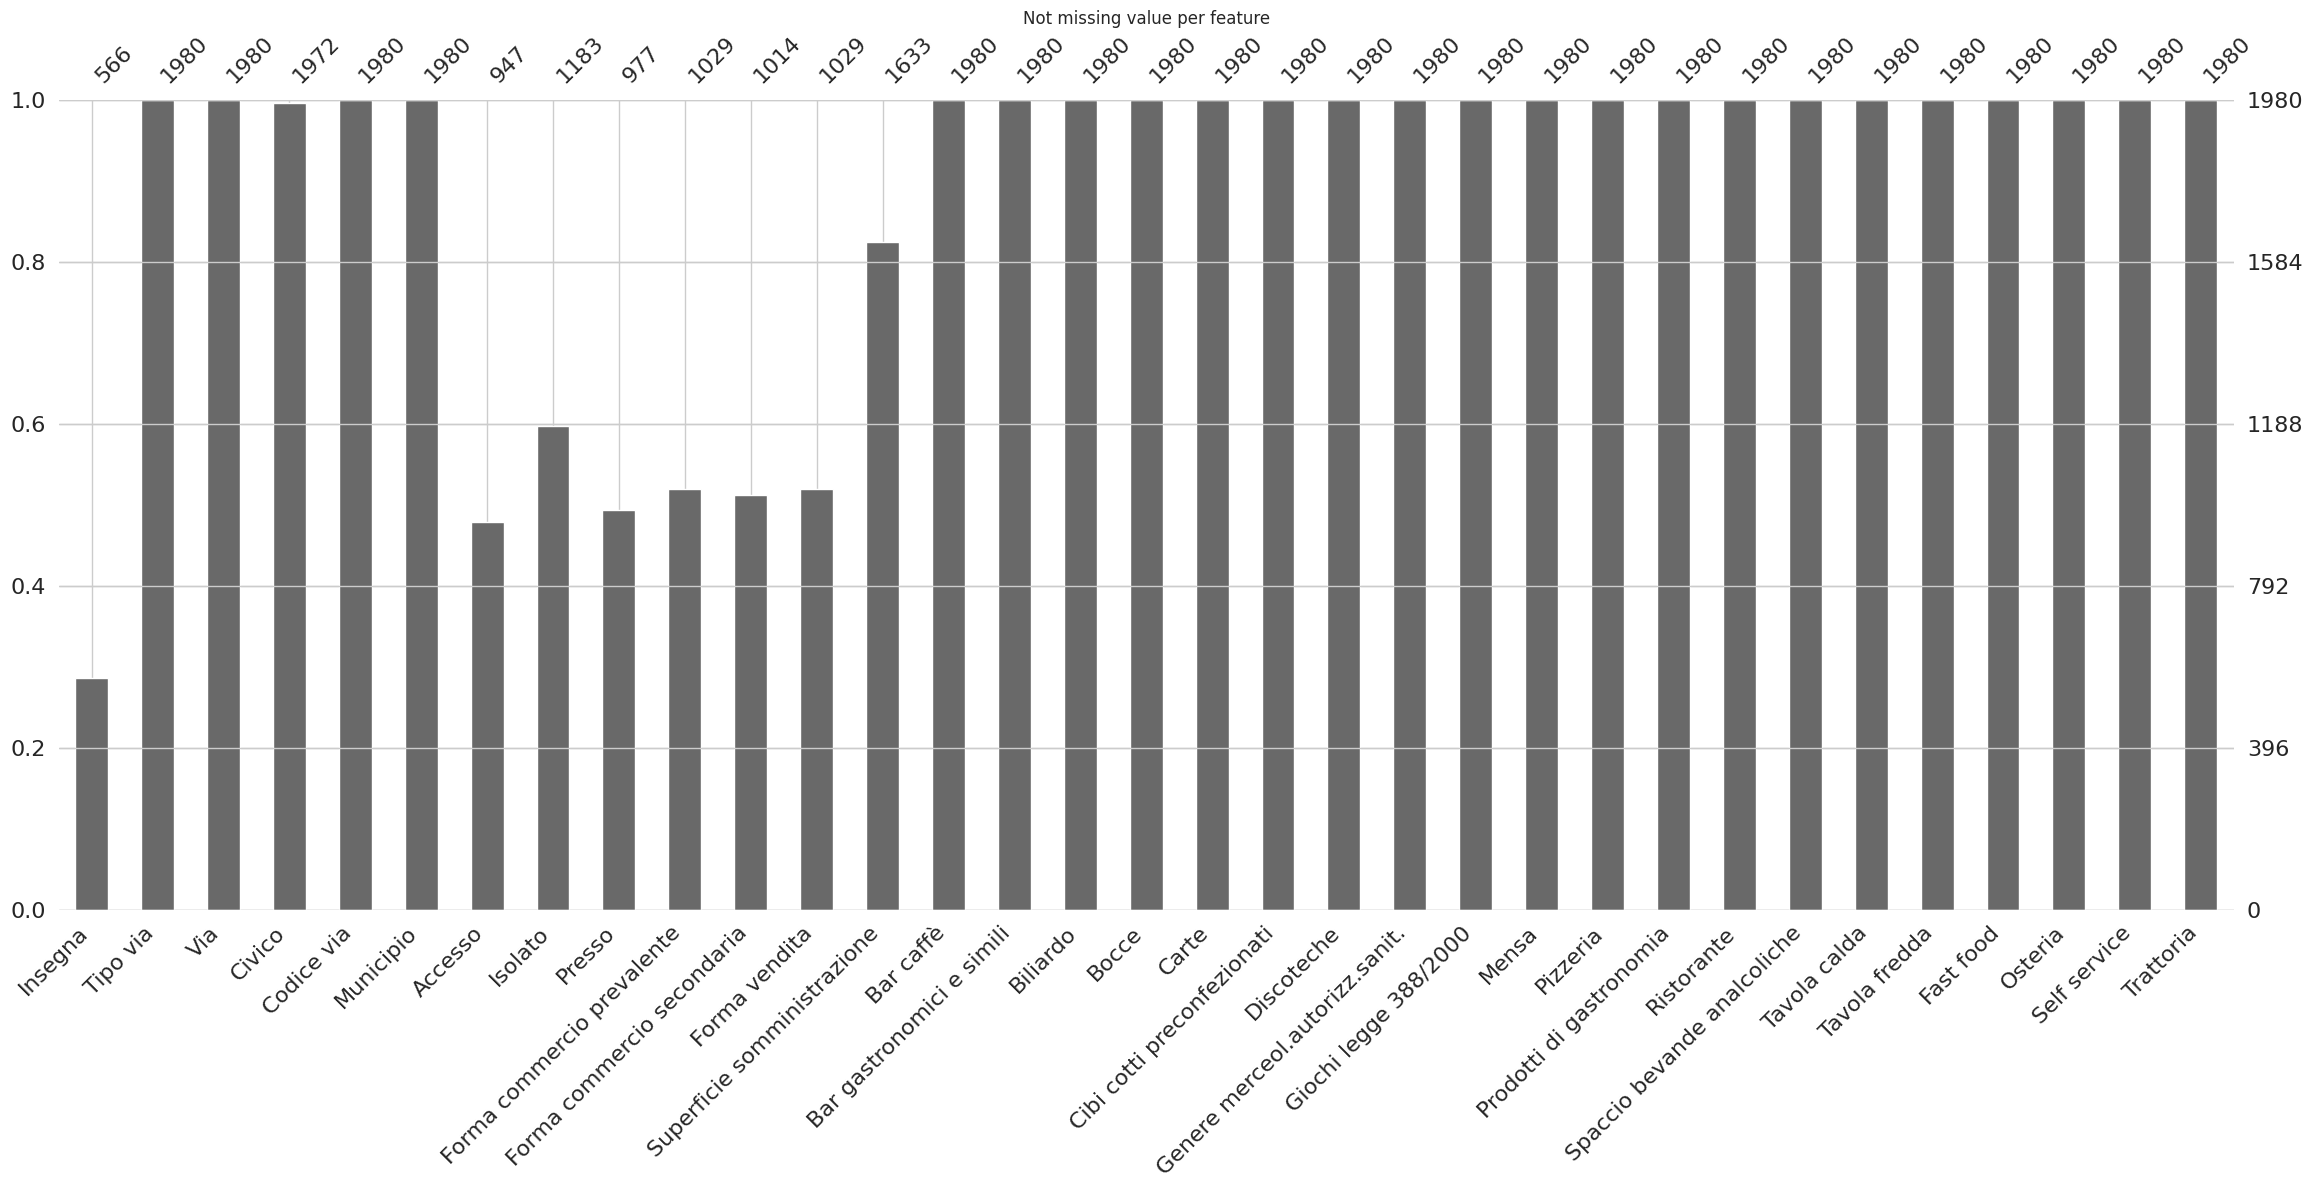

In [ ]:
plt.figure(figsize=(12, 6))
mno.bar(df)
plt.title("Not missing value per feature")
plt.show()

These features are filled with **semantically meaningful defaults** rather than using statistical methods because:

- **Civico** (street number): "S.N.C." (Senza Numero Civico = without civic number) is a standard Italian administrative designation for addresses lacking official numbering
- **Insegna** (shop sign) and **Presso** (at/care of): Missing values indicate absence of information rather than unknown values—"Non specificata/o" (not specified) accurately represents this state
- **Isolato** (block): Zero indicates no block assignment, which is a valid administrative state
- **Forma commercio secondaria** (secondary commerce form): "Assente" (absent) correctly represents shops operating under a single commerce form only

This approach preserves data semantics and avoids introducing artificial patterns that would occur with median/mode imputation or predictive models for these administratively defined fields.

In [ ]:
df["Civico"] = df["Civico"].fillna("S.N.C.")
df["Insegna"] = df["Insegna"].fillna("Non specificata")
df["Presso"] = df["Presso"].fillna("Non specificato")
df["Isolato"] = df["Isolato"].fillna(0)
df["Forma commercio secondaria"] = df["Forma commercio secondaria"].fillna("Assente")

print("Simple imputations completed.")

df.head(20)

Simple imputations completed.


,Insegna,Tipo via,Via,Civico,Codice via,Municipio,Accesso,Isolato,Presso,Forma commercio prevalente,Forma commercio secondaria,Forma vendita,Superficie somministrazione,Bar caffè,Bar gastronomici e simili,Biliardo,Bocce,Carte,Cibi cotti preconfezionati,Discoteche,Genere merceol.autorizz.sanit.,Giochi legge 388/2000,Mensa,Pizzeria,Prodotti di gastronomia,Ristorante,Spaccio bevande analcoliche,Tavola calda,Tavola fredda,Fast food,Osteria,Self service,Trattoria
0,Non specificata,PIAZZA,OSPEDALE MAGGIORE,3,1523,9,NaN,0,Non specificato,NaN,Assente,NaN,<NA>,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,Non specificata,VIALE,ALEMAGNA EMILIO,6,7106,1,NaN,0,Non specificato,NaN,Assente,NaN,<NA>,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,Non specificata,VIA,SERIO,15,4130,5,NaN,0,Non specificato,NaN,Assente,NaN,110,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,Non specificata,CORSO,BUENOS AIRES,36,2129,3,NaN,0,Non specificato,NaN,Assente,NaN,<NA>,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,Non specificata,CORSO,MATTEOTTI GIACOMO,7,218,1,NaN,0,Non specificato,NaN,Assente,NaN,<NA>,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15,Non specificata,PIAZZA,ESQUILINO,9,6533,7,NaN,0,Non specificato,NaN,Assente,NaN,263,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
16,Non specificata,PIAZZA,LUIGI DI SAVOIA,1,2260,2,NaN,0,Non specificato,NaN,Assente,NaN,222,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
17,Non specificata,PIAZZA,OSPEDALE MAGGIORE,3,1523,9,NaN,0,Non specificato,NaN,Assente,NaN,31,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
18,Non specificata,PIAZZA,STUPARICH CARLO,1,6468,8,NaN,0,palalido,NaN,Assente,NaN,80,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [ ]:
def one_hot_encode(df, categorical_cols=None):
    if categorical_cols is None:
        categorical_cols = df.select_dtypes(include=['object', 'category', 'bool']).columns
    return pd.get_dummies(df, columns=list(categorical_cols), dummy_na=False)

In [ ]:
# ============================================================
# SETUP MODEL-BASED IMPUTATION
# ============================================================

missing_columns = ["Superficie somministrazione", "Forma commercio prevalente", "Forma vendita", "Accesso"]

IMP_DATA = pd.DataFrame(
    index=df.index,
    columns=["IMP_" + name for name in missing_columns]
)

CAT_COLUMNS = list(df.select_dtypes(include=['bool', 'object', 'category']).columns)
NUM_COLUMNS = list(df.select_dtypes(include=['Int64', 'int64', 'float64']).columns)

# Starting point for imputations (median/mode)
for feature in missing_columns:
    imp_col = feature + "_imp"
    df[imp_col] = df[feature]

    if feature in NUM_COLUMNS:
        df.loc[df[feature].isnull(), imp_col] = round(df[feature].median())
    else:
        df.loc[df[feature].isnull(), imp_col] = df[feature].mode().iloc[0]

print("Initial values imputed (median/mode).")

df.head(20)

Initial values imputed (median/mode).


,Insegna,Tipo via,Via,Civico,Codice via,Municipio,Accesso,Isolato,Presso,Forma commercio prevalente,Forma commercio secondaria,Forma vendita,Superficie somministrazione,Bar caffè,Bar gastronomici e simili,Biliardo,Bocce,Carte,Cibi cotti preconfezionati,Discoteche,Genere merceol.autorizz.sanit.,Giochi legge 388/2000,Mensa,Pizzeria,Prodotti di gastronomia,Ristorante,Spaccio bevande analcoliche,Tavola calda,Tavola fredda,Fast food,Osteria,Self service,Trattoria,Superficie somministrazione_imp,Forma commercio prevalente_imp,Forma vendita_imp,Accesso_imp
0,Non specificata,PIAZZA,OSPEDALE MAGGIORE,3,1523,9,NaN,0,Non specificato,NaN,Assente,NaN,<NA>,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,100,somministrazione,al banco,accesso interno
1,Non specificata,VIALE,ALEMAGNA EMILIO,6,7106,1,NaN,0,Non specificato,NaN,Assente,NaN,<NA>,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,100,somministrazione,al banco,accesso interno
2,Non specificata,VIA,SERIO,15,4130,5,NaN,0,Non specificato,NaN,Assente,NaN,110,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,110,somministrazione,al banco,accesso interno
3,Non specificata,CORSO,BUENOS AIRES,36,2129,3,NaN,0,Non specificato,NaN,Assente,NaN,<NA>,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,100,somministrazione,al banco,accesso interno
4,Non specificata,CORSO,MATTEOTTI GIACOMO,7,218,1,NaN,0,Non specificato,NaN,Assente,NaN,<NA>,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,100,somministrazione,al banco,accesso interno
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15,Non specificata,PIAZZA,ESQUILINO,9,6533,7,NaN,0,Non specificato,NaN,Assente,NaN,263,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,263,somministrazione,al banco,accesso interno
16,Non specificata,PIAZZA,LUIGI DI SAVOIA,1,2260,2,NaN,0,Non specificato,NaN,Assente,NaN,222,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,222,somministrazione,al banco,accesso interno
17,Non specificata,PIAZZA,OSPEDALE MAGGIORE,3,1523,9,NaN,0,Non specificato,NaN,Assente,NaN,31,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,31,somministrazione,al banco,accesso interno
18,Non specificata,PIAZZA,STUPARICH CARLO,1,6468,8,NaN,0,palalido,NaN,Assente,NaN,80,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,80,somministrazione,al banco,accesso interno


This section installs the packages required to run a RandomForest model on the GPU (if available).

Uncomment the line below if you want to enable GPU support and the necessary packages are not already installed on your system.


In [ ]:
'''# Install RAPIDS (cuML, cuDF, cuGraph, etc.)
!pip install -U "cuml-cu11" "cudf-cu11" -f https://rapidsai.github.io/nightly-conda-forge/

# If Colab complains about numba, fix it:
!pip install numba==0.57 llvmlite==0.40'''

'# Install RAPIDS (cuML, cuDF, cuGraph, etc.)\n!pip install -U "cuml-cu11" "cudf-cu11" -f https://rapidsai.github.io/nightly-conda-forge/\n\n# If Colab complains about numba, fix it:\n!pip install numba==0.57 llvmlite==0.40'

Hardware Detection

In [ ]:
use_gpu = False

try:
    import cuml
    from cuml.ensemble import RandomForestRegressor as cuRFReg
    from cuml.ensemble import RandomForestClassifier as cuRFClf

    try:
        import numba.cuda as ncu
        if ncu.is_available():
            use_gpu = True
            print("GPU available: using cuML RandomForest")
        else:
            print("cuML imported, but no GPU available: using scikit-learn")
    except Exception as e:
        print(f"Problem checking GPU ({e}): using scikit-learn")
except ImportError:
    print("cuML not available: using scikit-learn")
    cuml = None

from sklearn.ensemble import RandomForestRegressor as skRFReg
from sklearn.ensemble import RandomForestClassifier as skRFClf

cuML imported, but no GPU available: using scikit-learn


Random Forest Function Call

In [ ]:
def get_rf_model(is_numeric):
    """
    Returns a Random Forest:
    - GPU version (cuML) if available and GPU present
    - otherwise CPU version (scikit-learn)
    """
    if use_gpu and cuml is not None:
        if is_numeric:
            return cuRFReg(n_estimators=1000)
        else:
            return cuRFClf(n_estimators=1000)
    else:
        if is_numeric:
            return skRFReg(n_estimators=200, random_state=42, n_jobs=-1)
        else:
            return skRFClf(n_estimators=200, random_state=42, n_jobs=-1)

We use **Random Forest models** (Classifier for categorical, Regressor for numeric) to impute the remaining missing values because:

- **Non-parametric approach**: No assumptions about data distribution required
- **Handles complex interactions**: Captures non-linear relationships between features
- **Feature importance**: Leverages all available attributes to predict missing values
- **Robust to outliers**: Tree-based models are less sensitive to extreme values
- **Multivariate context**: Uses the entire feature space rather than univariate statistics

For each feature with missing values, we:
1. One-hot encode categorical variables to create numeric representations
2. Train a Random Forest on complete cases (rows without missing values in that feature)
3. Predict missing values using all other available features
4. Iterate through features, building on previously imputed data

This method is more sophisticated than mean/mode imputation as it preserves the joint distribution of variables and captures the underlying patterns in the data.

In [ ]:
from sklearn.preprocessing import LabelEncoder

# ============================================================
# RANDOM FOREST IMPUTATION
# ============================================================

for feature in missing_columns:

    imp_col = feature + "_imp"
    print(f"\n=== Imputation of: {feature} ===")

    IMP_DATA["IMP_" + feature] = df[feature]

    excluded_cols = set(missing_columns) | {
        imp_col, "Insegna", "Isolato", "Presso", "Civico", "Via"
    }
    parameters = list(set(df.columns) - excluded_cols)

    # Remove location-based columns where not needed
    if feature not in ["Superficie somministrazione", "Accesso"]:
        parameters = [col for col in parameters if col not in ["Codice via", "Tipo via", "Municipio"]]

    X_raw = df[parameters].copy()
    X_encoded = one_hot_encode(X_raw)

    mask_notnull = df[feature].notnull()
    mask_null = df[feature].isnull()

    if mask_null.sum() == 0:
        print(f"No missing values for {feature}.")
        continue

    is_numeric = (feature in NUM_COLUMNS)
    model = get_rf_model(is_numeric)

    y_train = df[imp_col].loc[mask_notnull]
    y_pred_idx = mask_null

    # Apply LabelEncoding for categorical targets
    if not is_numeric:
        le = LabelEncoder()
        y_train_encoded = le.fit_transform(y_train)
        model.fit(X_encoded.loc[mask_notnull], y_train_encoded)
        y_pred = le.inverse_transform(model.predict(X_encoded.loc[y_pred_idx]))
    else:
        model.fit(X_encoded.loc[mask_notnull], y_train)
        y_pred = model.predict(X_encoded.loc[y_pred_idx])

    # Cast to correct type if numeric
    if is_numeric:
        dtype = str(df[feature].dtype)
        if dtype in ['Int64', 'int64']:
            y_pred = y_pred.astype(int)
        elif dtype == 'float64':
            y_pred = y_pred.astype(float)

    # Ensure y_pred for categorical features is also in a consistent format
    if not is_numeric and pd.api.types.is_categorical_dtype(df[feature]):
        # Convert to category to ensure consistency with original column type
        y_pred = pd.Series(y_pred, index=df.loc[y_pred_idx].index, dtype=df[feature].dtype)

    IMP_DATA.loc[y_pred_idx, "IMP_" + feature] = y_pred

    print(feature + " imputed using:", ", ".join(parameters))



=== Imputation of: Superficie somministrazione ===
Superficie somministrazione imputed using: Cibi cotti preconfezionati, Spaccio bevande analcoliche, Self service, Forma vendita_imp, Prodotti di gastronomia, Trattoria, Forma commercio secondaria, Mensa, Giochi legge 388/2000, Tavola calda, Fast food, Bar gastronomici e simili, Carte, Municipio, Genere merceol.autorizz.sanit., Bar caffè, Biliardo, Discoteche, Accesso_imp, Codice via, Forma commercio prevalente_imp, Bocce, Tipo via, Osteria, Tavola fredda, Pizzeria, Ristorante

=== Imputation of: Forma commercio prevalente ===
Forma commercio prevalente imputed using: Cibi cotti preconfezionati, Spaccio bevande analcoliche, Self service, Forma vendita_imp, Prodotti di gastronomia, Trattoria, Forma commercio secondaria, Mensa, Giochi legge 388/2000, Tavola calda, Fast food, Superficie somministrazione_imp, Bar gastronomici e simili, Carte, Genere merceol.autorizz.sanit., Bar caffè, Biliardo, Discoteche, Accesso_imp, Bocce, Osteria, Tavo

In [ ]:
IMP_DATA

,IMP_Superficie somministrazione,IMP_Forma commercio prevalente,IMP_Forma vendita,IMP_Accesso
0,80,somministrazione,al banco,accesso interno
1,110,somministrazione,al banco,accesso interno
2,110,somministrazione,al banco,accesso interno
3,65,somministrazione,al banco,accesso esterno
4,34,somministrazione,al banco,accesso interno
...,...,...,...,...
1975,505,somministrazione,al banco,accesso esterno
1976,170,somministrazione,misto,accesso interno
1977,54,somministrazione,al banco,accesso esterno
1978,57,somministrazione,al banco,accesso interno


In [ ]:
# ============================================================
# SAVING RESULTS IN THE DATASET
# ============================================================

df_imputed = df.copy()

for feature in missing_columns:
    df_imputed[feature] = IMP_DATA["IMP_" + feature]

# Removing *_imp columns
df_imputed.drop(columns=[name + "_imp" for name in missing_columns], inplace=True, errors="ignore")

In [ ]:
comparison_table_forNullValue(df, df_imputed, 1)

,Null_Count (df),Null_count (df_imputed)
Feature,,
Accesso,1033,0
Forma vendita,951,0
Forma commercio prevalente,951,0
Superficie somministrazione,347,0
Insegna,0,0
...,...,...
Tavola fredda,0,0
Fast food,0,0
Osteria,0,0


In [ ]:
df = df_imputed

In [ ]:
df.head(30)

,Insegna,Tipo via,Via,Civico,Codice via,Municipio,Accesso,Isolato,Presso,Forma commercio prevalente,Forma commercio secondaria,Forma vendita,Superficie somministrazione,Bar caffè,Bar gastronomici e simili,Biliardo,Bocce,Carte,Cibi cotti preconfezionati,Discoteche,Genere merceol.autorizz.sanit.,Giochi legge 388/2000,Mensa,Pizzeria,Prodotti di gastronomia,Ristorante,Spaccio bevande analcoliche,Tavola calda,Tavola fredda,Fast food,Osteria,Self service,Trattoria
0,Non specificata,PIAZZA,OSPEDALE MAGGIORE,3,1523,9,accesso interno,0,Non specificato,somministrazione,Assente,al banco,80,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,Non specificata,VIALE,ALEMAGNA EMILIO,6,7106,1,accesso interno,0,Non specificato,somministrazione,Assente,al banco,110,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,Non specificata,VIA,SERIO,15,4130,5,accesso interno,0,Non specificato,somministrazione,Assente,al banco,110,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,Non specificata,CORSO,BUENOS AIRES,36,2129,3,accesso esterno,0,Non specificato,somministrazione,Assente,al banco,65,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,Non specificata,CORSO,MATTEOTTI GIACOMO,7,218,1,accesso interno,0,Non specificato,somministrazione,Assente,al banco,34,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25,Non specificata,VIA,CALABRIA DON GIOVANNI,16,2524,3,accesso esterno,0,Non specificato,somministrazione,Assente,al banco,118,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
26,Non specificata,VIA,CALABRIA DON GIOVANNI,21,2524,3,accesso esterno,0,Non specificato,somministrazione,Assente,al banco,149,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
27,Non specificata,VIA,CANDIANI GIUSEPPE,131,1242,9,accesso interno,0,Non specificato,somministrazione,Assente,al banco,113,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
28,Non specificata,VIA,CANDIANI GIUSEPPE,26,1242,9,accesso interno,0,bocciodromo comunale,somministrazione,Assente,al banco,120,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


## False Numeric Features Conversion

In [ ]:
CAT_COLUMNS = list(df.select_dtypes(include=['bool', 'object', 'category']).columns)
NUM_COLUMNS = list(df.select_dtypes(include=['Int64', 'int64', 'float64']).columns)

for feature in NUM_COLUMNS:
    print(f"\n=== Outlier Detection of: {feature} ===")


=== Outlier Detection of: Codice via ===

=== Outlier Detection of: Isolato ===

=== Outlier Detection of: Superficie somministrazione ===


In the following analysis, we examine numeric features to determine their actual semantic nature. While 'Codice via' and 'Isolato' are stored as numeric types, they function as categorical identifiers rather than continuous quantities:

- **'Codice via'** represents street codes (nominal categorical)
- **'Isolato'** represents urban block identifiers (nominal categorical)

These attributes do not support meaningful arithmetic operations or regression modeling. Therefore, we convert them to categorical type to reflect their true semantic role and prevent inappropriate numerical analysis.

After this conversion, **'Superficie somministrazione'** remains the only genuinely numeric feature suitable for outlier detection and regression analysis.

This cell really converts the false numeric features, Codice Via and Isolato, in categorical features

In [ ]:
# ============================================================
# CONVERT SELECTED NUMERICAL COLUMNS TO CATEGORICAL
# ============================================================

# Numerical columns that are actually coded categories
cols_to_categorical = ["Codice via", "Isolato"]

for col in cols_to_categorical:
    if col in df.columns:
        df[col] = df[col].astype("category")
        print(f"Column '{col}' converted to categorical dtype.")
    else:
        print(f"Column '{col}' not found in dataframe. Skipping.")

print("\nUpdated dtypes:")
display(df.dtypes)

Column 'Codice via' converted to categorical dtype.
Column 'Isolato' converted to categorical dtype.

Updated dtypes:


,0
Insegna,object
Tipo via,category
Via,object
Civico,object
Codice via,category
...,...
Tavola fredda,bool
Fast food,bool
Osteria,bool
Self service,bool


## OUTLIERS DETECTION:CINTERQUARTILE RANGE (IQR)

The Interquartile Range (IQR) is a statistical measure of data spread that represents the range between the first quartile (Q1, 25th percentile) and the third quartile (Q3, 75th percentile).


It captures the middle 50% of the data distribution

It can be calculated as: IQR = Q3 - Q1

It provides a robust measure of variability that is resistant to outliers

In the outlier detection it can be use to spot values that fall below Q1 - 1.5 × IQR or above Q3 + 1.5 × IQR.

This method identifies data points that are unusually far from the central tendency, making it particularly useful for detecting extreme values that might be errors or anomalies in the dataset.

Interquartile bounds for 'Superficie somministrazione':
  Q1 = 52.00
  Q3 = 198.25
  IQR = 146.25
  Lower bound = -167.38
  Upper bound = 417.62

Number of outliers detected in 'Superficie somministrazione': 160

First 10 detected outliers:


,Insegna,Tipo via,Via,Civico,Codice via,Municipio,Accesso,Isolato,Presso,Forma commercio prevalente,Forma commercio secondaria,Forma vendita,Superficie somministrazione,Bar caffè,Bar gastronomici e simili,Biliardo,Bocce,Carte,Cibi cotti preconfezionati,Discoteche,Genere merceol.autorizz.sanit.,Giochi legge 388/2000,Mensa,Pizzeria,Prodotti di gastronomia,Ristorante,Spaccio bevande analcoliche,Tavola calda,Tavola fredda,Fast food,Osteria,Self service,Trattoria,outlier_superficie
11,Non specificata,PIAZZALE,LOTTO LORENZO,15,6539,8,accesso interno,0,Non specificato,somministrazione,Assente,al banco,625,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True
31,Non specificata,VIA,CAVEZZALI FRANCESCO,9,2335,2,accesso interno,0,Non specificato,somministrazione,Assente,al banco,1760,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True
114,Non specificata,VIA,NATTA GIULIO,48,6860,8,accesso interno,0,Non specificato,somministrazione,Assente,al banco,470,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True
138,Non specificata,VIA,RIPAMONTI GIUSEPPE,435,4066,5,accesso interno,0,Non specificato,somministrazione,Assente,al banco,1032,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True
155,Non specificata,VIA,WASHINGTON GIORGIO,97,6111,6,accesso interno,0,Non specificato,somministrazione,Assente,al banco,467,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1239,Non specificata,VIA,BONCOMPAGNI CARLO,18,4182,4,accesso interno,0,Non specificato,somministrazione,Assente,self service,493,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True
1267,Non specificata,VIA,COLONNA MARCO ANTONIO,35,7158,8,accesso interno,334,bosch s.p.a.,somministrazione,Assente,self service,436,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True
1277,Non specificata,VIA,DEI CALCHI TAEGGI,20,6706,6,accesso interno,0,istit. penitenziario minor,somministrazione,Assente,self service,418,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True
1306,Non specificata,VIA,FUCINI RENATO,2,2199,3,accesso esterno,110,Non specificato,somministrazione,Assente,self service,870,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True


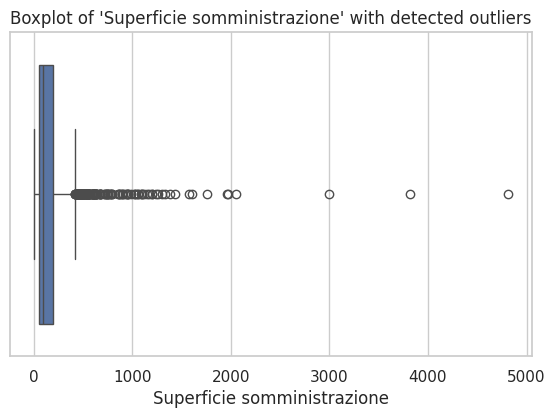

In [ ]:
# ============================================================
# OUTLIER DETECTION FOR "Superficie somministrazione" (IQR)
# ============================================================

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

column = "Superficie somministrazione"

# Work only with non-null values
values = df[column].dropna()

# IQR calculation
Q1 = values.quantile(0.25)
Q3 = values.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Interquartile bounds for '{column}':")
print(f"  Q1 = {Q1:.2f}")
print(f"  Q3 = {Q3:.2f}")
print(f"  IQR = {IQR:.2f}")
print(f"  Lower bound = {lower_bound:.2f}")
print(f"  Upper bound = {upper_bound:.2f}")

# Flag outliers
df["outlier_superficie"] = (df[column] < lower_bound) | (df[column] > upper_bound)

num_outliers = df["outlier_superficie"].sum()
print(f"\nNumber of outliers detected in '{column}': {num_outliers}")

# Show sample outliers
print("\nFirst 10 detected outliers:")
display(df[df["outlier_superficie"]].head(62))

df[df["outlier_superficie"]].head(62).to_csv('/content/drive/MyDrive/boh.csv', index = False)

# Boxplot visualization
plt.figure(figsize=(6, 4))
sns.boxplot(x=df[column])
plt.title(f"Boxplot of '{column}' with detected outliers")
plt.show()

Outlier Treatment Choice

We evaluated three possible strategies for handling outliers in Superficie somministrazione:

1.	Remove outlier rows → simple, but reduces the dataset size.
2.	Cap (winsorize) outlier values → keeps all rows, but forces extreme values to fixed IQR bounds.
3.	Treat outliers as missing values and re-impute them using the Random Forest model → uses all shop characteristics and produces consistent, data-driven estimates.

We select Option 3 because it fits best with our pipeline:

* the number of detected outliers is substantial,
* we maintain a data-driven approach,
* no data is discarded,
* no arbitrary clipping is introduced,
* Random Forest imputation yields realistic and coherent values based on all other shop attributes.

Outliers are therefore marked as missing (NaN) and subsequently re-imputed using the existing Random Forest imputation module.

In [ ]:
# ============================================================
# CONVERT OUTLIERS INTO MISSING VALUES
# ============================================================

df.loc[df["outlier_superficie"], column] = np.nan

print(f"Missing values in '{column}' after outlier removal: {df[column].isnull().sum()}")

Missing values in 'Superficie somministrazione' after outlier removal: 160


In [ ]:
# ============================================================
# RANDOM FOREST IMPUTATION FOR "Superficie somministrazione"
# ============================================================

from sklearn.ensemble import RandomForestRegressor
import pandas as pd
import numpy as np

df_imputed = df.copy()

target = "Superficie somministrazione"

# Cast target as float64 for regression
df_imputed[target] = pd.to_numeric(df_imputed[target], errors="coerce").astype("float64")

# Exclude target + helper flag
excluded = ["outlier_superficie"]
predictors = [c for c in df_imputed.columns if c not in excluded + [target]]

X = pd.get_dummies(df_imputed[predictors], dummy_na=False)
y = df_imputed[target]

# Save masks before imputation
mask_notnull = y.notnull()
mask_null = y.isnull()
mask_was_null = mask_null.copy()

print(f"Training rows (non-null): {mask_notnull.sum()}")
print(f"Rows to impute (null): {mask_null.sum()}")

if mask_null.sum() > 0:
    # Run RandomForest
    model = get_rf_model(is_numeric=True)

    # Fit and predict
    model.fit(X.loc[mask_notnull], y.loc[mask_notnull])

    pred = model.predict(X.loc[mask_null])

    print("Type of raw predictions:", type(pred))

    # Convert to numpy array so assignment is positional, not by index
    if isinstance(pred, pd.Series):
        predictions = pred.to_numpy(dtype="float64")
    else:
        predictions = np.asarray(pred, dtype="float64")

    print("Total predictions:", len(predictions))
    predictions = np.ceil(predictions)

    # Fill missing values positionally
    df_imputed.loc[mask_null, target] = predictions

    print("Random Forest imputation for 'Superficie somministrazione' completed.")
    print(f"Remaining missing values in '{target}': {df_imputed[target].isnull().sum()}")

    imputed_rows = df_imputed.loc[mask_was_null, [target] + predictors]
    print(f"\nNumber of imputed rows: {len(imputed_rows)}")
    display(imputed_rows.head(20))
else:
    print("No missing values to impute for 'Superficie somministrazione'.")

Training rows (non-null): 1820
Rows to impute (null): 160
Type of raw predictions: <class 'numpy.ndarray'>
Total predictions: 160
Random Forest imputation for 'Superficie somministrazione' completed.
Remaining missing values in 'Superficie somministrazione': 0

Number of imputed rows: 160


,Superficie somministrazione,Insegna,Tipo via,Via,Civico,Codice via,Municipio,Accesso,Isolato,Presso,Forma commercio prevalente,Forma commercio secondaria,Forma vendita,Bar caffè,Bar gastronomici e simili,Biliardo,Bocce,Carte,Cibi cotti preconfezionati,Discoteche,Genere merceol.autorizz.sanit.,Giochi legge 388/2000,Mensa,Pizzeria,Prodotti di gastronomia,Ristorante,Spaccio bevande analcoliche,Tavola calda,Tavola fredda,Fast food,Osteria,Self service,Trattoria
11,198.0,Non specificata,PIAZZALE,LOTTO LORENZO,15,6539,8,accesso interno,0,Non specificato,somministrazione,Assente,al banco,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
31,73.0,Non specificata,VIA,CAVEZZALI FRANCESCO,9,2335,2,accesso interno,0,Non specificato,somministrazione,Assente,al banco,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
114,64.0,Non specificata,VIA,NATTA GIULIO,48,6860,8,accesso interno,0,Non specificato,somministrazione,Assente,al banco,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
138,76.0,Non specificata,VIA,RIPAMONTI GIUSEPPE,435,4066,5,accesso interno,0,Non specificato,somministrazione,Assente,al banco,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
155,52.0,Non specificata,VIA,WASHINGTON GIORGIO,97,6111,6,accesso interno,0,Non specificato,somministrazione,Assente,al banco,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
525,220.0,Non specificata,VIA,CASSINIS GIOVANNI BATTISTA,21,4309,4,accesso interno,0,centro helvetia,somministrazione,Assente,self service,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False
531,207.0,Non specificata,VIA,TONALE,11,1213,2,accesso interno,242,telecom italia,somministrazione,Assente,self service,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False
534,176.0,binda spa,VIALE,CERTOSA,2,7174,8,accesso interno,336,binda,somministrazione,Assente,al banco,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False
537,200.0,int.l oreal italia spa.,VIA,PRIMATICCIO FRANCESCO,155,6646,6,accesso interno,35,l'oreal italia,somministrazione,Assente,al banco,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False


In [ ]:
# Use the imputed version as your main dataframe
df = df_imputed.copy()

df.isnull().sum().sort_values(ascending=False)

,0
Insegna,0
Tipo via,0
Via,0
Civico,0
Codice via,0
...,...
Fast food,0
Osteria,0
Self service,0
Trattoria,0


This underlying cell drops the helper column produced before in the outliers analysis

In [ ]:
if "outlier_superficie" in df.columns:
    df.drop(columns=["outlier_superficie"], inplace=True)


In [ ]:
df.isnull().sum().sort_values(ascending=False)

,0
Insegna,0
Tipo via,0
Via,0
Civico,0
Codice via,0
...,...
Tavola fredda,0
Fast food,0
Osteria,0
Self service,0


In [ ]:
print("Final distribution of 'Superficie somministrazione':")
display(df["Superficie somministrazione"].describe())

Final distribution of 'Superficie somministrazione':


,Superficie somministrazione
count,1980.000000
mean,121.480303
std,88.587941
min,2.000000
25%,52.000000
50%,100.000000
75%,170.000000
max,417.000000


# Duplicate Detection

In our deduplication process, we intentionally adopted a precision-first strategy, aiming to minimize false positives (i.e., mistakenly merging distinct entities).

In particular, we applied the rule:

“Different addresses ⇒ different entities”
even when names or other attributes appear very similar.

This choice ensures stronger protection against incorrect merges, but it naturally reduces recall: some true duplicates may remain unmerged.
Typical scenarios include:

* Businesses located on a corner and registered with two different street names.
* Addresses where the street number changed slightly over time (e.g., 12 → 14).
* Complex buildings where the same business appears with multiple sub-addresses or unit descriptors.

We judged that maintaining high precision was the safer approach, preventing accidental fusion of distinct entities and preserving dataset reliability.

In [ ]:
import numpy as np
import pandas as pd
import recordlinkage
from recordlinkage import Index
from difflib import SequenceMatcher

# ============================================================
# CONFIGURATION (THRESHOLDS AND RULES)
# ============================================================

# Address similarity thresholds
ADDR_STRICT_SIM = 0.90        # "almost equal" Via_clean
ADDR_MIN_SIM_FOR_NAME_CASE = 0.50  # below this, addresses considered "different"

# House number rules
CIVICO_MAX_DIFF_SAME_SIDE = 2  # allowed distance on same parity (e.g. 12 vs 14)
# (parity rule: odd vs even = opposite sides of street)

# Name similarity thresholds (Jaro-Winkler)
JARO_NAME_THRESHOLD = 0.85     # base threshold for considering names "similar"
JARO_VIA_THRESHOLD = 0.85      # base threshold for street name similarity

# Very strong name similarity (for risky cases like slightly different address)
NAME_VERY_SIMILAR = 0.95

# Dynamic scoring thresholds
THRESHOLD_NAME_MISSING = 0.95  # stricter when we rely only on address
THRESHOLD_NAME_PRESENT = 0.85  # standard when name is present

# ============================================================
# DATA CLEANING
# ============================================================

df = df.drop_duplicates().reset_index(drop=True)

# Normalized name
df["Insegna_clean"] = (
    df["Insegna"]
    .fillna("")
    .astype(str)
    .str.strip()
    .str.lower()
)

missing_values = ["non specificata", "nan", ""]
df["name_missing"] = df["Insegna_clean"].isin(missing_values)

# Normalized address
df["Via_clean"] = (
    df["Via"]
    .fillna("")
    .astype(str)
    .str.lower()
    .str.replace(r"\bvia\b|\bviale\b|\bpiazza\b|\bp\.za\b", "", regex=True)
    .str.replace(r"[^a-z0-9 ]", "", regex=True)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

# Numeric house number and parity
def extract_civico_num(x):
    digits = "".join(filter(str.isdigit, str(x)))
    return int(digits) if digits else np.nan

df["Civico_num"] = df["Civico"].apply(extract_civico_num)
df["Civico_parity"] = df["Civico_num"] % 2

# Initial of Insegna for blocking
df["Insegna_initial"] = df["Insegna_clean"].str[:1]

# ============================================================
# INDEXING STRATEGY (CANDIDATE PAIRS)
# ============================================================

print("=" * 60)
print("BUILDING CANDIDATE PAIRS")
print("=" * 60)

# Strategy 1: Sorted Neighborhood on Via_clean
indexer_sn = Index()
indexer_sn.sortedneighbourhood(on="Via_clean", window=9)
pairs_sn = indexer_sn.index(df)
print(f"✓ Sorted Neighborhood pairs (address-based): {len(pairs_sn)}")

# Strategy 2: Blocking on Insegna_initial + Municipio
indexer_init = Index()
indexer_init.block(["Insegna_initial", "Municipio"])
pairs_init = indexer_init.index(df)
print(f"✓ Name blocking pairs (name+municipio): {len(pairs_init)}")

# Combine pairs from both strategies into a set for efficient membership tests
pairs_sn_set = set(pairs_sn)
pairs_init_set = set(pairs_init)
all_pairs = pairs_sn_set | pairs_init_set

# ============================================================
# FILTER CANDIDATE PAIRS (NAME/ADDRESS LOGIC)
# ============================================================

candidate_pairs_list = []

for (i, j) in all_pairs:
    name_missing_i = df.loc[i, "name_missing"]
    name_missing_j = df.loc[j, "name_missing"]

    # Case 1: BOTH names missing → only address-based
    if name_missing_i and name_missing_j:
        # Only keep if they came from the address-based indexing
        if (i, j) in pairs_sn_set or (j, i) in pairs_sn_set:
            candidate_pairs_list.append((i, j))
        continue

    # Case 2: At least one has a name → keep (evaluated later with similarity)
    candidate_pairs_list.append((i, j))

candidate_pairs = pd.MultiIndex.from_tuples(candidate_pairs_list)
print(f"✓ Final candidate pairs after name-based filtering: {len(candidate_pairs)}\n")

# ============================================================
# STRICT ADDRESS PRE-FILTERING (PARITY + DISTANCE)
# ============================================================

print("Applying strict address + civico filtering...")

filtered_pairs = []
rejected_count = 0

for (i, j) in candidate_pairs:
    via_i = df.loc[i, "Via_clean"]
    via_j = df.loc[j, "Via_clean"]
    name_missing_i = df.loc[i, "name_missing"]
    name_missing_j = df.loc[j, "name_missing"]

    civico_i = df.loc[i, "Civico_num"]
    civico_j = df.loc[j, "Civico_num"]
    parity_i = df.loc[i, "Civico_parity"]
    parity_j = df.loc[j, "Civico_parity"]

    # If BOTH records have valid names, be strict with address
    if not name_missing_i and not name_missing_j:

        # Street names must be equal or highly similar
        if via_i != via_j:
            # For sufficiently long street names, allow minor typos
            if len(via_i) > 3 and len(via_j) > 3:
                similarity = SequenceMatcher(None, via_i, via_j).ratio()
                if similarity < ADDR_STRICT_SIM:
                    rejected_count += 1
                    continue
            else:
                # Short names → require exact match
                rejected_count += 1
                continue

        # If we reach here, Via_clean is acceptable.
        # Now check house number parity and distance if both available.
        if pd.notna(civico_i) and pd.notna(civico_j):
            # Rule 1: Different parity → different side of street
            if parity_i != parity_j:
                rejected_count += 1
                continue

            # Rule 2: Same parity but too far apart
            if abs(civico_i - civico_j) > CIVICO_MAX_DIFF_SAME_SIDE:
                rejected_count += 1
                continue

    # If we get here, the pair passes pre-filtering
    filtered_pairs.append((i, j))

candidate_pairs = pd.MultiIndex.from_tuples(filtered_pairs)
print(f"✓ Rejected {rejected_count} pairs for address/civico mismatch")
print(f"✓ Remaining candidate pairs: {len(candidate_pairs)}\n")

# ============================================================
# COMPARISON FEATURES (RECORDLINKAGE)
# ============================================================

compare = recordlinkage.Compare()

compare.exact("Via_clean", "Via_clean", label="eq_via_clean")

compare.string(
    "Insegna", "Insegna",
    method="jarowinkler",
    threshold=JARO_NAME_THRESHOLD,
    label="sim_insegna"
)

compare.string(
    "Via", "Via",
    method="jarowinkler",
    threshold=JARO_VIA_THRESHOLD,
    label="sim_via"
)

compare.exact("Civico", "Civico", label="eq_civico")
compare.exact("Municipio", "Municipio", label="eq_municipio")

features = compare.compute(candidate_pairs, df)

# Add flags using aligned indices
left_idx = features.index.get_level_values(0)
right_idx = features.index.get_level_values(1)

features["name_missing_pair"] = (
    df.loc[left_idx, "name_missing"].values |
    df.loc[right_idx, "name_missing"].values
)

# ============================================================
# SCORING FUNCTION (CONDITIONAL)
# ============================================================

def conditional_score(row):
    """
    Scoring function with strict address requirements.
    Key principle: different addresses = different entities, even with same name.
    """

    # CASE 1: at least one name missing → rely heavily on address
    if row["name_missing_pair"]:
        if row["eq_via_clean"] == 0 or row["eq_civico"] == 0:
            return 0.0

        return (
            0.70 * row["eq_via_clean"] +
            0.20 * row["eq_civico"] +
            0.10 * row["eq_municipio"]
        )

    # CASE 2: both have names
    # If addresses are very different, reject
    if row["sim_via"] < ADDR_MIN_SIM_FOR_NAME_CASE:
        return 0.0

    # Addresses somewhat similar but civico differs
    if row["sim_via"] >= ADDR_MIN_SIM_FOR_NAME_CASE and row["eq_civico"] == 0:
        # Only allow if name is extremely similar → likely same place
        if row["sim_insegna"] < NAME_VERY_SIMILAR:
            return 0.0

    # Standard weighted scoring
    return (
        0.35 * row["sim_insegna"] +
        0.35 * row["sim_via"] +
        0.15 * row["eq_civico"] +
        0.15 * row["eq_municipio"]
    )

features["score"] = features.apply(conditional_score, axis=1)

# Dynamic threshold:
features["dynamic_threshold"] = features["name_missing_pair"].map(
    lambda x: THRESHOLD_NAME_MISSING if x else THRESHOLD_NAME_PRESENT
)

duplicate_pairs = features[features["score"] >= features["dynamic_threshold"]]

# ============================================================
# DIAGNOSTICS
# ============================================================

print("=" * 60)
print("DUPLICATE DETECTION RESULTS")
print("=" * 60)
print(f"Candidate pairs evaluated: {len(features)}")
print(f"Duplicate pairs found: {len(duplicate_pairs)}")
print(f"Average similarity score: {features['score'].mean():.3f}")
print("Score distribution:")
print(f"  - High (>0.9): {(features['score'] > 0.9).sum()}")
print(f"  - Medium (0.7–0.9): {(((features['score'] >= 0.7) & (features['score'] <= 0.9))).sum()}")
print(f"  - Low (<0.7): {(features['score'] < 0.7).sum()}")
print("=" * 60)

# ============================================================
# VERIFICATION: CROSS-ADDRESS MERGES
# ============================================================

print("\n" + "=" * 60)
print("VERIFICATION: Checking for potential false positives")
print("=" * 60)

cross_address_merges = []

for (i, j) in duplicate_pairs.index:
    via_i = df.loc[i, "Via_clean"]
    via_j = df.loc[j, "Via_clean"]
    sim_via = features.loc[(i, j), "sim_via"]

    if via_i != via_j and sim_via < 0.85:
        cross_address_merges.append({
            "idx_1": i,
            "idx_2": j,
            "Insegna_1": df.loc[i, "Insegna"],
            "Insegna_2": df.loc[j, "Insegna"],
            "Via_1": df.loc[i, "Via"],
            "Via_2": df.loc[j, "Via"],
            "Civico_1": df.loc[i, "Civico"],
            "Civico_2": df.loc[j, "Civico"],
            "score": features.loc[(i, j), "score"]
        })

if cross_address_merges:
    print(f"WARNING: Found {len(cross_address_merges)} potential cross-address merges.")
    print("Examples:\n")
    for merge in cross_address_merges[:5]:
        print(f"  '{merge['Insegna_1']}' at {merge['Via_1']} {merge['Civico_1']}")
        print(f"  '{merge['Insegna_2']}' at {merge['Via_2']} {merge['Civico_2']}")
        print(f"  Score: {merge['score']:.3f}\n")
else:
    print("✓ No suspicious cross-address merges detected.\n")

print("=" * 60)

# Convert duplicate pairs index to a DataFrame for data fusion
pairs_df = duplicate_pairs.index.to_frame(index=False)

BUILDING CANDIDATE PAIRS
✓ Sorted Neighborhood pairs (address-based): 17394
✓ Name blocking pairs (name+municipio): 113420
✓ Final candidate pairs after name-based filtering: 21496

Applying strict address + civico filtering...
✓ Rejected 4263 pairs for address/civico mismatch
✓ Remaining candidate pairs: 17233

DUPLICATE DETECTION RESULTS
Candidate pairs evaluated: 17233
Duplicate pairs found: 485
Average similarity score: 0.031
Score distribution:
  - High (>0.9): 485
  - Medium (0.7–0.9): 4
  - Low (<0.7): 16744

VERIFICATION: Checking for potential false positives
✓ No suspicious cross-address merges detected.



In [ ]:
print(f"Sorted Neighborhood pairs: {len(pairs_sn)}")
print(f"Blocking pairs: {len(pairs_init)}")
print(f"Final candidate pairs: {len(candidate_pairs)}")
print(f"Pairs meeting threshold: {len(duplicate_pairs)}")

Sorted Neighborhood pairs: 17394
Blocking pairs: 113420
Final candidate pairs: 17233
Pairs meeting threshold: 485


In [ ]:
'''pairs_df = duplicate_pairs.index.to_frame(index=False)

for idx, row in pairs_df.iterrows():
    i, j = row[0], row[1]
    print(f"\n POSSIBLE DUPLICATE PAIR: {i}  vs  {j}")
    print("-----------------------------------------------------")
    display(df.loc[[i, j]])
'''

'pairs_df = duplicate_pairs.index.to_frame(index=False)\n\nfor idx, row in pairs_df.iterrows():\n    i, j = row[0], row[1]\n    print(f"\n POSSIBLE DUPLICATE PAIR: {i}  vs  {j}")\n    print("-----------------------------------------------------")\n    display(df.loc[[i, j]])\n'

In [ ]:
original_cols = df.columns.tolist()

## Data Fusion

In [ ]:
import numpy as np
import pandas as pd
import networkx as nx
from collections import Counter

# ============================================================
# DATA FUSION (DUPLICATE CLUSTERS -> SINGLE ENTITIES)
# Assumes:
#   - df: original dataframe
#   - duplicate_pairs: recordlinkage result (index = pairs (i, j))
# ============================================================

# ----------------------------------------------------------------
# CONFIG
# ----------------------------------------------------------------
DEBUG_DISAGREEMENTS = False  # set to True only if you want verbose debug output


# ----------------------------------------------------------------
# UTILITY FUNCTIONS
# ----------------------------------------------------------------

def normalize_str(x):
    """Safe lowercase + strip for comparison."""
    if pd.isna(x):
        return ""
    return str(x).strip().lower()


def get_best_name(series):
    """
    Selects the most informative name.
    Ignores 'Non specificata', 'nan', '', None (case-insensitive).
    Picks the longest informative string.
    """
    invalid = {"non specificata", "nan", ""}

    valid = [
        s for s in series
        if pd.notna(s) and normalize_str(s) not in invalid
    ]

    if not valid:
        return "Non specificata"

    # Longest non-invalid string = most informative
    return max(valid, key=lambda x: len(str(x)))


def get_mode_with_warning(series: pd.Series,
                          col_name: str,
                          warn_threshold: float = 0.7):
    """
    Returns the mode (most frequent) value.
    If disagreement is high (mode frequency < warn_threshold),
    prints a warning and optionally records details for debugging.
    """
    clean = series.dropna()
    if clean.empty:
        return None

    value_counts = clean.value_counts()
    mode_value = value_counts.index[0]

    # Disagreement: mode not very dominant
    if len(value_counts) > 1:
        consensus_ratio = value_counts.iloc[0] / len(clean)
        if consensus_ratio < warn_threshold:
            print(f"High disagreement in '{col_name}': {dict(value_counts.head(3))}")
            print(f"Consensus: {consensus_ratio:.1%} | Selected: '{mode_value}'")

            # Optional debug tracking
            if DEBUG_DISAGREEMENTS:
                if not hasattr(get_mode_with_warning, "disagreement_groups"):
                    get_mode_with_warning.disagreement_groups = []
                get_mode_with_warning.disagreement_groups.append({
                    "col": col_name,
                    "indices": series.index.tolist(),
                    "values": value_counts.to_dict()
                })

    return mode_value


def get_first_valid(series):
    """Robust version of 'first': returns the first non-null value."""
    clean = series.dropna()
    return clean.iloc[0] if not clean.empty else None


def calculate_consensus_score(group: pd.DataFrame,
                              key_fields=('Via', 'Civico', 'Municipio')):
    """
    Calculate a consensus quality score (0-1) for a group of duplicates.
    Higher score = more agreement on key fields.
    """
    scores = []
    for col in key_fields:
        if col in group.columns:
            clean = group[col].dropna()
            if len(clean) > 1:
                consensus = clean.value_counts().iloc[0] / len(clean)
                scores.append(consensus)
            elif len(clean) == 1:
                scores.append(1.0)
    return sum(scores) / len(scores) if scores else 1.0


# ============================================================
# CLUSTERING DUPLICATES VIA CONNECTED COMPONENTS
# ============================================================

print("=" * 60)
print("STARTING DATA FUSION PROCESS")
print("=" * 60)

print(f"Original dataset size: {len(df)} records")

# Build an undirected graph: nodes = row indices, edges = duplicate pairs
G = nx.Graph()
G.add_nodes_from(df.index)

# duplicate_pairs can be:
#   - a DataFrame with a MultiIndex index,
#   - or already the MultiIndex of (i, j)
if isinstance(duplicate_pairs, pd.DataFrame):
    edges = duplicate_pairs.index.to_list()
else:
    edges = list(duplicate_pairs.index) if hasattr(duplicate_pairs, "index") else list(duplicate_pairs)

G.add_edges_from(edges)

print(f"Duplicate pairs (edges): {len(edges)}\n")

# Map each row index to a group_id (connected component id)
group_mapper = {}
for comp_id, component in enumerate(nx.connected_components(G)):
    for idx in component:
        group_mapper[idx] = comp_id

df = df.copy()
df["group_id"] = df.index.map(group_mapper)

unique_entities = df["group_id"].nunique()
print(f"✓ Identified unique real-world entities (groups): {unique_entities}")
print(f"✓ Expected reduction: {len(df) - unique_entities} records will be merged\n")


# ============================================================
# PRE-MERGE VALIDATION
# ============================================================

print("-" * 60)
print("PRE-MERGE VALIDATION")
print("-" * 60)

# Groups spanning multiple municipalities might indicate false positives
conflicting_municipio = df.groupby("group_id")["Municipio"].nunique()
if (conflicting_municipio > 1).any():
    n_conflicts = (conflicting_municipio > 1).sum()
    print(f"WARNING: {n_conflicts} groups span multiple municipalities!")
    print("This may indicate false positives in duplicate detection.\n")
else:
    print("✓ All groups are within single municipalities\n")

# Distribution of group sizes
merge_sizes = df["group_id"].value_counts()
print("Merge group sizes:")
print(f"  - Singles (no duplicates): {(merge_sizes == 1).sum()}")
print(f"  - Pairs (2 records):       {(merge_sizes == 2).sum()}")
print(f"  - Triplets (3 records):    {(merge_sizes == 3).sum()}")
print(f"  - Larger (4+ records):     {(merge_sizes >= 4).sum()}")
print(f"  - Mean group size:         {merge_sizes.mean():.2f}")
print(f"  - Median group size:       {merge_sizes.median():.0f}")
if merge_sizes.max() > 5:
    print(f"  - Largest group size:      {merge_sizes.max()} records")
print()


# ============================================================
# PROVENANCE TRACKING
# ============================================================

df["original_id"] = df.index
df["original_row_position"] = range(len(df))


# ============================================================
# DEFINE AGGREGATION RULES
# ============================================================

if DEBUG_DISAGREEMENTS:
    get_mode_with_warning.disagreement_groups = []

# Custom aggregation logic
agg_rules = {
    # Priority / informative fields
    "Insegna": get_best_name,
    # Use median to be robust against outliers / noisy surface values
    "Superficie somministrazione": "median",

    # Consensus-based fields (with warnings)
    "Via": lambda x: get_mode_with_warning(x, "Via"),
    "Civico": lambda x: get_mode_with_warning(x, "Civico"),

    # Stable reference fields
    "Municipio": get_first_valid,

    # Provenance tracking
    "original_id": lambda x: list(x),
    "original_row_position": lambda x: list(x),
}

# Helper columns that we do not want in the fused dataset via automatic agg
helper_cols = [
    "group_id",
    "name_missing",
    "Via_clean",
    "Insegna_clean",
    "Insegna_initial",
    "Civico_num",
    "Civico_parity",
]

# Fallback rule: first valid value for all remaining columns
for col in df.columns:
    if col not in agg_rules and col not in helper_cols:
        agg_rules[col] = get_first_valid


# ============================================================
# CALCULATE CONSENSUS QUALITY PER GROUP
# ============================================================

print("-" * 60)
print("CALCULATING CONSENSUS QUALITY SCORES")
print("-" * 60)

quality_scores = (
    df.groupby("group_id")
      .apply(calculate_consensus_score)
      .rename("consensus_quality")
      .reset_index()
)

print("Quality score distribution:")
print(f"  - High quality   (>0.9):  {(quality_scores['consensus_quality'] > 0.9).sum()}")
print(f"  - Medium quality (0.7–0.9): {((quality_scores['consensus_quality'] >= 0.7) & (quality_scores['consensus_quality'] <= 0.9)).sum()}")
print(f"  - Low quality    (<0.7):  {(quality_scores['consensus_quality'] < 0.7).sum()}")
print()


# ============================================================
# EXECUTE DATA FUSION
# ============================================================

print("-" * 60)
print("EXECUTING DATA FUSION")
print("-" * 60)

# Keep group_id so we can merge quality_scores by key
df_dedup = df.groupby("group_id").agg(agg_rules).reset_index()

# Attach consensus quality
df_dedup = df_dedup.merge(quality_scores, on="group_id", how="left")

# Compute how many original records were merged into each fused record
df_dedup["merge_count"] = df_dedup["original_id"].apply(len)
df_dedup["was_merged"] = df_dedup["merge_count"] > 1

# Drop helper columns not needed downstream
df_dedup = df_dedup.drop(columns=["Civico_num", "Civico_parity"], errors="ignore")

print("✓ Merge completed successfully\n")

# Identify low-quality merged groups (for possible manual review)
low_quality_merges = df_dedup[
    (df_dedup["was_merged"]) &
    (df_dedup["consensus_quality"] < 0.7)
]

if len(low_quality_merges) > 0:
    print(f"{len(low_quality_merges)} merged records have low consensus quality (<0.7).")
    print("   Consider manual review of these records.\n")
else:
    print("All merged records have acceptable consensus quality (≥ 0.7).\n")


# ============================================================
# FINAL REPORT
# ============================================================

print("=" * 60)
print("DATA FUSION COMPLETE")
print("=" * 60)
print(f"Original records:    {len(df)}")
print(f"Final records:       {len(df_dedup)}")
print(f"Records eliminated:  {len(df) - len(df_dedup)}")
print(f"Reduction rate:      {((len(df) - len(df_dedup)) / len(df) * 100):.1f}%\n")

print("Quality metrics:")
print(f"  - Mean consensus score: {df_dedup['consensus_quality'].mean():.3f}")
print(f"  - Records merged:        {df_dedup['was_merged'].sum()}")
print(f"  - Records unchanged:     {(~df_dedup['was_merged']).sum()}")
print("=" * 60)

if DEBUG_DISAGREEMENTS and hasattr(get_mode_with_warning, "disagreement_groups"):
    groups = get_mode_with_warning.disagreement_groups
    if groups:
        print("\n" + "=" * 60)
        print("DETAILED INSPECTION OF HIGH DISAGREEMENT GROUPS")
        print("=" * 60)
        for i, info in enumerate(groups):
            print(f"\nDisagreement #{i+1} – Column: '{info['col']}'")
            print(f"   Values found: {info['values']}")
            print("   Records involved:")
            for idx in info["indices"]:
                row = df.loc[idx]
                print(
                    f"     • Row {idx}: "
                    f"Insegna='{row.get('Insegna', '')}' | "
                    f"Via='{row.get('Via', '')}' | "
                    f"Civico='{row.get('Civico', '')}' | "
                    f"Municipio='{row.get('Municipio', 'N/A')}'"
                )
        print("=" * 60)

# Sample of deduplicated data
print("\nSample of deduplicated data:")
cols_preview = [
    "Insegna", "Via", "Civico", "Municipio",
    "merge_count", "consensus_quality", "was_merged"
]
cols_preview = [c for c in cols_preview if c in df_dedup.columns]
print(df_dedup[cols_preview].head(10))

STARTING DATA FUSION PROCESS
Original dataset size: 1942 records
Duplicate pairs (edges): 485

✓ Identified unique real-world entities (groups): 1635
✓ Expected reduction: 307 records will be merged

------------------------------------------------------------
PRE-MERGE VALIDATION
------------------------------------------------------------
✓ All groups are within single municipalities

Merge group sizes:
  - Singles (no duplicates): 1410
  - Pairs (2 records):       179
  - Triplets (3 records):    33
  - Larger (4+ records):     13
  - Mean group size:         1.19
  - Median group size:       1
  - Largest group size:      12 records

------------------------------------------------------------
CALCULATING CONSENSUS QUALITY SCORES
------------------------------------------------------------
Quality score distribution:
  - High quality   (>0.9):  1635
  - Medium quality (0.7–0.9): 0
  - Low quality    (<0.7):  0

------------------------------------------------------------
EXECUTING 

In [ ]:
df_dedup["Superficie somministrazione"] = (
    np.ceil(df_dedup["Superficie somministrazione"].astype(float))
)

In [ ]:
# Columns from the original schema that still exist in df_dedup
base_cols = [c for c in original_cols if c in df_dedup.columns]

# New columns created during processing (provenance, quality, etc.)
extra_cols = [c for c in df_dedup.columns if c not in base_cols]

# Reorder
df_dedup = df_dedup[base_cols].copy()

In [ ]:
df = df_dedup.copy()

# Data quality assessment (after cleaning)

TO ADD: PINE

# Final Semantic Anomaly Flagging

A rule-based validation framework to detect semantically inconsistent or implausible attribute combinations without altering original data values.

In this section, we introduce a systematic mechanism for identifying records whose attributes violate basic semantic or domain-specific expectations.
After assigning each row to a high-level context type (e.g., hospital, school, horeca, public office, company, other), we evaluate the logical coherence between the inferred context and the binary service indicators present in the dataset.

Many raw datasets contain combinations that are technically valid on a syntactic level (e.g., booleans or strings correctly formatted) but semantically impossible in the real world.

Examples include:

*	A hospital offering fast food or tavola calda services
* A public office marked as pizzeria
* A school tagged with discoteca
* A company office classified simultaneously as Tavola Fredda and Mensa
* Any entity whose attributes contradict the nature of its inferred category

Rather than forcibly modifying or correcting these inconsistent values — an approach that would introduce bias, assumptions, and irreversible data manipulation — we adopt a non-destructive validation strategy.

A new boolean column, IsAnomaly, is added to the dataset:

* initialized to False for all rows,
* set to True whenever a row matches one or more forbidden attribute combinations for its context.

This ensures that:

* the original raw values remain intact,
* suspect records are clearly identifiable,
* downstream analyses can choose whether to include or exclude anomalies,

Crucially, this anomaly-flagging layer improves the quality of the predictive modeling pipeline.
By identifying semantically incoherent rows, we can later restrict the training process to only those observations that exhibit realistic and logically meaningful attribute combinations.
This leads to models that learn genuine behavioral patterns rather than artifacts caused by noisy, inconsistent, or mislabeled records improving both predictive performance and interpretability.


In [ ]:
import re
import pandas as pd

def detect_context(row):
    """Assigns a coarse context type based on text patterns."""
    text = ""
    for col in ["Insegna", "Presso"]:
        if col in row and pd.notna(row[col]):
            text += " " + str(row[col]).lower()

    if not text.strip():
        return "unknown"

    if re.search(r"ospedale|osp\.|istituto.*tumori|clinica|asl|policlinico|casa di cura", text):
        return "hospital"

    if re.search(r"scuola|istituto tecnico|liceo|universit|politecnico", text):
        return "school"

    if re.search(r"comune|municipio|agenzia delle entrate|regione|ministero|prefettura", text):
        return "public_office"

    if re.search(r"azienda|s\.p\.a\.|srl|uffici|stabilimento|fabbrica|industria", text):
        return "company"

    if re.search(r"bar|ristorante|caffe|pizzeria|trattoria|osteria", text):
        return "horeca"

    return "other"


df["context_type"] = df.apply(detect_context, axis=1)
print("Context types:", df["context_type"].value_counts())

Context types: context_type
other            1329
horeca            121
company            78
school             66
hospital           28
public_office      13
Name: count, dtype: int64


In [ ]:
# ============================================================
# Initialize anomaly column
# ============================================================

df["IsAnomaly"] = False


# ============================================================
# Define forbidden combinations based on context_type
# ============================================================

category_cols = [
    "Mensa", "Tavola calda", "Tavola fredda", "Self service",
    "Fast food", "Pizzeria", "Ristorante", "Bar caffè", "Bar gastronomici e simili",
    "Biliardo", "Bocce", "Carte", "Discoteche", "Genere merceol.autorizz.sanit.",
    "Giochi legge 388/2000", "Prodotti di gastronomia", "Spaccio bevande analcoliche",
    "Osteria", "Trattoria"
]

forbidden_rules = {
    "hospital": ["Fast food", "Pizzeria", "Ristorante", "Discoteche", "Bar gastronomici e simili",
                 "Biliardo", "Bocce", "Prodotti di gastronomia", "Osteria", "Trattoria"
                 ],
    "school": ["Fast food", "Bar gastronomici e simili", "Discoteche", "Giochi legge 388/2000",
               "Prodotti di gastronomia", "Osteria", "Trattoria"],
    "public_office": [],
    "company": [],
    "horeca": [],
    "other": [],
    "unknown": []
}

# ============================================================
# Apply anomaly rules
# ============================================================

for idx, row in df.iterrows():
    ctx = row["context_type"]

    for forbidden_col in forbidden_rules.get(ctx, []):
        if forbidden_col in df.columns:
            if bool(row[forbidden_col]) is True:
                df.at[idx, "IsAnomaly"] = True
                break

# Data Analisys (DA)

### Helper Functions

In [ ]:
# ================================
# HELPER FUNCTION
# ================================

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as ss

def customHeatMap(dataset):

    # ================================
    # Cramér's V
    # ================================
    def cramers_v(x, y):
        confusion_matrix = pd.crosstab(x, y)
        chi2 = ss.chi2_contingency(confusion_matrix)[0]
        n = confusion_matrix.sum().sum()
        r, k = confusion_matrix.shape
        return np.sqrt(chi2 / (n * (min(r, k) - 1)))

    # ================================
    # SELECT CATEGORICAL COLUMNS
    # ================================
    excluded_cols = ["context_type", "IsAnomaly"]

    df_cat = dataset.select_dtypes(include=["object", "category", "bool"]).copy()
    df_cat = df_cat.drop(columns=[c for c in excluded_cols if c in df_cat.columns])

    print(f"Categorical columns used: {list(df_cat.columns)}")

    # ================================
    # COMPUTE CRAMÉR'S V MATRIX
    # ================================
    cols = df_cat.columns
    cramers_matrix = pd.DataFrame(np.zeros((len(cols), len(cols))),
                                  index=cols, columns=cols)

    for col1 in cols:
        for col2 in cols:
            cramers_matrix.loc[col1, col2] = cramers_v(df_cat[col1], df_cat[col2])

    # ================================
    # HEATMAP
    # ================================
    plt.figure(figsize=(8, 8))
    sns.heatmap(cramers_matrix, annot=False, cmap="coolwarm", vmin=0, vmax=1)
    plt.title("Categorical Correlation Heatmap (Cramér's V)", fontsize=18)
    plt.tight_layout()
    plt.show()

In [ ]:
def KNN(dataset, targetColumn, isClassification, random_state = 42):
    """
    Run a KNN experiment (classification or regression) on the given dataset.

    - Uses pandas.get_dummies for categorical encoding
    - Standardizes features with StandardScaler
    - Drops rows with missing target
    """

    # Work on a copy
    data = dataset.copy()

    # Drop rows with missing target
    data = data[data[targetColumn].notna()].copy()
    print(f"Rows with non-null target [{targetColumn}]: {data.shape[0]}")

    # Define feature columns
    feature_cols = list(data.columns)
    feature_cols.remove(targetColumn)

    for col in ["IsAnomaly", "context_type"]:
        if col in feature_cols:
            feature_cols.remove(col)

    X = data[feature_cols].copy()
    y = data[targetColumn].copy()

    # Separate numeric / categorical
    num_cols_X = X.select_dtypes(include=np.number).columns.tolist()
    cat_cols_X = [c for c in X.columns if c not in num_cols_X]

    # Handle missing values in X
    if num_cols_X:
        X[num_cols_X] = X[num_cols_X].fillna(X[num_cols_X].mean())
    if cat_cols_X:
        for col in cat_cols_X:
            # Se è una Categorical, aggiungo esplicitamente la categoria "missing"
            if pd.api.types.is_categorical_dtype(X[col]):
                if "missing" not in X[col].cat.categories:
                    X[col] = X[col].cat.add_categories("missing")
            # Poi riempio i NaN con "missing"
            X[col] = X[col].fillna("missing")

    # One-hot encode categoricals
    X_encoded = pd.get_dummies(X, columns=cat_cols_X, dummy_na=False)
    print(f"Encoded feature space shape: {X_encoded.shape}")

    # Train-test split
    if isClassification:
        X_train, X_test, y_train, y_test = train_test_split(
            X_encoded,
            y,
            test_size=0.2,
            random_state=random_state,
            stratify=y
        )
    else:
        X_train, X_test, y_train, y_test = train_test_split(
            X_encoded,
            y,
            test_size=0.2,
            random_state=random_state
        )

    # Standardize (fit only on train to avoid leakage)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Classification or Regression
    if isClassification:
        y_train = y_train.astype("category")

        clf = KNeighborsClassifier(n_neighbors=5)
        print("Training KNN classifier...")
        clf.fit(X_train_scaled, y_train)

        y_pred = clf.predict(X_test_scaled)

        print(f"\nEstimator performance for target '{targetColumn}':\n")
        print("Confusion matrix:")
        print(confusion_matrix(y_test, y_pred))
        print("\nClassification report:")
        print(classification_report(y_test, y_pred))

    else:
        # Regression
        y_train = pd.to_numeric(y_train, errors="coerce")
        y_test = pd.to_numeric(y_test, errors="coerce")

        reg = KNeighborsRegressor(n_neighbors=5)
        print("Training KNN regressor...")
        reg.fit(X_train_scaled, y_train)

        # Cross-validation on train set
        cv = ShuffleSplit(n_splits=8, test_size=0.3, random_state=random_state)
        scores = cross_val_score(reg, X_train_scaled, y_train,
                                 cv=cv, scoring="neg_root_mean_squared_error")
        rmse = abs(scores.mean())
        print(f"Cross-validated RMSE on train: {rmse:.4f}")

## DA: original dataset

Categorical columns used: ['Settore storico pe', 'Tipo via', 'Forma commercio', 'Forma commercio prev', 'Forma vendita']


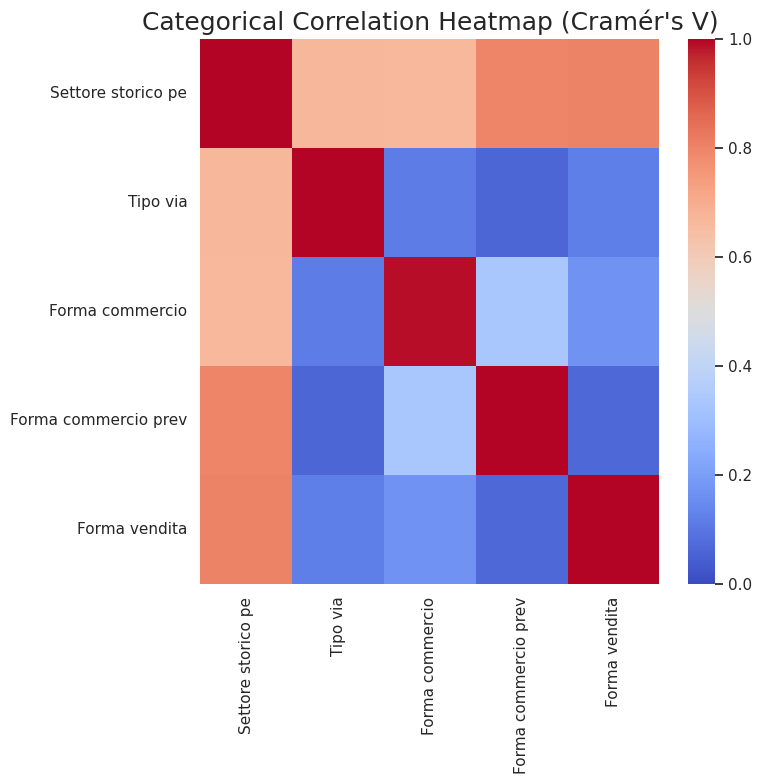

In [ ]:
df_original = pd.read_csv('/content/drive/MyDrive/Comune-di-Milano-Pubblici-esercizi-fuori-piano.csv', sep=';',encoding='utf-16')

# Drop columns that contains almost unique values
df_original = df_original.drop(columns=["Insegna", "Via", "Ubicazione", "Civico", "Codice via"])
customHeatMap(df_original)

In [ ]:
KNN(df_original, targetColumn = "Forma vendita", isClassification = True)
KNN(df_original, targetColumn = "Superficie somministrazione", isClassification = False)

Rows with non-null target [Forma vendita]: 1040
Encoded feature space shape: (1040, 402)
Training KNN classifier...

Estimator performance for target 'Forma vendita':

Confusion matrix:
[[48  0  0 50]
 [ 1  1  0  5]
 [ 7  0  0 22]
 [ 5  1  0 68]]

Classification report:
              precision    recall  f1-score   support

    al banco       0.79      0.49      0.60        98
   al tavolo       0.50      0.14      0.22         7
       misto       0.00      0.00      0.00        29
self service       0.47      0.92      0.62        74

    accuracy                           0.56       208
   macro avg       0.44      0.39      0.36       208
weighted avg       0.55      0.56      0.51       208

Rows with non-null target [Superficie somministrazione]: 1701
Encoded feature space shape: (1701, 483)
Training KNN regressor...
Cross-validated RMSE on train: 300.2847


## DA: cleaned data (overall)

Categorical columns used: ['Isolato', 'Forma commercio prevalente', 'Forma commercio secondaria', 'Forma vendita', 'Bar caffè', 'Bar gastronomici e simili', 'Biliardo', 'Bocce', 'Carte', 'Cibi cotti preconfezionati', 'Discoteche', 'Genere merceol.autorizz.sanit.', 'Giochi legge 388/2000', 'Mensa', 'Pizzeria', 'Prodotti di gastronomia', 'Ristorante', 'Spaccio bevande analcoliche', 'Tavola calda', 'Tavola fredda', 'Fast food', 'Osteria', 'Self service', 'Trattoria']


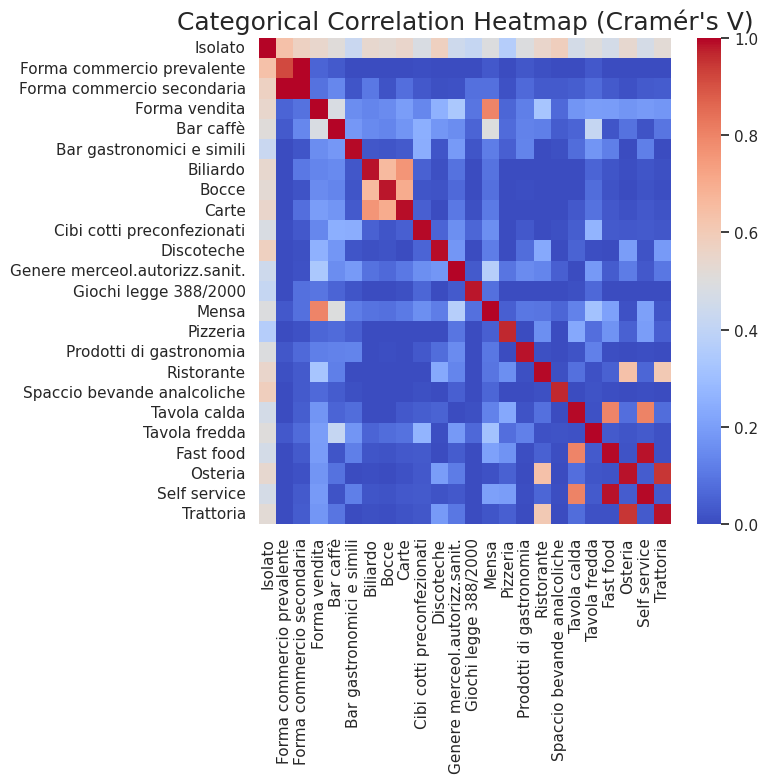

In [ ]:
df_afterCleaning = df.copy()

# Drop columns that contains almost unique values
df_afterCleaning = df_afterCleaning.drop(columns=["Insegna", "Tipo via", "Via", "Codice via", "Municipio", "Presso", "Civico", "Accesso"])
customHeatMap(df_afterCleaning)

In [ ]:
# Removing columns with high correlation
df_afterCleaning = df_afterCleaning.drop(columns=["Bar caffè", "Biliardo", "Bocce", "Fast food", "Osteria"])
df_afterCleaning = df_afterCleaning.drop(columns=["Forma commercio secondaria"])

Categorical columns used: ['Isolato', 'Forma commercio prevalente', 'Forma vendita', 'Bar gastronomici e simili', 'Carte', 'Cibi cotti preconfezionati', 'Discoteche', 'Genere merceol.autorizz.sanit.', 'Giochi legge 388/2000', 'Mensa', 'Pizzeria', 'Prodotti di gastronomia', 'Ristorante', 'Spaccio bevande analcoliche', 'Tavola calda', 'Tavola fredda', 'Self service', 'Trattoria']


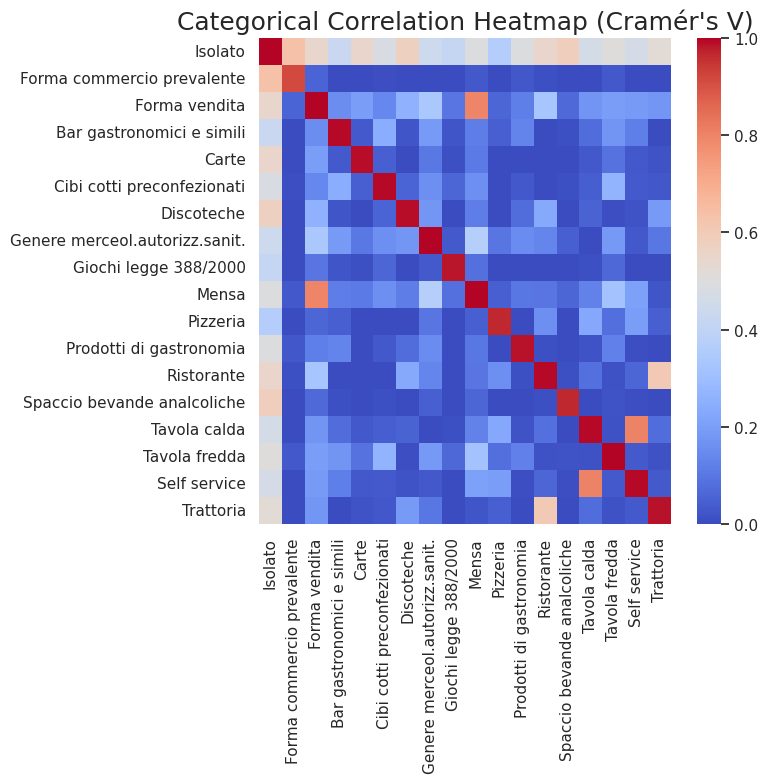

In [ ]:
customHeatMap(df_afterCleaning)

In [ ]:
KNN(df_afterCleaning, targetColumn = "Forma vendita", isClassification = True)
KNN(df_afterCleaning, targetColumn = "Superficie somministrazione", isClassification = False)

Rows with non-null target [Forma vendita]: 1635
Encoded feature space shape: (1635, 377)
Training KNN classifier...

Estimator performance for target 'Forma vendita':

Confusion matrix:
[[159   0   6  21]
 [  4   0   1   1]
 [ 25   0   3   6]
 [ 33   0   1  67]]

Classification report:
              precision    recall  f1-score   support

    al banco       0.72      0.85      0.78       186
   al tavolo       0.00      0.00      0.00         6
       misto       0.27      0.09      0.13        34
self service       0.71      0.66      0.68       101

    accuracy                           0.70       327
   macro avg       0.42      0.40      0.40       327
weighted avg       0.66      0.70      0.67       327

Rows with non-null target [Superficie somministrazione]: 1635
Encoded feature space shape: (1635, 381)
Training KNN regressor...
Cross-validated RMSE on train: 85.4653


## DA: cleaned data (without non valid rows)

Categorical columns used: ['Isolato', 'Forma commercio prevalente', 'Forma commercio secondaria', 'Forma vendita', 'Bar caffè', 'Bar gastronomici e simili', 'Biliardo', 'Bocce', 'Carte', 'Cibi cotti preconfezionati', 'Discoteche', 'Genere merceol.autorizz.sanit.', 'Giochi legge 388/2000', 'Mensa', 'Pizzeria', 'Prodotti di gastronomia', 'Ristorante', 'Spaccio bevande analcoliche', 'Tavola calda', 'Tavola fredda', 'Fast food', 'Osteria', 'Self service', 'Trattoria']


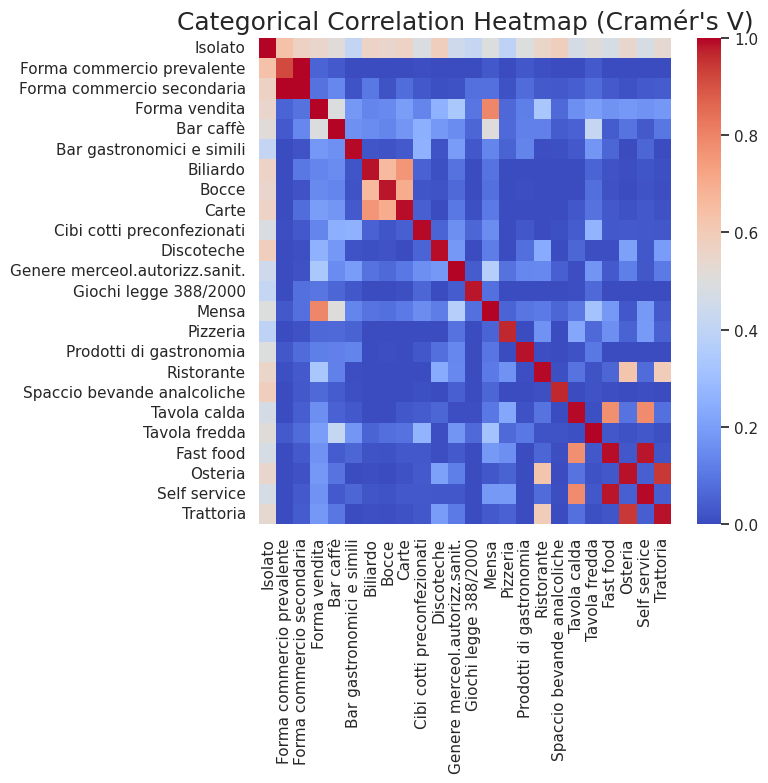

In [ ]:
validMask = df["IsAnomaly"] == False
df_afterCleaning_onlyValid = df[validMask]

# Drop columns that contains almost unique values
df_afterCleaning_onlyValid = df_afterCleaning_onlyValid.drop(columns=["Insegna", "Tipo via", "Via", "Codice via", "Municipio", "Presso", "Civico", "Accesso"])
customHeatMap(df_afterCleaning_onlyValid)

In [ ]:
# Removing columns with high correlation
df_afterCleaning_onlyValid = df_afterCleaning_onlyValid.drop(columns=["Bar caffè", "Biliardo", "Bocce", "Fast food", "Osteria"])
df_afterCleaning_onlyValid = df_afterCleaning_onlyValid.drop(columns=["Forma commercio secondaria"])

Categorical columns used: ['Isolato', 'Forma commercio prevalente', 'Forma vendita', 'Bar gastronomici e simili', 'Carte', 'Cibi cotti preconfezionati', 'Discoteche', 'Genere merceol.autorizz.sanit.', 'Giochi legge 388/2000', 'Mensa', 'Pizzeria', 'Prodotti di gastronomia', 'Ristorante', 'Spaccio bevande analcoliche', 'Tavola calda', 'Tavola fredda', 'Self service', 'Trattoria']


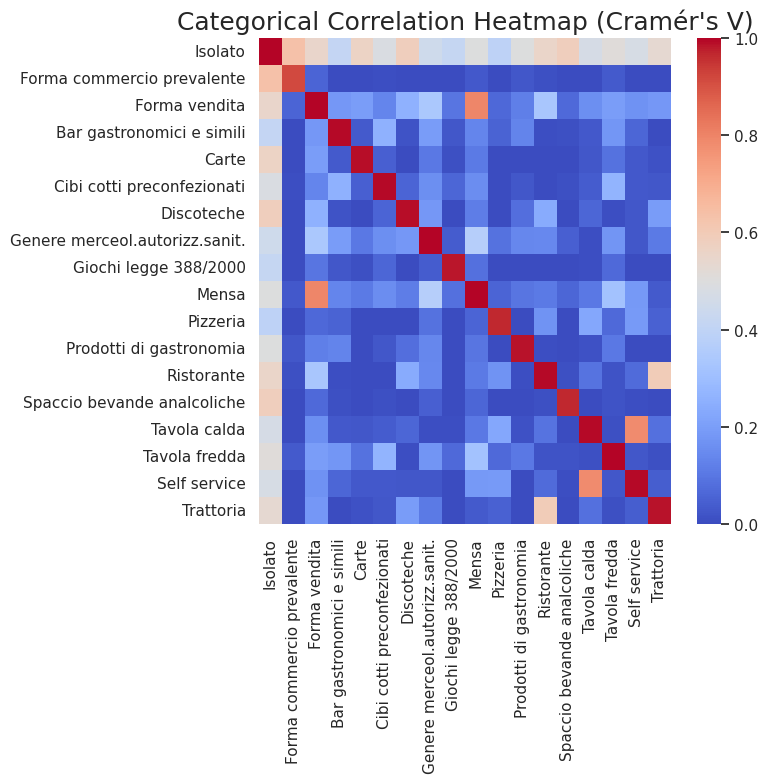

In [ ]:
customHeatMap(df_afterCleaning_onlyValid)

In [ ]:
KNN(df_afterCleaning_onlyValid, targetColumn = "Forma vendita", isClassification = True)
KNN(df_afterCleaning_onlyValid, targetColumn = "Superficie somministrazione", isClassification = False)

Rows with non-null target [Forma vendita]: 1616
Encoded feature space shape: (1616, 377)
Training KNN classifier...

Estimator performance for target 'Forma vendita':

Confusion matrix:
[[169   0   5  11]
 [  4   0   1   1]
 [ 24   0   4   6]
 [ 35   0   3  61]]

Classification report:
              precision    recall  f1-score   support

    al banco       0.73      0.91      0.81       185
   al tavolo       0.00      0.00      0.00         6
       misto       0.31      0.12      0.17        34
self service       0.77      0.62      0.69        99

    accuracy                           0.72       324
   macro avg       0.45      0.41      0.42       324
weighted avg       0.68      0.72      0.69       324

Rows with non-null target [Superficie somministrazione]: 1616
Encoded feature space shape: (1616, 381)
Training KNN regressor...
Cross-validated RMSE on train: 85.9390
